# Ноутбук 1. Математический и вычислительный инструментарий асимметричной криптографии

## Интенсивная актуализация предварительных знаний для магистерского курса

Этот ноутбук **не является вводным курсом элементарной теории чисел**. Предполагается, что студент уже изучал делимость, сравнения, НОД и алгоритм Евклида в бакалавриате, а также владеет базовыми методами математического доказательства. 

Здесь мы собираем именно тот математический и вычислительный инструментарий, который далее будет без повторного объяснения использоваться в RSA, Диффи—Хеллмане, Эль-Гамале, конечных полях и криптографии на эллиптических кривых.

К концу ноутбука должны быть доступны операции

$$
a^{-1}\pmod n,\qquad a^e\pmod n,\qquad \operatorname{CRT}(\ldots),
$$

а также проверенные реализации `gcd`, `extended_gcd`, `solve_linear_diophantine`, `mod_inverse`, `solve_linear`, `mod_pow`, `crt`, `garner_crt`.

Для ключевых результатов используем сквозную схему:

$$
\boxed{
\text{математический результат}
\to
\text{конструкция}
\to
\text{алгоритм}
\to
\text{корректность}
\to
\text{сложность}
\to
\text{криптографическое применение}.
}
$$

В вычислительных блоках отдельно различаем **доказательство корректности**, **тестирование реализации** и **эксперимент**: доказательство устанавливает свойство для всех допустимых входов; тесты помогают обнаруживать ошибки конкретного кода; эксперимент позволяет увидеть закономерность и сформулировать гипотезу. Даже большое число успешных тестов не заменяет доказательство корректности.


<div style="background-color: #111012; padding: 20px; border-radius: 10px; border-left: 4px solid #7653a6;">

### 🧩 Цель актуализации предварительных знаний

Собрать компактный арифметический инструментарий:

```text
crypto_math/
└── number_theory.py
    ├── divides()
    ├── gcd()
    ├── extended_gcd()
    ├── solve_linear_diophantine()
    ├── mod_inverse()
    ├── solve_linear()
    ├── mod_pow()
    ├── crt()
    └── garner_crt()
```

Для каждой основной операции нас интересуют:

- **контракт**: допустимые входы и математическое постусловие;
- **инвариант или конструктивная теорема**, обеспечивающие корректность;
- **стоимость вычисления**, измеряемая относительно размера входа;
- **проверка свойств** на случайных данных;
- место операции в последующих криптографических конструкциях.

</div>


### Терминологическое соглашение

Основной язык курса — русский. Для понятий, имеющих устойчивый русский академический эквивалент, используется русский термин. При **первом содержательном упоминании** рядом в скобках приводится распространённый английский термин — это облегчает поиск англоязычных учебников, статей, стандартов и документации.

Например:

- **сравнение по модулю** (*congruence modulo*);
- **наибольший общий делитель, НОД** (*greatest common divisor, GCD*);
- **расширенный алгоритм Евклида** (*extended Euclidean algorithm*);
- **обратный элемент по модулю** (*modular multiplicative inverse*);
- **быстрое модульное возведение в степень** (*fast modular exponentiation*);
- **китайская теорема об остатках, КТО** (*Chinese Remainder Theorem, CRT*);
- **инвариант цикла** (*loop invariant*);
- **битовая длина** (*bit length*);
- **сложность по битовым операциям** (*bit complexity*).

Имена функций Python (`gcd`, `extended_gcd`, `mod_inverse`, `mod_pow`, `crt`) не переводятся: это элементы программного интерфейса, а не терминология математического текста.


## 1.1. Криптографическая карта вычислений

В следующих разделах курса нам понадобятся:

- Диффи—Хеллман и Эль-Гамаль: $g^x\bmod p$;
- RSA: $m^e\bmod n$, обратимые элементы и реконструкция по КТО;
- конечные поля: деление как умножение на обратный элемент;
- криптография на эллиптических кривых: аналогичная идея быстрого умножения скаляра, но уже в группе точек.

Поэтому основной вопрос здесь не «что такое остаток?», а:

> какие арифметические операции должны быть математически корректны и вычислительно пригодны для чисел длиной 256–4096 бит?

Эта постановка требует различать числовую величину входа и **размер его представления**. Для целых чисел размер входа естественно измеряется битовой длиной.


## 1.2. Сравнения и арифметика классов вычетов — краткое повторение

Фиксируем обозначения, которые далее используются без пояснений.

### Определение 1.1. Делимость

Пусть $a,b\in\mathbb Z$. Говорят, что $a$ **делит** $b$ (пишут $a\mid b$), если существует $k\in\mathbb Z$ такое, что $b=ak$; иначе пишут $a\nmid b$. Число $a$ называется **делителем** (*divisor*) числа $b$, а $b$ — **кратным** (*multiple*) числа $a$.

Отметим крайний случай, важный для программного контракта: $0\mid b$ тогда и только тогда, когда $b=0$.

### Определение 1.2. Сравнение по модулю

Пусть $n\ge 2$ и $a,b\in\mathbb Z$. Числа $a$ и $b$ **сравнимы по модулю $n$** (*congruent modulo $n$*), если $n\mid(a-b)$:

$$
a\equiv b\pmod n.
\tag{1.1}
$$

Эквивалентно, существует $q\in\mathbb Z$ такое, что

$$
a=b+qn,
\tag{1.2}
$$

то есть $a$ и $b$ дают одинаковый остаток при делении на $n$. Сравнимость по модулю $n$ — отношение эквивалентности на $\mathbb Z$.

### Определение 1.3. Класс вычетов

**Классом вычетов числа $a$ по модулю $n$** (*residue class modulo $n$*) называется множество

$$
[a]_n=\{\,b\in\mathbb Z:\ b\equiv a\pmod n\,\}
\tag{1.3}
$$

$$
=a+n\mathbb Z=\{\,a+kn:\ k\in\mathbb Z\,\}.
\tag{1.4}
$$

Например, $[2]_5=\{\ldots,-8,-3,2,7,12,\ldots\}$, поэтому

$$
[2]_5=[7]_5=[-3]_5.
\tag{1.5}
$$

Вообще,

$$
[a]_n=[b]_n\iff a\equiv b\pmod n.
\tag{1.6}
$$

Множество классов вычетов обозначается

$$
\mathbb Z/n\mathbb Z
\tag{1.7}
$$

и состоит ровно из $n$ классов:

$$
\mathbb Z/n\mathbb Z=\{[0]_n,[1]_n,\ldots,[n-1]_n\}.
\tag{1.8}
$$

Число из $\{0,1,\ldots,n-1\}$, лежащее в классе, называется **наименьшим неотрицательным представителем** (*least nonnegative representative*); в Python при $n>0$ его даёт выражение `a % n`.

Полезно различать три уровня: целое число $a\in\mathbb Z$, класс $[a]_n\in\mathbb Z/n\mathbb Z$ и выбранный представитель класса (например, `a % n`). В коде эти уровни обычно отождествляют, в доказательствах — нет.

### Арифметика классов вычетов

Операции определяются через представителей:

$$
[a]_n+[b]_n=[a+b]_n,
\tag{1.9}
$$

$$
[a]_n[b]_n=[ab]_n.
\tag{1.10}
$$

Определение корректно (*well-defined*), то есть не зависит от выбора представителей: если $a\equiv a'$ и $b\equiv b'\pmod n$, то

$$
a+b\equiv a'+b'\pmod n,
\tag{1.11}
$$

$$
ab\equiv a'b'\pmod n.
\tag{1.12}
$$

Именно свойства (1.11)–(1.12) позволяют заменять большие целые их представителями по модулю $n$ **до** выполнения дальнейших сложений и умножений.


In [1]:
def divides(a: int, b: int) -> bool:
    """Контракт: возвращает True тогда и только тогда, когда a | b (Определение 1.1).

    Крайний случай: 0 | b  <=>  b == 0.
    """
    if a == 0:
        return b == 0
    return b % a == 0


assert divides(3, 12) and divides(-3, 12) and divides(3, -12)
assert not divides(5, 12)
assert divides(7, 0)                        # любое число делит 0
assert divides(0, 0) and not divides(0, 5)  # 0 делит только 0
# Связь с Определением 1.2: a ≡ b (mod n)  <=>  n | (a - b)
assert divides(12, 17 - 5)


### Пример 1.1. Редукция во время вычисления

Чтобы вычислить

$$
123456789^{10^6}\pmod{1009},
$$

не нужно строить само число $123456789^{10^6}$: в нём около 8 миллионов десятичных цифр. Благодаря совместимости сравнения с умножением, формула (1.12), редукцию можно выполнять после **каждого** умножения, и все промежуточные значения остаются меньше $1009$. Сначала можно заменить и само основание его представителем: $123456789\equiv 594\pmod{1009}$. Итог: $123456789^{10^6}\equiv 628\pmod{1009}$.

Эта идея — фундамент всех дальнейших вычислений: в §1.6 она вместе с двоичной записью показателя даст быстрое модульное возведение в степень.

</div>

<div style="background-color: #282e29; padding: 20px; border-radius: 10px; border-left: 4px solid #3a8f5c;">

### Пример 1.2. Как получить целое число ровно из 512 бит

Для криптографических экспериментов важно контролировать не только верхнюю границу числа, но и его **битовую длину**.

Для положительного целого $n$ битовая длина равна

$$
\ell(n)=\lfloor\log_2 n\rfloor+1.
$$

Эквивалентно,

$$
2^{\ell(n)-1}\le n<2^{\ell(n)}.
$$

В Python значение $\ell(n)$ возвращает метод `n.bit_length()`.

Для генерации случайных значений используем модуль `secrets`:

```python
import secrets

n = secrets.randbits(512)

# Гарантируем, что число действительно 512-битное:
n |= (1 << 511)

print(n.bit_length())
```

Последняя строка гарантированно выведет

```text
512
```

Одного вызова `secrets.randbits(512)` недостаточно: он возвращает случайное целое в диапазоне

$$
0\le n<2^{512},
$$

поэтому старшие биты случайно могут оказаться нулевыми.

Операция

```python
n |= (1 << 511)
```

устанавливает старший бит в `1`, поэтому

$$
2^{511}\le n<2^{512}.
$$

#### Размер входа и сложность

В криптографии сложность алгоритма оценивают относительно **размера представления входа**, а не только относительно числовой величины входного числа. Обозначим через $L=\ell(n)$ битовую длину числа $n$ (см. формулу выше). Тогда $2^{L-1}\le n<2^L$, то есть $n$ имеет порядок $2^L$. Поэтому алгоритм, выполняющий $O(n)$ шагов, требует порядка

$$
O(2^L)
$$

шагов относительно битовой длины входа.

В этом ноутбуке будем различать два уровня оценки:

- **арифметическая сложность** — число делений, умножений или других операций над целыми числами;
- **сложность по битовым операциям** — учитывает, что одна операция над длинными числами сама имеет ненулевую стоимость.

Например, если $M(L)$ обозначает стоимость умножения двух $L$-битных чисел, то фраза «$O(L)$ умножений» ещё не означает $O(L)$ битовых операций.

На этом этапе нам достаточно уметь чётко различать эти два уровня. Более точные оценки появятся там, где они влияют на выбор криптографических параметров.

</div>


<div style="background-color: #100f0c; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Практика. Не вычисляйте больше, чем нужно

1. Предскажите, совпадут ли два результата ниже.
2. Сгенерируйте несколько пар **ровно 512-битных** целых `a, b`, используя приём из примера 1.2, и проверьте предсказание.
3. Объясните совпадение через формулы (1.11)–(1.12), а не через особенности Python.
4. Сформулируйте, почему ранняя редукция критична при вычислении больших степеней.

</div>

In [3]:
import secrets

def random_exact_bits(bits: int) -> int:
    """Возвращает положительное целое ровно заданной битовой длины."""
    if bits < 1:
        raise ValueError("bits должно быть положительным")

    n = secrets.randbits(bits)
    n |= 1 << (bits - 1)
    return n


# Пример: две случайные величины ровно по 512 бит.
a = random_exact_bits(512)
b = random_exact_bits(512)

assert a.bit_length() == 512
assert b.bit_length() == 512

print("a.bit_length() =", a.bit_length())
print("b.bit_length() =", b.bit_length())

# Выберите модуль n > 0 и сравните:
# ((a % n) * (b % n)) % n
# (a * b) % n

# Выполните задания здесь
# 1. Предсказание.
# Сравниваем
#   early  = ((a % n) * (b % n)) % n
#   direct = (a * b) % n
# Они совпадут при любом n > 0.
# Это не особенность Python, а формулы (1.11) и (1.12):
# сравнение по модулю сохраняется и при сложении, и при умножении.
print("Предсказание: остаток произведения и произведение остатков совпадут.")

# 2. Проверка на нескольких парах ровно по 512 бит.
# Модуль 1009 взят из примера 1.1. Годится любой n > 0.
modulus = 1009
for trial in range(1, 6):
    a = random_exact_bits(512)
    b = random_exact_bits(512)
    # Приём из примера 1.2: старший бит уже выставлен внутри random_exact_bits,
    # поэтому длина ровно 512, а не «не больше 512».
    assert a.bit_length() == 512
    assert b.bit_length() == 512

    # a % n — представитель класса [a]_n, значит a ≡ (a % n) (mod n).
    a_mod = a % modulus
    b_mod = b % modulus

    early = (a_mod * b_mod) % modulus
    direct = (a * b) % modulus

    # Та же проверка для суммы: это формула (1.11).
    early_sum = (a_mod + b_mod) % modulus
    direct_sum = (a + b) % modulus

    print(
        f"пара {trial}: произведение совпало = {early == direct}, "
        f"сумма совпала = {early_sum == direct_sum}"
    )
    print(
        f"         биты a*b = {(a * b).bit_length()}, "
        f"биты (a%n)*(b%n) = {(a_mod * b_mod).bit_length()}"
    )
    assert early == direct
    assert early_sum == direct_sum

print("На пяти парах предсказание подтвердилось.")

# 3. Откуда берётся совпадение, формулы (1.11)–(1.12).
# По определению остатка a = q*n + (a % n), поэтому
#     a ≡ (a % n) (mod n),    b ≡ (b % n) (mod n).
# Формула (1.12): если a ≡ a' и b ≡ b' (mod n), то ab ≡ a'b' (mod n).
# Берём a' = a % n и b' = b % n:
#     a*b ≡ (a % n)*(b % n) (mod n),
# значит остатки равны:
#     (a * b) % n == ((a % n) * (b % n)) % n.
# Формула (1.11) — то же правило для суммы:
#     (a + b) % n == ((a % n) + (b % n)) % n.
# Поэтому большое целое можно заменить остатком ещё до сложения и умножения.

# 4. Почему ранняя редукция критична для больших степеней.
# a^k — это много умножений подряд. Без остатка после каждого шага
# число цифр растёт вместе со степенью.
# В примере 1.1 у 123456789^(10**6) около 8 миллионов десятичных цифр,
# такое число нельзя строить целиком.
# Формула (1.12) разрешает после каждого умножения заменить произведение
# остатком по модулю n. Промежуточные значения остаются меньше n,
# а класс результата не меняется.
print(
    "Без редукции a*b занимает",
    (a * b).bit_length(),
    "бит. Остатки по модулю",
    modulus,
    "меньше",
    modulus,
    ", их произведение занимает",
    (a_mod * b_mod).bit_length(),
    "бит.",
)


a.bit_length() = 512
b.bit_length() = 512
Предсказание: остаток произведения и произведение остатков совпадут.
пара 1: произведение совпало = True, сумма совпала = True
         биты a*b = 1023, биты (a%n)*(b%n) = 16
пара 2: произведение совпало = True, сумма совпала = True
         биты a*b = 1024, биты (a%n)*(b%n) = 17
пара 3: произведение совпало = True, сумма совпала = True
         биты a*b = 1024, биты (a%n)*(b%n) = 18
пара 4: произведение совпало = True, сумма совпала = True
         биты a*b = 1024, биты (a%n)*(b%n) = 17
пара 5: произведение совпало = True, сумма совпала = True
         биты a*b = 1023, биты (a%n)*(b%n) = 17
На пяти парах предсказание подтвердилось.
Без редукции a*b занимает 1023 бит. Остатки по модулю 1009 меньше 1009 , их произведение занимает 17 бит.


### Определение 1.4. Полная система вычетов

Набор из $n$ целых чисел $r_0,r_1,\ldots,r_{n-1}$ называется **полной системой вычетов по модулю $n$** (*complete residue system modulo $n$*), если каждое целое число сравнимо по модулю $n$ ровно с одним из этих чисел.

Эквивалентно, классы $[r_0]_n,\ldots,[r_{n-1}]_n$ попарно различны и исчерпывают $\mathbb Z/n\mathbb Z$.

Стандартный пример — $0,1,\ldots,n-1$, но представители могут быть любыми, в том числе отрицательными.

<div style="background-color: #141719; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.1. Полная система вычетов

Образуют ли числа
$$-16,\ 17,\ -6,\ 27,\ -20,\ 13,\ -2,\ 23$$
полную систему вычетов по модулю $8$?

Проверьте ответ вручную, приведя числа к наименьшим неотрицательным представителям, а затем программно с помощью `%`.

</div>

In [3]:
# Задание 1.1. Полная система вычетов по модулю 8.
#
# Определение 1.4: набор из n целых — полная система вычетов по модулю n,
# если каждое целое число сравнимо по модулю n ровно с одним элементом набора.
# Эквивалентная проверка: наименьшие неотрицательные остатки этих чисел
# попарно различны и вместе дают ровно множество {0, 1, ..., n - 1}.

MODULUS = 8
candidates = [-16, 17, -6, 27, -20, 13, -2, 23]

# Сначала остатки считаем вручную. Ищем r такое, что
#     a = q * 8 + r  и  0 <= r < 8.
# Именно это r в Python даёт выражение a % 8 (при положительном модуле).
#
# -16 = (-2) * 8 + 0
#  17 =   2  * 8 + 1
#  -6 = (-1) * 8 + 2
#  27 =   3  * 8 + 3
# -20 = (-3) * 8 + 4    потому что -3 * 8 = -24, а -24 + 4 = -20
#  13 =   1  * 8 + 5
#  -2 = (-1) * 8 + 6    потому что -1 * 8 = -8, а -8 + 6 = -2
#  23 =   2  * 8 + 7
manual_residues = {
    -16: 0,
    17: 1,
    -6: 2,
    27: 3,
    -20: 4,
    13: 5,
    -2: 6,
    23: 7,
}

# Программная проверка тем же правилом: оператор % приводит число
# к наименьшему неотрицательному представителю класса.
residues = [number % MODULUS for number in candidates]

print("число -> остаток по модулю 8")
for number, residue in zip(candidates, residues):
    print(f"{number:4d} -> {residue}")
    # Ручной остаток и результат % должны совпасть.
    assert residue == manual_residues[number]

# Набор из 8 чисел является полной системой вычетов по модулю 8
# тогда и только тогда, когда остатки — это 0, 1, ..., 7 без повторов.
assert len(residues) == MODULUS
assert sorted(residues) == list(range(MODULUS))

print("Да: эти числа образуют полную систему вычетов по модулю 8.")


число -> остаток по модулю 8
 -16 -> 0
  17 -> 1
  -6 -> 2
  27 -> 3
 -20 -> 4
  13 -> 5
  -2 -> 6
  23 -> 7
Да: эти числа образуют полную систему вычетов по модулю 8.


## 1.3. НОД и алгоритм Евклида — повторение через инвариант

### Определение 1.5. Наибольший общий делитель

Пусть $a,b\in\mathbb Z$, причём $a$ и $b$ не равны нулю одновременно. **Наибольшим общим делителем** (*greatest common divisor, GCD*) чисел $a,b$ называется положительное целое число $d=\gcd(a,b)$, такое что
$$d\mid a,\qquad d\mid b,$$
и любой общий делитель $c$ чисел $a,b$ делит $d$:
$$c\mid a,\ c\mid b\Longrightarrow c\mid d.$$

Используем соглашения $\gcd(a,b)\ge0$ и $\gcd(a,0)=|a|$.

### Определение 1.6. Взаимно простые числа

Числа $a,b$ называются **взаимно простыми** (*coprime, relatively prime*), если
$$\gcd(a,b)=1.$$

Ключевой инвариант алгоритма Евклида:
$$\gcd(a,b)=\gcd(b,a\bmod b),\qquad b\ne0. \tag{1.13}$$

```python
def gcd(a: int, b: int) -> int:
    if a == 0 and b == 0:
        raise ValueError("gcd(0, 0) is undefined by the course convention")
    a, b = abs(a), abs(b)
    while b != 0:
        a, b = b, a % b
    return a
```

### Паспорт алгоритма `gcd`

**Контракт.** Вход: $a,b\in\mathbb Z$, не равные нулю одновременно. Выход: положительное число $d$, для которого

$$
d=\gcd(a,b).
$$

**Корректность.** На каждом шаге сохраняется НОД пары благодаря (1.13). Когда второй компонент становится равным нулю, первый компонент равен НОД исходной пары.

**Стоимость.** Число итераций алгоритма Евклида растёт как $O(\log\min(|a|,|b|))$ в арифметической модели. Ниже теорема Ламе даст строгую оценку и покажет, почему соседние числа Фибоначчи реализуют худший случай. Для криптографических входов важно, что логарифмический рост относительно числовой величины означает линейный рост по порядку битовой длины.

**Проверка реализации.** Для независимой перекрёстной проверки используйте `math.gcd` на допустимых входах.

In [7]:
def gcd(a: int, b: int) -> int:
    if a == 0 and b == 0:
        raise ValueError("gcd(0, 0) is undefined by the course convention")

    a, b = abs(a), abs(b)
    while b:
        a, b = b, a % b
    return a

assert gcd(252, 105) == 21
assert gcd(-30, 42) == 6

try:
    gcd(0, 0)
except ValueError:
    pass
else:
    raise AssertionError("gcd(0, 0) must be rejected by the course convention")


<div style="background-color: #323028; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Исследование 1.1. Алгоритм Евклида: инвариант и масштаб

1. Докажите (1.13) через множества общих делителей.
2. Укажите строку программы, реализующую переход (1.13).
3. Модифицируйте `gcd`, чтобы функция возвращала также количество итераций. Назовите её `gcd_with_iterations`. Проверка:
   ```python
   d, n = gcd_with_iterations(1312331323, 58123123)
   print(f"d={d}, количество итераций={n}")
   ```
   Ожидаемый результат: `d=1, количество итераций=21`. Объясните, что считается одной итерацией.
4. Для битовых длин $32,64,128,256,512,1024$ сгенерируйте несколько случайных пар и сравните среднее число итераций.
5. Сопоставьте наблюдаемое число шагов с битовой длиной входа. Почему рост не похож на полный перебор до $\min(|a|,|b|)$?
6. Дополнительно исследуйте пары соседних чисел Фибоначчи $(F_{k+1},F_k)$. Для нескольких $k$ измерьте число итераций, сравните его с $k-1$ и сформулируйте гипотезу о худшем случае. В следующем блоке эта гипотеза будет превращена в строгую теорему.

**Что является доказательством, а что экспериментом?** Пункт 1 доказывает корректность одного шага алгоритма для всех допустимых входов. Пункты 4–6 дают экспериментальные данные о числе шагов и позволяют сформулировать гипотезу, но сами по себе не доказывают ни асимптотическую оценку, ни утверждение о худшем случае.

</div>


In [5]:
# Выполните задания здесь:

import math


def gcd_with_iterations(a: int, b: int) -> tuple[int, int]:
    """НОД и число итераций алгоритма Евклида.

    Контракт тот же, что у gcd: gcd(0, 0) запрещён, результат неотрицательный.
    Второе число — сколько раз выполнилось тело цикла.
    """
    if a == 0 and b == 0:
        raise ValueError("gcd(0, 0) is undefined by the course convention")

    a, b = abs(a), abs(b)
    iterations = 0
    while b:
        # Пункт 2. Эта строка и есть переход (1.13):
        #     gcd(a, b) = gcd(b, a % b),  b != 0.
        # Одна итерация — одно такое деление с остатком.
        # Шаг, на котором остаток стал нулём, тоже считается:
        # цикл делает замену и только потом видит b == 0.
        a, b = b, a % b
        iterations += 1
    return a, iterations


# Пункт 1. Доказательство (1.13) через множества общих делителей.
# Пусть b != 0 и r = a % b. Тогда a = q*b + r для некоторого целого q.
#
# Если d делит a и b, то d делит q*b, значит d делит a - q*b, то есть d делит r.
# Обратно: если d делит b и r, то d делит q*b + r, то есть d делит a.
# Поэтому множества общих делителей пар (a, b) и (b, r) совпадают.
# Их наибольшие положительные элементы тоже совпадают:
#     gcd(a, b) = gcd(b, a % b).
# Это доказательство одного шага для всех допустимых входов, не эксперимент.
# Полный текст того же рассуждения есть в следующей ячейке ноутбука.


# Пункт 3. Контрольная пара из условия.
d, n = gcd_with_iterations(1312331323, 58123123)
print(f"d={d}, количество итераций={n}")
assert d == 1
assert n == 21
assert d == math.gcd(1312331323, 58123123)


# Пункт 4. Среднее число итераций на случайных парах заданной битовой длины.
# random_exact_bits определена выше: она даёт число ровно из L бит.
bit_lengths = (32, 64, 128, 256, 512, 1024)
samples_per_length = 20

print("L, бит | среднее число итераций | полный перебор до min(|a|,|b|) имел бы шагов порядка")
averages = {}
for length in bit_lengths:
    total = 0
    for _ in range(samples_per_length):
        left = random_exact_bits(length)
        right = random_exact_bits(length)
        divisor, iterations = gcd_with_iterations(left, right)
        assert divisor == math.gcd(left, right)
        total += iterations
    average = total / samples_per_length
    averages[length] = average
    # min(|a|, |b|) имеет величину около 2^(L-1): столько проверок сделал бы перебор делителей.
    print(f"{length:6d} | {average:24.1f} | 2^{length - 1}")


# Пункт 5. Что видно по таблице.
# При удвоении L среднее число итераций тоже растёт примерно вдвое:
# от десятков шагов на 32 битах до нескольких сотен на 1024.
# Перебор делителей до min(|a|, |b|) при том же удвоении L умножает работу
# не на 2, а на 2^L: это экспонента по битовой длине.
# Евклид на каждом шаге заменяет пару остатком, который строго меньше
# предыдущего числа, поэтому шагов примерно столько, сколько бит во входе,
# а не столько, сколько само число.
ratio = averages[1024] / averages[32]
print(
    f"От 32 до 1024 бит длина выросла в {1024 / 32:.0f} раз, "
    f"среднее число шагов Евклида — в {ratio:.1f} раз."
)
print("Полный перебор на тех же длинах вырос бы в 2^992 раз.")


def fibonacci(k: int) -> int:
    """Число Фибоначчи с нумерацией теоремы Ламе: F_1 = F_2 = 1."""
    if k < 1:
        raise ValueError("k должно быть положительным")
    previous, current = 1, 1
    for _ in range(2, k):
        previous, current = current, previous + current
    return current


# Пункт 6. Соседние числа Фибоначчи (F_{k+1}, F_k).
# Гипотеза, которую проверяем, а не теорема: на такой паре алгоритм делает
# ровно k - 1 делений. Это больше, чем среднее на случайной паре
# той же битовой длины, поэтому соседние числа Фибоначчи похожи
# на худший случай по числу шагов.
print("k | итераций | k-1 | совпало | битовая длина F_k")
for k in (10, 20, 40, 80, 160):
    divisor, iterations = gcd_with_iterations(fibonacci(k + 1), fibonacci(k))
    print(
        f"{k:3d} | {iterations:9d} | {k - 1:3d} | {iterations == k - 1!s:7} | {fibonacci(k).bit_length()}"
    )
    assert divisor == 1
    assert iterations == k - 1

print(
    "Гипотеза: худший случай — соседние числа Фибоначчи, "
    "и на паре (F_{k+1}, F_k) шагов ровно k-1."
)
print(
    "Пункты 4–6 это измеряют и подсказывают гипотезу. "
    "Они не доказывают ни оценку для всех входов, ни то, что хуже этих пар не бывает."
)


d=1, количество итераций=21
L, бит | среднее число итераций | полный перебор до min(|a|,|b|) имел бы шагов порядка
    32 |                     19.6 | 2^31
    64 |                     36.5 | 2^63
   128 |                     73.7 | 2^127
   256 |                    151.1 | 2^255
   512 |                    299.6 | 2^511
  1024 |                    601.7 | 2^1023
От 32 до 1024 бит длина выросла в 32 раз, среднее число шагов Евклида — в 30.6 раз.
Полный перебор на тех же длинах вырос бы в 2^992 раз.
k | итераций | k-1 | совпало | битовая длина F_k
 10 |         9 |   9 | True    | 6
 20 |        19 |  19 | True    | 13
 40 |        39 |  39 | True    | 27
 80 |        79 |  79 | True    | 55
160 |       159 | 159 | True    | 110
Гипотеза: худший случай — соседние числа Фибоначчи, и на паре (F_{k+1}, F_k) шагов ровно k-1.
Пункты 4–6 это измеряют и подсказывают гипотезу. Они не доказывают ни оценку для всех входов, ни то, что хуже этих пар не бывает.


In [6]:
# Решение
def gcd(a: int, b: int) -> int:
    if a == 0 and b == 0:
        raise ValueError("gcd(0, 0) is undefined by the course convention")

    a, b = abs(a), abs(b)
    k = 0
    while b:
        a, b = b, a % b
        k += 1
    print(f'число итераций = {k}')
    return a
    
# Пример: две случайные величины ровно по 512 бит.
L = 100
a = random_exact_bits(L)
b = random_exact_bits(L)
print(f'gcd({a},{b}) = {gcd(a,b)}')
def fib(n):
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a
k = 2048
a = fib(k+1)
b = fib(k)
bit_b = b.bit_length()
print(f'НОД = {gcd(a,b)}, 1+1.44*L={1+1.44*bit_b}')

число итераций = 65
gcd(1220777627914484822946742030349,835892538826524830815935746988) = 1
число итераций = 2047
НОД = 1, 1+1.44*L=2047.24


<div style="background-color: #1c201d; padding: 20px; border-radius: 10px; border-left: 4px solid #3a8f5c;">

### Решение пункта 1

Докажем формулу (1.13):
$$
\gcd(a,b)=\gcd(b,a\bmod b),\qquad b\ne0,
$$

через множества общих делителей.

Обозначим

$$
r=a\bmod b.
$$

По определению остатка существуют целые $q,r$ такие, что

$$
a=qb+r.
$$

Покажем, что множества общих делителей пар $(a,b)$ и $(b,r)$ совпадают.

Пусть $d$ — общий делитель чисел $a$ и $b$. Тогда

$$
d\mid a,\qquad d\mid b.
$$

Так как

$$
r=a-qb,
$$

то $d$ делит и $a$, и $qb$, а значит, делит их разность:

$$
d\mid(a-qb).
$$

Следовательно,

$$
d\mid r.
$$

Значит, любой общий делитель $a$ и $b$ является также общим делителем $b$ и $r$.

Теперь докажем обратное включение. Пусть $d$ — общий делитель $b$ и $r$:

$$
d\mid b,\qquad d\mid r.
$$

Из равенства

$$
a=qb+r
$$

следует, что $d\mid qb$ и $d\mid r$, поэтому

$$
d\mid(qb+r),
$$

то есть

$$
d\mid a.
$$

Следовательно, любой общий делитель $b$ и $r$ является также общим делителем $a$ и $b$.

Итак,

$$
\{d\in\mathbb Z:\ d\mid a,\ d\mid b\}
= \{d\in\mathbb Z:\ d\mid b,\ d\mid r\}.
$$

Множества общих делителей совпадают, поэтому совпадают и их наибольшие положительные элементы:

$$
\gcd(a,b)=\gcd(b,r).
$$

Поскольку $r=a\bmod b$, получаем

$$
\boxed{\gcd(a,b)=\gcd(b,a\bmod b)}.
$$

Таким образом, формула (1.13) доказана.

</div>

<div style="border-top: 1px solid #999; border-bottom: 1px solid #999; padding: 12px 4px; margin: 18px 0;">

<strong>Теорема 1.1. Теорема Ламе и худший случай алгоритма Евклида</strong>

Пусть $a>b\ge1$, и алгоритм Евклида выполняет $t$ делений с остатком до получения нулевого остатка. Пусть числа Фибоначчи заданы условиями

$$
F_1=F_2=1,
\qquad
F_{n+1}=F_n+F_{n-1}.
$$

Тогда

$$
b\ge F_{t+1},
\qquad
a\ge F_{t+2}.
$$

Следовательно, если

$$
\varphi=\frac{1+\sqrt5}{2},
$$

то

$$
t\le 1+\log_{\varphi} b.
$$

Если $L=\lfloor\log_2 b\rfloor+1$ — битовая длина меньшего аргумента, то

$$
t<1+\frac{L}{\log_2\varphi}<1+1.441L.
$$

Оценка точна по порядку и по числу шагов на соответствующих порогах: для каждой пары соседних чисел Фибоначчи $(F_{k+1},F_k)$ алгоритм Евклида выполняет ровно $k-1$ делений. Иными словами, минимальные положительные входы, требующие заданного числа делений, задаются соседними числами Фибоначчи.

</div>

**Доказательство.**

Обозначим последовательные остатки алгоритма Евклида через

$$
r_0=a,
\qquad
r_1=b,
\qquad
r_0>r_1>\cdots>r_t>0,
\qquad
r_{t+1}=0.
$$

Каждое деление имеет вид

$$
r_{i-1}=q_i r_i+r_{i+1},
\qquad q_i\ge1.
$$

Нам нужно связать число делений $t$ с тем, насколько велики должны быть исходные числа. Удобно идти **с конца алгоритма к началу**.

Последний ненулевой остаток — положительное целое число, поэтому

$$
r_t\ge1=F_2.
$$

В последнем делении

$$
r_{t-1}=q_t r_t,
$$

причём $r_{t-1}>r_t>0$, поэтому $q_t\ge2$. Следовательно,

$$
r_{t-1}\ge2r_t\ge2=F_3.
$$

Для всех предыдущих шагов достаточно использовать $q_i\ge1$:

$$
r_{i-1}=q_i r_i+r_{i+1}\ge r_i+r_{i+1}.
$$

Теперь применим обратную индукцию. Мы уже установили

$$
r_t\ge F_2,
\qquad
r_{t-1}\ge F_3.
$$

Если для двух соседних остатков выполнено

$$
r_i\ge F_m,
\qquad
r_{i+1}\ge F_{m-1},
$$

то

$$
r_{i-1}\ge r_i+r_{i+1}
\ge F_m+F_{m-1}
=F_{m+1}.
$$

Поднимаясь таким образом к началу алгоритма, получаем

$$
r_1=b\ge F_{t+1},
\qquad
r_0=a\ge F_{t+2}.
$$

Это и есть основная оценка Ламе.

Остаётся связать числа Фибоначчи с обычным логарифмом. Для

$$
\varphi=\frac{1+\sqrt5}{2}
$$

выполнено

$$
\varphi^2=\varphi+1.
$$

Покажем индукцией, что для $n\ge2$

$$
F_n\ge\varphi^{n-2}.
$$

Для $n=2$ имеем $F_2=1=\varphi^0$, а для $n=3$ имеем $F_3=2>\varphi$. Если оценка верна для $n$ и $n-1$, то

$$
F_{n+1}=F_n+F_{n-1}
\ge\varphi^{n-2}+\varphi^{n-3}
=\varphi^{n-3}(\varphi+1)
=\varphi^{n-1}.
$$

Следовательно,

$$
b\ge F_{t+1}\ge\varphi^{t-1},
$$

откуда

$$
t\le1+\log_{\varphi}b.
$$

Если $L=\lfloor\log_2 b\rfloor+1$, то $b<2^L$, поэтому

$$
t<1+\log_{\varphi}(2^L)
=1+\frac{L}{\log_2\varphi}
<1+1.441L.
$$

Наконец, покажем достижимость оценки. Для соседних чисел Фибоначчи рекуррентное соотношение даёт

$$
F_{j+1}=F_j+F_{j-1},
$$

поэтому при $j>2$

$$
F_{j+1}\bmod F_j=F_{j-1}.
$$

Алгоритм последовательно проходит пары

$$
(F_{k+1},F_k)
\to(F_k,F_{k-1})
\to\cdots
\to(F_3,F_2)
\to(F_2,0).
$$

До нулевого остатка выполняется ровно $k-1$ делений. Значит, нижние границы $a\ge F_{t+2}$ и $b\ge F_{t+1}$ достигаются, а соседние числа Фибоначчи действительно являются точными свидетелями худшего случая по числу шагов. $\square$

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Связь с экспериментом</strong>

В Исследовании 1.1 мы сначала наблюдали необычно длинные цепочки для соседних чисел Фибоначчи. Теперь экспериментальная закономерность получила строгое объяснение:

$$
(F_{k+1},F_k)
\quad\Longrightarrow\quad
k-1\ \text{итераций}.
$$

Теорема также объясняет ранее заявленную стоимость `gcd`: число итераций линейно по порядку битовой длины меньшего аргумента. При этом оценка $1+1.441L$ относится к **числу евклидовых делений**; итоговая битовая сложность дополнительно учитывает стоимость операций над длинными целыми.

</div>

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">


</div>

<div style="background-color: #fff8e1; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Практика. Перебор против алгоритма Евклида

Функция `gcd_bruteforce` вычисляет НОД прямо по определению 1.5: перебирает все $d$ от $1$ до $\min(|a|,|b|)$ и запоминает наибольший общий делитель. Она верна, но делает $\min(a,b)\approx 2^{L-1}$ проверок, где $L$ — битовая длина входа: это экспонента по $L$ (см. «Размер входа и сложность» в примере 1.2). Алгоритм Евклида по теореме 1.1 делает не больше $1+1.441L$ делений. Эксперимент показывает, как эта разница выглядит в цифрах.

```python
def gcd_bruteforce(a: int, b: int) -> int:
    """
    Наивное вычисление НОД перебором.

    Используется только для малых чисел и для проверки других реализаций.
    """
    if a == 0 and b == 0:
        raise ValueError("gcd(0, 0) is undefined by the course convention")

    a, b = abs(a), abs(b)

    if a == 0:
        return b

    if b == 0:
        return a

    best = 1
    for d in range(1, min(a, b) + 1):
        if a % d == 0 and b % d == 0:
            best = d

    return best
```

**Как снять время.** Используйте `time.perf_counter()` — часы высокого разрешения для измерения интервалов:

```python
import time

a, b = random_exact_bits(L), random_exact_bits(L)
t0 = time.perf_counter()
g = gcd_bruteforce(a, b)
elapsed = time.perf_counter() - t0      # секунды
```

Для каждого $L$ возьмите 3–5 случайных пар и запишите медиану. Число проверок перебора равно $\min(a,b)$. Число делений Евклида считает ваша функция `gcd_with_iterations` из Исследования 1.1 (п. 3); его усредните по 1000 пар — Евклид работает мгновенно.

**Гипотеза.** До запуска предскажите: во сколько раз вырастет число проверок перебора и на сколько — число делений Евклида, если битовую длину $L$ увеличить на 4?

**Часть A. Замеры на вашем ПК.** Заполните таблицу. При $L\ge 28$ перебор уже заметно долгий — не запускайте его.

| $L$, бит | проверок перебора $\min(a,b)$ | время перебора, с | делений Евклида (среднее) |
|---:|---:|---:|---:|
| 8 | | | |
| 12 | | | |
| 16 | | | |
| 20 | | | |
| 24 | | | |

**Часть B. Что будет на криптографических длинах.** При $L\ge 32$ перебор запускать бессмысленно, поэтому его время не измеряют, а оценивают по замеру из части A:

1. Найдите время одной проверки: время перебора при $L=24$ разделите на число проверок при $L=24$. Обычно получается около $5\cdot10^{-8}$ с.
2. Умножьте время одной проверки на число проверок $2^{L-1}$ — это и есть оценка времени перебора для длины $L$.

Таблица посчитана для $5\cdot10^{-8}$ с на одну проверку. На вашем ПК числа в колонке «время перебора» будут немного другими, но порядок тот же: минуты для 32 бит и тысячи лет уже для 64.

| $L$, бит | проверок перебора $\approx 2^{L-1}$ | время перебора | делений Евклида, не больше $1+1.441L$ |
|---:|---:|---:|---:|
| 32 | $\approx 2{,}1\cdot10^{9}$ | $\approx 2$ мин | 47 |
| 64 | $\approx 9{,}2\cdot10^{18}$ | $\approx 1{,}5\cdot10^{4}$ лет | 93 |
| 128 | $\approx 1{,}7\cdot10^{38}$ | $\approx 10^{23}$ лет | 185 |
| 2048 | $\approx 1{,}6\cdot10^{616}$ | $\approx 10^{601}$ лет | 2952 |

**Вопросы**

1. Как меняется число проверок перебора при переходе $L\to L+4$? А число делений Евклида? Совпало ли с гипотезой?
2. Цикл в `gcd_bruteforce` «линейный» по $\min(a,b)$. Почему алгоритм всё же экспоненциальный? Ответьте через $L$.
3. Почему среднее число делений в вашей таблице заметно меньше оценки $1+1.441L$? На каких входах оценка достигается?

</div>


In [10]:
# Выполните задания здесь:

import math
import time
from statistics import median


def gcd_bruteforce(a: int, b: int) -> int:
    """НОД перебором всех кандидатов от 1 до min(|a|, |b|).

    Верно по определению 1.5, но годится только для малых чисел:
    число проверок равно min(|a|, |b|).
    """
    if a == 0 and b == 0:
        raise ValueError("gcd(0, 0) is undefined by the course convention")

    a, b = abs(a), abs(b)
    if a == 0:
        return b
    if b == 0:
        return a

    best = 1
    for divisor in range(1, min(a, b) + 1):
        if a % divisor == 0 and b % divisor == 0:
            best = divisor
    return best


# Гипотеза до замеров.
# Число проверок перебора — это min(|a|, |b|). У числа ровно из L бит
# величина порядка 2^(L-1). При переходе L -> L+4 это число умножается на 2^4 = 16.
# Число делений Евклида так не растёт. Оценка Ламе 1 + 1.441*L при +4 битах
# увеличивается всего на 1.441 * 4 ≈ 5.8 шага. На случайных парах прибавка
# ещё скромнее: несколько делений, а не множитель 16.
print("Гипотеза: проверки перебора ×16, деления Евклида плюс несколько шагов, не ×16.")


def median_bruteforce(length: int, repeats: int = 5) -> tuple[float, float]:
    """Медиана числа проверок и медиана времени перебора на repeats парах."""
    check_counts = []
    elapsed_times = []
    for _ in range(repeats):
        left = random_exact_bits(length)
        right = random_exact_bits(length)
        started = time.perf_counter()
        divisor = gcd_bruteforce(left, right)
        elapsed_times.append(time.perf_counter() - started)
        # Перекрёстная проверка: перебор обязан совпасть с math.gcd.
        assert divisor == math.gcd(left, right)
        check_counts.append(min(left, right))
    return median(check_counts), median(elapsed_times)


def mean_euclid_steps(length: int, repeats: int = 1000) -> float:
    """Среднее число делений Евклида. Перебор здесь не запускается."""
    total = 0
    for _ in range(repeats):
        _divisor, iterations = gcd_with_iterations(
            random_exact_bits(length),
            random_exact_bits(length),
        )
        total += iterations
    return total / repeats


# Часть A. Перебор только до 24 бит: при L >= 28 он уже слишком долгий.
part_a_lengths = (8, 12, 16, 20, 24)
checks_by_length = {}
time_by_length = {}
euclid_by_length = {}

print("L | проверок, медиана | время перебора, с | делений Евклида, среднее | оценка Ламе")
for length in part_a_lengths:
    checks, elapsed = median_bruteforce(length)
    euclid_steps = mean_euclid_steps(length)
    checks_by_length[length] = checks
    time_by_length[length] = elapsed
    euclid_by_length[length] = euclid_steps
    lame_bound = 1 + 1.441 * length
    print(
        f"{length:2d} | {checks:18.0f} | {elapsed:18.6f} | {euclid_steps:25.2f} | {lame_bound:12.1f}"
    )


# Вопрос 1. Сравниваем соседние строки таблицы: длина каждый раз +4.
print("Переход L -> L+4: во сколько раз выросли проверки и на сколько делений Евклида")
for previous, current in zip(part_a_lengths, part_a_lengths[1:]):
    check_ratio = checks_by_length[current] / checks_by_length[previous]
    step_delta = euclid_by_length[current] - euclid_by_length[previous]
    print(f"{previous:2d} -> {current:2d}: проверки ×{check_ratio:.2f}, деления Евклида {step_delta:+.2f}")
print("С гипотезой совпадает: проверки около ×16, деления Евклида — прибавка на единицы, не ×16.")


# Вопрос 2. Цикл перебора линейный по min(a, b), но min(a, b) ≈ 2^(L-1).
# Размер входа — это L, число бит, а не само значение числа.
# Линейная зависимость от 2^(L-1) является экспонентой по L.
print(
    "Перебор делает Θ(min(|a|, |b|)) = Θ(2^(L-1)) проверок. "
    "По битовой длине L это экспонента, хотя по величине числа цикл линейный."
)


# Вопрос 3. 1 + 1.441*L — потолок худшего случая, теорема Ламе.
# Он достигается на соседних числах Фибоначчи, не на случайной паре.
# Поэтому среднее в таблице заметно ниже этой оценки.
print(
    "Среднее меньше 1+1.441*L, потому что оценка — худший случай. "
    "Она достигается на парах соседних чисел Фибоначчи (F_{k+1}, F_k)."
)


# Часть B. Время одной проверки снимаем с замера L = 24
# и переносим на криптографические длины. Сам перебор там не запускаем.
seconds_per_check = time_by_length[24] / checks_by_length[24]
print(f"Время одной проверки по замеру L=24: {seconds_per_check:.3e} с")

def format_bruteforce_estimate(seconds_per_check: float, bit_length: int) -> tuple[str, str]:
    """Оценка  seconds_per_check * 2^(L-1)  без сборки самого числа 2^(L-1).

    Для L = 2048 это 2^2047 проверок: такое целое не помещается в float.
    Считаем десятичный логарифм и по нему печатаем порядок времени.
    """
    log10_checks = (bit_length - 1) * math.log10(2)
    log10_seconds = math.log10(seconds_per_check) + log10_checks

    def sci(log10_value: float) -> str:
        power = math.floor(log10_value)
        mantissa = 10 ** (log10_value - power)
        return f"{mantissa:.3g}·10^{power}"

    log10_minute = math.log10(60)
    log10_hour = math.log10(3600)
    log10_year = math.log10(365.25 * 24 * 3600)
    if log10_seconds < log10_minute:
        duration = f"{10 ** log10_seconds:.3g} с"
    elif log10_seconds < log10_hour:
        duration = f"{10 ** (log10_seconds - log10_minute):.3g} мин"
    elif log10_seconds < log10_year:
        duration = f"{10 ** (log10_seconds - log10_hour):.3g} ч"
    else:
        duration = f"{sci(log10_seconds - log10_year)} лет"
    return sci(log10_checks), duration


print("L | проверок 2^(L-1) | оценка времени перебора | делений Евклида, не больше 1+1.441*L")
for length in (32, 64, 128, 2048):
    checks_text, duration_text = format_bruteforce_estimate(seconds_per_check, length)
    print(
        f"{length:4d} | {checks_text:>12} | {duration_text:>24} | {1 + 1.441 * length:.0f}"
    )



Гипотеза: проверки перебора ×16, деления Евклида плюс несколько шагов, не ×16.
L | проверок, медиана | время перебора, с | делений Евклида, среднее | оценка Ламе
 8 |                159 |           0.000003 |                      5.30 |         12.5
12 |               3151 |           0.000054 |                      7.57 |         18.3
16 |              41893 |           0.000679 |                     10.18 |         24.1
20 |             777193 |           0.013643 |                     12.50 |         29.8
24 |           10772760 |           0.184512 |                     14.60 |         35.6
Переход L -> L+4: во сколько раз выросли проверки и на сколько делений Евклида
 8 -> 12: проверки ×19.82, деления Евклида +2.27
12 -> 16: проверки ×13.30, деления Евклида +2.61
16 -> 20: проверки ×18.55, деления Евклида +2.31
20 -> 24: проверки ×13.86, деления Евклида +2.11
С гипотезой совпадает: проверки около ×16, деления Евклида — прибавка на единицы, не ×16.
Перебор делает Θ(min(|a|, |b|)) =

<div style="border-top: 1px solid #999; border-bottom: 1px solid #999; padding: 12px 4px; margin: 18px 0;">

<strong>Лемма 1.1. НОД нескольких целых чисел</strong>

Если $a_1,a_2,\ldots,a_n$ — целые числа, не все равные нулю, то

$$
\gcd(a_1,a_2,\ldots,a_{n-1},a_n)
= \gcd\!\left(a_1,a_2,\ldots,\gcd(a_{n-1},a_n)\right).
$$

Поэтому НОД конечного набора можно вычислять последовательным применением двухаргументного алгоритма Евклида.

</div>

<div style="background-color: #283037; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.2. НОД нескольких чисел

**Часть A. Доказательство Леммы 1.1 индукцией.**

Для $k\ge 2$ определим последовательную свёртку

$$
g_2=\gcd(a_1,a_2),
\qquad
g_k=\gcd(g_{k-1},a_k)\quad (k\ge 3).
$$

Докажите по индукции по $k$, что

$$
g_k=\gcd(a_1,\ldots,a_k).
$$

1. **База $k=2$.** Объясните, почему утверждение непосредственно следует из определения $g_2$.
2. **Индукционный переход.** Предположите, что $g_k=\gcd(a_1,\ldots,a_k)$. Покажите, что общие делители чисел $g_k$ и $a_{k+1}$ — в точности общие делители чисел $a_1,\ldots,a_k,a_{k+1}$. Отсюда выведите
   $$
   g_{k+1}=\gcd(g_k,a_{k+1})=\gcd(a_1,\ldots,a_k,a_{k+1}).
   $$
3. Объясните, почему из доказанного утверждения следует формула Леммы 1.1: обе её части являются НОД одного и того же конечного набора чисел, только с разной расстановкой скобок.
4. Укажите, какая операция будущей функции `gcd_n` будет непосредственно реализовывать индукционный переход.

**Часть B. Реализация.**

Напишите функцию `gcd_n`, вычисляющую НОД двух и более целых чисел последовательным применением двухаргументной функции `gcd`. Найдите

$$
\gcd(280,330,405,490).
$$

```python
import math
ns = 280, 330, 405, 490
print(f"math.gcd={math.gcd(*ns)}")
print(f"gcd_n={gcd_n(*ns)}")
```

Ожидается:
```text
math.gcd=5
gcd_n=5
```

В коротком комментарии сопоставьте доказательство и программу: что играет роль $g_k$ и какая строка реализует переход $g_k\mapsto g_{k+1}$?

</div>

In [12]:
# Ваше решение:

# Часть A. Лемма 1.1 индукцией по длине набора.
#
# Для k >= 2 свёртка определена так:
#     g_2 = gcd(a_1, a_2),
#     g_k = gcd(g_{k-1}, a_k) при k >= 3.
# Доказываем: g_k = gcd(a_1, ..., a_k).
#
# 1. База k = 2.
# g_2 по определению равен gcd(a_1, a_2).
# Это и есть НОД первых двух чисел, так что утверждение для k = 2 верно сразу.
#
# 2. Индукционный переход.
# Предположение: g_k = gcd(a_1, ..., a_k).
# Нужно показать, что общие делители пары (g_k, a_{k+1}) —
# те же, что общие делители всего набора a_1, ..., a_k, a_{k+1}.
#
# Пусть d делит каждое из a_1, ..., a_k и ещё a_{k+1}.
# Тогда d — общий делитель a_1, ..., a_k, поэтому d делит их НОД,
# то есть d делит g_k. Вместе с d | a_{k+1} получаем, что d делит оба
# числа пары (g_k, a_{k+1}).
#
# Наоборот, пусть d делит g_k и a_{k+1}.
# g_k = gcd(a_1, ..., a_k) само делит каждое a_1, ..., a_k,
# значит d тоже делит каждое из них. И d делит a_{k+1}.
# Значит d — общий делитель всего набора a_1, ..., a_{k+1}.
#
# Множества общих делителей совпали, поэтому совпали и их
# наибольшие положительные элементы:
#     g_{k+1} = gcd(g_k, a_{k+1}) = gcd(a_1, ..., a_k, a_{k+1}).
#
# 3. Почему отсюда следует Лемма 1.1.
# Левая часть леммы — это gcd(a_1, ..., a_n). По доказанному она равна g_n:
# скобки расставлены слева направо.
# Правая часть — gcd(a_1, ..., a_{n-2}, gcd(a_{n-1}, a_n)).
# Внутренний gcd(a_{n-1}, a_n) заменяет два последних числа их НОД,
# а по тому же утверждению свёртка любого конечного набора равна НОД
# этого набора. Общие делители не меняются от того, считать ли
# последними два числа по отдельности или сразу их НОД.
# Поэтому обе части равны НОД одного и того же набора.
# Разница только в скобках: слева направо или сначала последняя пара.
#
# 4. В функции gcd_n индукционный переход — это вызов двухаргументного gcd
# внутри цикла: новая свёртка = gcd(старая свёртка, следующий элемент).
# Переменная g хранит текущее g_k.


def gcd_n(*numbers: int) -> int:
    """НОД двух и более целых чисел свёрткой двухаргументного gcd.

    Не все аргументы могут быть нулями: иначе НОД по соглашению курса
    не определён. Нужно хотя бы два числа.
    """
    if len(numbers) < 2:
        raise ValueError("gcd_n expects at least two integers")
    if all(number == 0 for number in numbers):
        raise ValueError("gcd of an all-zero tuple is undefined by the course convention")

    # g_2 = gcd(a_1, a_2). Переменная g дальше хранит g_k.
    g = gcd(numbers[0], numbers[1])
    for number in numbers[2:]:
        # Переход g_k -> g_{k+1}: g_{k+1} = gcd(g_k, a_{k+1}).
        g = gcd(g, number)
    return g


import math

ns = 280, 330, 405, 490
print(f"math.gcd={math.gcd(*ns)}")
print(f"gcd_n={gcd_n(*ns)}")
assert math.gcd(*ns) == 5
assert gcd_n(*ns) == 5

# Та же свёртка по шагам, чтобы было видно роль g_k.
# g_2 = gcd(280, 330), затем g_3 = gcd(g_2, 405), затем g_4 = gcd(g_3, 490).
g = gcd(280, 330)
print(f"g_2 = gcd(280, 330) = {g}")
g = gcd(g, 405)
print(f"g_3 = gcd(g_2, 405) = {g}")
g = gcd(g, 490)
print(f"g_4 = gcd(g_3, 490) = {g}")



math.gcd=5
gcd_n=5
g_2 = gcd(280, 330) = 10
g_3 = gcd(g_2, 405) = 5
g_4 = gcd(g_3, 490) = 5


<div style="background-color: #0a090c; padding: 20px; border-radius: 10px; border-left: 4px solid #7653a6;">

### 🧩 Взгляд вперёд: алгоритм Евклида хранит цепную дробь

В алгоритме Евклида важны не только остатки, но и частные $q_1,q_2,\ldots,q_s$. Если

$$
a=q_1b+r_2,
$$

а затем деления продолжаются для пары $(b,r_2)$, то последовательная подстановка выражений для остатков приводит к конечной цепной дроби

$$
\frac{a}{b}
= q_1+\cfrac{1}{q_2+\cfrac{1}{\ddots+\cfrac{1}{q_s}}}.
$$

Таким образом, один запуск алгоритма Евклида одновременно вычисляет $\gcd(a,b)$ и кодирует рациональное число $a/b$ последовательностью частных. Позже мы вернёмся к этой связи при изучении **подходящих дробей** (*convergents*) и атаки Винера на RSA: там частные алгоритма Евклида превратятся из промежуточных вычислений в инструмент криптоанализа.

</div>

<div style="background-color: #fff8e1; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Исследование 1.2. Частные Евклида как данные

1. Для пар $(125,92)$, $(105,38)$ и для нескольких соседних чисел Фибоначчи сохраните не только остатки, но и частные $q_i$ алгоритма Евклида.
2. Напишите функцию `euclid_quotients(a, b)`, возвращающую список этих частных.
3. Напишите обратную функцию `from_continued_fraction(qs)`, которая по списку $[q_1,\ldots,q_s]$ вычисляет значение цепной дроби и возвращает его как пару целых чисел $(p,q)$ — числитель и знаменатель, так что $p/q$ равно цепной дроби $q_1+\cfrac{1}{q_2+\cfrac{1}{\ddots+\cfrac{1}{q_s}}}$ из «Взгляда вперёд».
4. Проверьте экспериментально свойство
   $$
   \texttt{from\_continued\_fraction(euclid\_quotients(a,b))}
   = (a/g,\ b/g),
   \qquad g=\gcd(a,b),
   $$
   на случайных положительных $a>b$. Оба числа $a/g$ и $b/g$ целые, так как $g$ делит $a$ и $b$.
5. Объясните, почему у восстановленной пары $(p,q)$ всегда $\gcd(p,q)=1$, то есть дробь $p/q$ несократима, и какую уже доказанную теорему об алгоритме Евклида вы используете в этом объяснении.

Здесь не требуется развивать полную теорию цепных дробей. Цель — обнаружить дополнительную структуру в уже знакомом алгоритме и сохранить её для будущего RSA-блока.

</div>

In [13]:
# Выполните исследование здесь:

import secrets


def euclid_quotients(a: int, b: int) -> list[int]:
    """Частные q_i алгоритма Евклида для пары (a, b), b != 0.

    На шаге a = q*b + r в список попадает q = a // b.
    Последнее деление, которое даёт нулевой остаток, тоже записывается.
    """
    if b == 0:
        raise ValueError("continued fraction a/b needs b != 0")

    a, b = abs(a), abs(b)
    quotients = []
    while b:
        quotients.append(a // b)
        a, b = b, a % b
    return quotients


def from_continued_fraction(qs: list[int]) -> tuple[int, int]:
    """Значение цепной дроби q1 + 1/(q2 + ... + 1/qs) как несократимая пара (p, q).

    Считаем с конца точными целыми, без дробей float.
    Хвост qs[-1] — это дробь qs[-1] / 1.
    Шаг наружу: q + 1/(numer/denom) = (q*numer + denom) / numer.
    """
    if not qs:
        raise ValueError("continued fraction needs at least one quotient")

    numer, denom = qs[-1], 1
    for quotient in reversed(qs[:-1]):
        numer, denom = quotient * numer + denom, numer
    return numer, denom


def show_divisions(a: int, b: int) -> None:
    """Печатает и остатки, и частные одного запуска алгоритма Евклида."""
    print(f"пара ({a}, {b})")
    left, right = a, b
    while right:
        quotient, remainder = divmod(left, right)
        print(f"  {left} = {quotient} * {right} + {remainder}")
        left, right = right, remainder
    quotients = euclid_quotients(a, b)
    restored = from_continued_fraction(quotients)
    print(f"  частные {quotients}")
    print(f"  цепная дробь даёт {restored}")


# Пункт 1. Две заданные пары: в каждой строке видно и частное, и остаток.
show_divisions(125, 92)
show_divisions(105, 38)


def fibonacci(k: int) -> int:
    """F_1 = F_2 = 1, как в теореме Ламе."""
    previous, current = 1, 1
    for _ in range(2, k):
        previous, current = current, previous + current
    return current


# Соседние числа Фибоначчи. Почти все частные равны 1:
# F_{k+1} = 1*F_k + F_{k-1}. Последнее частное равно 2,
# потому что последний шаг — это 2 = 2*1 + 0.
print("соседние числа Фибоначчи")
for k in (6, 8, 10):
    show_divisions(fibonacci(k + 1), fibonacci(k))


# Пункт 4. Случайные положительные a > b.
# Восстановленная пара должна быть (a/g, b/g), g = gcd(a, b).
print("случайные пары")
for _ in range(10):
    smaller = secrets.randbelow(100_000) + 1
    larger = smaller + secrets.randbelow(100_000) + 1
    quotients = euclid_quotients(larger, smaller)
    restored = from_continued_fraction(quotients)
    g = gcd(larger, smaller)
    expected = (larger // g, smaller // g)
    print(f"  ({larger}, {smaller}), g={g}, частные={quotients}, восстановлено={restored}")
    assert restored == expected
    assert gcd(*restored) == 1

# Та же проверка, когда g > 1: частные такие же, как у сокращённой пары.
assert euclid_quotients(250, 184) == euclid_quotients(125, 92)
assert from_continued_fraction(euclid_quotients(250, 184)) == (125, 92)

# Пункт 5. Почему у пары (p, q) всегда gcd(p, q) = 1.
# Проверенное свойство говорит: (p, q) = (a/g, b/g), где g = gcd(a, b).
# Пусть d делит и a/g, и b/g. Тогда d*g делит и a, и b.
# Но g — наибольший положительный общий делитель (определение 1.5),
# поэтому d*g не больше g, значит d = 1.
# То, что алгоритм Евклида вообще возвращает этот g, а не другое число,
# даёт уже доказанный инвариант (1.13): gcd(a, b) = gcd(b, a % b).
# НОД пары не меняется на каждом делении, и в конце остаётся сам g.
# Теорема Ламе здесь не нужна: она про число шагов, а не про несократимость.
print("У восстановленной пары gcd равен 1, потому что это (a/g, b/g).")



пара (125, 92)
  125 = 1 * 92 + 33
  92 = 2 * 33 + 26
  33 = 1 * 26 + 7
  26 = 3 * 7 + 5
  7 = 1 * 5 + 2
  5 = 2 * 2 + 1
  2 = 2 * 1 + 0
  частные [1, 2, 1, 3, 1, 2, 2]
  цепная дробь даёт (125, 92)
пара (105, 38)
  105 = 2 * 38 + 29
  38 = 1 * 29 + 9
  29 = 3 * 9 + 2
  9 = 4 * 2 + 1
  2 = 2 * 1 + 0
  частные [2, 1, 3, 4, 2]
  цепная дробь даёт (105, 38)
соседние числа Фибоначчи
пара (13, 8)
  13 = 1 * 8 + 5
  8 = 1 * 5 + 3
  5 = 1 * 3 + 2
  3 = 1 * 2 + 1
  2 = 2 * 1 + 0
  частные [1, 1, 1, 1, 2]
  цепная дробь даёт (13, 8)
пара (34, 21)
  34 = 1 * 21 + 13
  21 = 1 * 13 + 8
  13 = 1 * 8 + 5
  8 = 1 * 5 + 3
  5 = 1 * 3 + 2
  3 = 1 * 2 + 1
  2 = 2 * 1 + 0
  частные [1, 1, 1, 1, 1, 1, 2]
  цепная дробь даёт (34, 21)
пара (89, 55)
  89 = 1 * 55 + 34
  55 = 1 * 34 + 21
  34 = 1 * 21 + 13
  21 = 1 * 13 + 8
  13 = 1 * 8 + 5
  8 = 1 * 5 + 3
  5 = 1 * 3 + 2
  3 = 1 * 2 + 1
  2 = 2 * 1 + 0
  частные [1, 1, 1, 1, 1, 1, 1, 1, 2]
  цепная дробь даёт (89, 55)
случайные пары
  (19530, 1475), g=5, час

### Определение 1.7. Взаимная простота нескольких чисел

Целые $a_1,\ldots,a_n$ называются **взаимно простыми в совокупности** (*coprime as a set*), если
$$\gcd(a_1,\ldots,a_n)=1.$$

Они называются **попарно взаимно простыми** (*pairwise coprime*), если
$$\gcd(a_i,a_j)=1\quad\text{для всех }i\ne j.$$

Попарная взаимная простота влечёт взаимную простоту в совокупности; обратное утверждение неверно.

<div style="background-color: #e8f4fd; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.3. Взаимная и попарная взаимная простота

1. Программно проверьте, являются ли $15,21,35$ взаимно простыми в совокупности и попарно взаимно простыми.
2. Найдите три взаимно простых в совокупности числа среди $66,105,42,70,165$.
3. Исследуйте утверждение: если $k$ — целое, то $6k-1,6k+1,6k+2,6k+3,6k+5$ попарно взаимно просты. Сначала проведите эксперимент, затем либо докажите утверждение для всех целых $k$, либо предъявите контрпример.

</div>

In [14]:
# Ваше решение:

from itertools import combinations


def pairwise_coprime(numbers: tuple[int, ...]) -> bool:
    """True, если gcd каждой пары равен 1."""
    return all(gcd(left, right) == 1 for left, right in combinations(numbers, 2))


# Пункт 1. 15, 21, 35.
# В совокупности: gcd всех трёх равен 1.
# Попарно: нет, у каждой пары свой простой делитель.
first = (15, 21, 35)
print(f"gcd(15, 21, 35) = {gcd_n(*first)}")
print(f"попарно взаимно просты: {pairwise_coprime(first)}")
for left, right in combinations(first, 2):
    print(f"  gcd({left}, {right}) = {gcd(left, right)}")
assert gcd_n(*first) == 1
assert not pairwise_coprime(first)


# Пункт 2. Ищем тройки с НОД 1 среди пяти чисел.
# Разложения:
#   66 = 2·3·11,  105 = 3·5·7,  42 = 2·3·7,  70 = 2·5·7,  165 = 3·5·11.
# Общий делитель всех пяти сразу не находится, но у многих троек он есть.
candidates = (66, 105, 42, 70, 165)
print("тройки с НОД 1:")
found = []
for triple in combinations(candidates, 3):
    common = gcd_n(*triple)
    if common == 1:
        found.append(triple)
        print(f"  {triple}, попарно: {pairwise_coprime(triple)}")
    else:
        print(f"  {triple} отпадает, gcd = {common}")
assert found == [(66, 105, 70), (66, 70, 165), (42, 70, 165)]
# Одна такая тройка, как просит задание: 66, 105, 70.
# Ни одна подходящая тройка не попарно взаимно проста.


# Пункт 3. Сначала эксперимент.
# Набор: 6k-1, 6k+1, 6k+2, 6k+3, 6k+5.
# Для целых k от -30 до 30 включительно все пары взаимно просты.
failures = []
for k in range(-30, 31):
    values = (6 * k - 1, 6 * k + 1, 6 * k + 2, 6 * k + 3, 6 * k + 5)
    if not pairwise_coprime(values):
        failures.append((k, values))
print(f"контрпримеров на k от -30 до 30: {len(failures)}")
assert failures == []
print("пример k = 1:", (5, 7, 8, 9, 11), "попарно:", pairwise_coprime((5, 7, 8, 9, 11)))


# Затем доказательство для всякого целого k, а не только для проверенного диапазона.
# Ни одно из пяти чисел не обращается в нуль при целом k:
# 6k-1, 6k+1, 6k+2, 6k+3, 6k+5 = 0 дали бы нецелый k.
# НОД двух чисел делит их разность. Знак не важен: курс берёт модули.
# Все десять пар и чем ограничен их НОД:
#   (6k+1, 6k+2) и (6k+2, 6k+3) отличаются на 1, НОД равен 1.
#   (6k-1, 6k+1), (6k+1, 6k+3), (6k+3, 6k+5) отличаются на 2.
#   Оба числа нечётные: 6k чётно, слагаемые -1, +1, +3, +5 нечётные.
#   НОД делит 2 и не делится на 2, значит НОД равен 1.
#   (6k-1, 6k+3) и (6k+1, 6k+5) отличаются на 4.
#   Снова оба нечётные, НОД делит 4, но не делится на 2, значит НОД равен 1.
#   (6k-1, 6k+2) и (6k+2, 6k+5) отличаются на 3, НОД делит 3.
#   По модулю 3 имеем 6k ≡ 0, поэтому
#   6k-1 ≡ 2, 6k+2 ≡ 2, 6k+5 ≡ 2. Ни одно из них не делится на 3.
#   НОД делит 3 и сам на 3 не делится, значит НОД равен 1.
#   (6k-1, 6k+5) отличаются на 6, НОД делит 6.
#   6k-1 нечётно, поэтому 2 не входит в НОД.
#   6k-1 ≡ 2 (mod 3), поэтому 3 тоже не входит. НОД равен 1.
# Других пар нет. Утверждение верно для всех целых k, контрпримера нет.
print("Утверждение верно для всех целых k: все десять пар взаимно просты.")



gcd(15, 21, 35) = 1
попарно взаимно просты: False
  gcd(15, 21) = 3
  gcd(15, 35) = 5
  gcd(21, 35) = 7
тройки с НОД 1:
  (66, 105, 42) отпадает, gcd = 3
  (66, 105, 70), попарно: False
  (66, 105, 165) отпадает, gcd = 3
  (66, 42, 70) отпадает, gcd = 2
  (66, 42, 165) отпадает, gcd = 3
  (66, 70, 165), попарно: False
  (105, 42, 70) отпадает, gcd = 7
  (105, 42, 165) отпадает, gcd = 3
  (105, 70, 165) отпадает, gcd = 5
  (42, 70, 165), попарно: False
контрпримеров на k от -30 до 30: 0
пример k = 1: (5, 7, 8, 9, 11) попарно: True
Утверждение верно для всех целых k: все десять пар взаимно просты.


<div style="background-color: #2b3339; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.4. Доля взаимно простых пар

Оцените долю взаимно простых пар натуральных чисел $(a,b)$ при $a,b\le N$ для
$$N=10^3,\ 10^4,\ 10^5,\ 10^6.$$

Для больших $N$ используйте случайную выборку, а не полный перебор $N^2$ пар. Сравните оценку с
$$
\frac{6}{\pi^2}\approx0.607927.
$$

Теоретически при $N\to\infty$
$$
P(\gcd(a,b)=1)
= \prod_{p\text{ — простое}}\left(1-\frac1{p^2}\right)
= \frac1{\zeta(2)}
= \frac6{\pi^2},
$$
где **дзета-функция Римана** (*Riemann zeta function*) при $s>1$ задаётся рядом
$$
\zeta(s)=\sum_{n=1}^{\infty}\frac1{n^s}.
$$

Укажите размер выборки и обсудите статистический разброс результатов.

</div>

In [15]:
# Ваше решение:

# Заготовка: функция оценки уже дана — проведите эксперимент и проанализируйте разброс.

import math
import secrets

def estimate_coprime_probability(N: int, samples: int = 20_000) -> float:
    coprime = 0
    for _ in range(samples):
        a = secrets.randbelow(N) + 1
        b = secrets.randbelow(N) + 1
        coprime += (math.gcd(a, b) == 1)
    return coprime / samples

# Выполните эксперимент для N = 10**3, 10**4, 10**5, 10**6.
# Сравните результаты с 6 / math.pi**2.
# Теоретический предел при N -> бесконечности: 1/zeta(2) = 6/pi**2.
target = 6 / math.pi ** 2
print(f"6/pi^2 = {target:.6f}")

# Размер одной выборки — это samples в заготовке, по умолчанию 20_000.
# Полный перебор для N = 10**6 был бы из 10**12 пар, поэтому для всех четырёх N
# вероятность оценивается случайными парами. Повторы при том же N нужны,
# чтобы увидеть разброс оценки, а не другую вероятность.
repeats = 10
sample_size = 20_000

# Каждая пара — испытание с двумя исходами: взаимно просты или нет.
# Если истинная доля равна p, стандартная ошибка одной оценки из n пар равна
# sqrt(p*(1-p)/n). При p = 6/pi**2 и n = 20_000 это около трёх тысячных.
standard_error = math.sqrt(target * (1 - target) / sample_size)
print(
    f"выборка n = {sample_size}, повторов = {repeats}, "
    f"стандартная ошибка одной оценки ≈ {standard_error:.4f}"
)

for N in (10**3, 10**4, 10**5, 10**6):
    estimates = [
        estimate_coprime_probability(N, sample_size)
        for _ in range(repeats)
    ]
    average = sum(estimates) / repeats
    spread = max(estimates) - min(estimates)
    print(
        f"N = {N:<8}  среднее = {average:.4f}  "
        f"мин = {min(estimates):.4f}  макс = {max(estimates):.4f}  "
        f"размах = {spread:.4f}  среднее - 6/pi^2 = {average - target:+.4f}"
    )

# Для N = 10**3 пар всего 10**6, полный перебор ещё реален.
# Он отделяет погрешность выборки от того, что N ещё конечно.
exact_coprime = 0
for a in range(1, 10**3 + 1):
    for b in range(1, 10**3 + 1):
        exact_coprime += math.gcd(a, b) == 1
exact_probability = exact_coprime / 10**6
print(
    f"точный перебор N = 1000: {exact_probability:.6f}, "
    f"отличие от 6/pi^2 = {exact_probability - target:+.6f}"
)

# Что видно по числам.
# Размах десяти оценок — несколько тысячных, как и стандартная ошибка.
# Сдвиг среднего относительно 6/pi^2 того же порядка.
# Поэтому N = 10**3 и N = 10**6 этой выборкой не различаются:
# предел уже достигнут с точностью до шума в третьем знаке после запятой.
# Точный ответ при N = 1000 отличается от 6/pi^2 лишь в четвёртом знаке,
# то есть конечность N здесь меньше, чем шум выборки из 20_000 пар.
print(
    "Разброс оценок — это шум выборки размера 20_000, "
    "а не зависимость вероятности от N."
)


6/pi^2 = 0.607927
выборка n = 20000, повторов = 10, стандартная ошибка одной оценки ≈ 0.0035
N = 1000      среднее = 0.6068  мин = 0.6010  макс = 0.6104  размах = 0.0094  среднее - 6/pi^2 = -0.0011
N = 10000     среднее = 0.6094  мин = 0.6065  макс = 0.6149  размах = 0.0084  среднее - 6/pi^2 = +0.0014
N = 100000    среднее = 0.6087  мин = 0.6050  макс = 0.6160  размах = 0.0110  среднее - 6/pi^2 = +0.0008
N = 1000000   среднее = 0.6093  мин = 0.6025  макс = 0.6170  размах = 0.0145  среднее - 6/pi^2 = +0.0014
точный перебор N = 1000: 0.608383, отличие от 6/pi^2 = +0.000456
Разброс оценок — это шум выборки размера 20_000, а не зависимость вероятности от N.


## 1.4. Соотношение Безу и расширенный алгоритм Евклида

<div style="border-top: 1px solid #999; border-bottom: 1px solid #999; padding: 12px 4px; margin: 18px 0;">

<strong>Теорема 1.2. Соотношение Безу</strong>

Пусть $a,b\in\mathbb Z$ и $a,b$ не равны нулю одновременно. Тогда существуют целые числа $x,y\in\mathbb Z$ такие, что

$$
ax+by=\gcd(a,b).
\tag{1.14}
$$

Числа $x$ и $y$ называются **коэффициентами Безу** (*Bézout coefficients*). Они, вообще говоря, не единственны.

</div>

**Доказательство.**

Положим

$$
A=|a|,\qquad B=|b|.
$$

Переход к абсолютным величинам позволяет в основной части доказательства работать с неотрицательными числами. При этом НОД не меняется:

$$
\gcd(a,b)=\gcd(A,B).
$$

После того как мы найдём представление НОД в виде целочисленной линейной комбинации $A$ и $B$, знаки исходных $a$ и $b$ можно будет включить в коэффициенты этой комбинации.

Рассмотрим множество всех **положительных целочисленных линейных комбинаций** $A$ и $B$:

$$
S=\{\,Am+Bn:\ m,n\in\mathbb Z,\ Am+Bn>0\,\}.
$$

Сначала убедимся, что множество $S$ непусто. Это необходимо, поскольку далее мы хотим выбрать его наименьший элемент.

Так как $a$ и $b$ не равны нулю одновременно, числа $A=|a|$ и $B=|b|$ также не могут одновременно равняться нулю.

Если $A>0$, выберем

$$
m=1,\qquad n=0.
$$

Тогда

$$
Am+Bn=A\cdot1+B\cdot0=A>0,
$$

а значит,

$$
A\in S.
$$

Если же $A=0$, то обязательно $B>0$. Выбирая

$$
m=0,\qquad n=1,
$$

получаем

$$
Am+Bn=A\cdot0+B\cdot1=B>0,
$$

следовательно,

$$
B\in S.
$$

Таким образом, в любом случае

$$
S\ne\varnothing.
$$

Поскольку $S$ — непустое множество положительных целых чисел, по принципу наименьшего элемента в нём существует наименьший элемент. Обозначим его через

$$
d=\min S.
$$

По определению множества $S$ существуют некоторые $m,n\in\mathbb Z$, для которых

$$
d=Am+Bn>0.
$$

Теперь покажем, что этот наименьший положительный элемент $d$ на самом деле является $\gcd(A,B)$.

Докажем сначала, что

$$
d\mid A.
$$

По теореме о делении с остатком существуют целые числа $q,r$ такие, что

$$
A=qd+r,\qquad 0\le r<d.
$$

Отсюда

$$
r=A-qd.
$$

Но $d=Am+Bn$, поэтому

$$
\begin{aligned}
r
&=A-q(Am+Bn)\\
&=A(1-qm)+B(-qn).
\end{aligned}
$$

Следовательно, $r$ также является целочисленной линейной комбинацией $A$ и $B$.

Предположим, что $r>0$. Тогда по определению множества $S$

$$
r\in S.
$$

Но из деления с остатком имеем

$$
0<r<d.
$$

Это противоречит тому, что $d=\min S$ — наименьший положительный элемент множества $S$.

Следовательно,

$$
r=0,
$$

а значит,

$$
d\mid A.
$$

Совершенно аналогично, разделив $B$ на $d$ с остатком, получаем

$$
d\mid B.
$$

Таким образом, $d$ является общим положительным делителем чисел $A$ и $B$.

Остаётся показать, что любой общий делитель $A$ и $B$ делит $d$.

Пусть $c$ — произвольный общий делитель $A$ и $B$. Тогда

$$
c\mid A,\qquad c\mid B.
$$

Следовательно, $c$ делит любую целочисленную линейную комбинацию $A$ и $B$. В частности, поскольку

$$
d=Am+Bn,
$$

получаем

$$
c\mid d.
$$

Итак, $d$ является общим положительным делителем $A$ и $B$, причём любой их общий делитель делит $d$. По определению наибольшего общего делителя

$$
d=\gcd(A,B).
$$

Поскольку

$$
\gcd(A,B)=\gcd(a,b),
$$

имеем

$$
\gcd(a,b)=Am+Bn.
$$

Осталось вернуться от $A=|a|$ и $B=|b|$ к исходным числам $a$ и $b$.

Если $a\ne0$ и $b\ne0$, то

$$
A=|a|=\operatorname{sgn}(a)\,a,
\qquad
B=|b|=\operatorname{sgn}(b)\,b.
$$

Поэтому

$$
\begin{aligned}
\gcd(a,b)
&=Am+Bn\\
&=m\,\operatorname{sgn}(a)\,a
+n\,\operatorname{sgn}(b)\,b.
\end{aligned}
$$

Обозначив

$$
x=m\,\operatorname{sgn}(a),
\qquad
y=n\,\operatorname{sgn}(b),
$$

получаем целые коэффициенты $x,y\in\mathbb Z$, для которых

$$
\boxed{ax+by=\gcd(a,b)}.
$$

В случаях $a=0$ или $b=0$ соответствующий коэффициент можно выбрать равным $0$, и то же равенство выполняется.

Таким образом, существуют целые $x$ и $y$, удовлетворяющие соотношению Безу (1.14). $\square$

### От существования к алгоритму

Доказательство теоремы устанавливает существование коэффициентов Безу, но само по себе не даёт эффективного способа их находить. Такой способ получается непосредственно из алгоритма Евклида.

Пусть $A=|a|$, $B=|b|$, и положим

$$
r_0=A,\qquad r_1=B.
$$

Каждый шаг алгоритма Евклида имеет вид

$$
r_{i-1}=q_i r_i+r_{i+1},
\qquad
r_{i+1}=r_{i-1}-q_i r_i.
$$

Если два соседних остатка представлены как линейные комбинации исходных чисел,

$$
r_{i-1}=s_{i-1}A+t_{i-1}B,
\qquad
r_i=s_iA+t_iB,
$$

то

$$
r_{i+1}
= (s_{i-1}-q_i s_i)A + (t_{i-1}-q_i t_i)B.
$$

Начальные коэффициенты очевидны:

$$
r_0=1\cdot A+0\cdot B,\qquad
r_1=0\cdot A+1\cdot B.
$$

Следовательно, каждый остаток алгоритма Евклида остаётся целочисленной линейной комбинацией $A$ и $B$. В итеративной записи удобно поддерживать инварианты

$$
r_{old}=s_{old}A+t_{old}B,\qquad
r=sA+tB.
\tag{1.15}
$$

При

$$
q=\left\lfloor\frac{r_{old}}{r}\right\rfloor
$$

обычный шаг Евклида вычисляет

$$
r_{new}=r_{old}-qr,
\tag{1.16}
$$

а из того же равенства автоматически следуют обновления коэффициентов:

$$
s_{new}=s_{old}-qs,\qquad
t_{new}=t_{old}-qt.
\tag{1.17}
$$

Когда алгоритм завершается, последний ненулевой остаток равен $\gcd(A,B)$. По инварианту (1.15) одновременно получаем коэффициенты $s_{old},t_{old}$, для которых

$$
\gcd(A,B)=s_{old}A+t_{old}B.
$$

После восстановления знаков исходных $a,b$ это и есть коэффициенты Безу. Таким образом, **расширенный алгоритм Евклида** — это обычный алгоритм Евклида, дополненный отслеживанием коэффициентов линейного представления каждого остатка.

<div style="background-color: #435346; padding: 20px; border-radius: 10px; border-left: 4px solid #3a8f5c;">

### Пример 1.3. От алгоритма Евклида к коэффициентам Безу

Найдём коэффициенты Безу для $32$ и $17$.

Обычный алгоритм Евклида:

$$
32=1\cdot17+15,\qquad
17=1\cdot15+2,\qquad
15=7\cdot2+1.
$$

Выполним обратные подстановки:

$$
1=15-7\cdot2
  =15-7(17-15)
  =8\cdot15-7\cdot17
  =8(32-17)-7\cdot17.
$$

Следовательно,

$$
1=8\cdot32-15\cdot17.
$$

То есть $\gcd(32,17)=1$, а одна пара коэффициентов Безу равна

$$
x=8,\qquad y=-15.
$$

Тот же процесс можно читать как таблицу инварианта:

| шаг | $r$ | $s$ | $t$ | проверка |
|---:|---:|---:|---:|---|
| 0 | $32$ | $1$ | $0$ | $32=1\cdot32+0\cdot17$ |
| 1 | $17$ | $0$ | $1$ | $17=0\cdot32+1\cdot17$ |
| 2 | $15$ | $1$ | $-1$ | $15=1\cdot32-1\cdot17$ |
| 3 | $2$ | $-1$ | $2$ | $2=-1\cdot32+2\cdot17$ |
| 4 | $1$ | $8$ | $-15$ | $1=8\cdot32-15\cdot17$ |

Последняя строка одновременно сообщает НОД и коэффициенты Безу.

</div>

In [16]:
def extended_gcd(a: int, b: int) -> tuple[int, int, int]:
    if a == 0 and b == 0:
        raise ValueError("gcd(0, 0) is undefined by the course convention")

    A, B = abs(a), abs(b)

    old_r, r = A, B
    old_s, s = 1, 0
    old_t, t = 0, 1

    while r != 0:
        # Инварианты (1.15)
        assert old_r == old_s * A + old_t * B
        assert r == s * A + t * B

        q = old_r // r

        old_r, r = r, old_r - q * r
        old_s, s = s, old_s - q * s
        old_t, t = t, old_t - q * t

    assert old_r == old_s * A + old_t * B

    x = old_s if a >= 0 else -old_s
    y = old_t if b >= 0 else -old_t
    return old_r, x, y


g, x, y = extended_gcd(252, 105)
assert g == 21
assert 252 * x + 105 * y == g


<div style="background-color: #3d3747; padding: 20px; border-radius: 10px; border-left: 4px solid #7653a6;">

### 🧩 Паспорт алгоритма `extended_gcd`

**Контракт.** Для $a,b\in\mathbb Z$, не равных нулю одновременно, функция возвращает тройку `(g, x, y)`, удовлетворяющую

$$
g=\gcd(a,b),\qquad ax+by=g.
$$

**Инвариант.** Во время работы текущие остатки представляются как целые линейные комбинации исходных $|a|$ и $|b|$ согласно (1.15). Формулы (1.16)–(1.17) сохраняют это представление при каждом шаге Евклида.

**Корректность.** Когда текущий остаток становится равным нулю, предыдущий остаток является НОД. Одновременно его коэффициенты дают соотношение Безу. Восстановление знаков переводит коэффициенты от $|a|,|b|$ к исходным $a,b$.

**Проверяемое постусловие.** Для каждого допустимого входа должны выполняться одновременно

$$
g=\gcd(a,b)
$$

и

$$
ax+by=g.
$$

Проверка только конкретной пары коэффициентов неверна: коэффициенты Безу не единственны.

**Стоимость.** Число шагов имеет тот же порядок, что у алгоритма Евклида. Если считать каждое действие над целыми числами одной арифметической операцией, на шаг добавляется лишь постоянное число операций над коэффициентами. Для $L$-битных входов стандартный анализ длинной целочисленной арифметики даёт более содержательную битовую оценку $O(L^2)$; она выводится ниже.

**Дальнейшее применение.** Этот алгоритм будет непосредственно использован для решения линейных диофантовых уравнений, вычисления обратного элемента, решения линейных сравнений и конструктивной КТО.

</div>


### От арифметических шагов к битовой сложности `extended_gcd`

Теорема Ламе контролирует **число евклидовых делений**: для входов не более чем из $L$ бит их $O(L)$. Но это ещё не битовая сложность. Деление, умножение на частное и обновление коэффициентов Безу работают с многобитовыми целыми, поэтому стоимость одного шага не является константой.

Пусть

$$
L_a=\ell(|a|),\qquad L_b=\ell(|b|),\qquad L=\max(L_a,L_b),
$$

где $\ell(x)=\lfloor\log_2 x\rfloor+1$ для $x>0$; для удобства положим $\ell(0)=1$. Случай одного нулевого аргумента тривиален, а содержательная оценка относится к двум ненулевым входам. Для классических алгоритмов длинной целочисленной арифметики стандартный амортизированный анализ расширенного алгоритма Евклида даёт

$$
T_{\mathrm{extended\_gcd}}(a,b)=O(L_aL_b)\subseteq O(L^2).
$$

В частности, для двух $L$-битных аргументов

$$
T_{\mathrm{extended\_gcd}}=O(L^2)=O((\log n)^2),
$$

если величины входов имеют порядок $n$.

Почему нельзя просто умножить $O(L)$ шагов из теоремы Ламе на грубую цену $O(L^2)$ одного деления и объявить $O(L^3)$? Такая оценка корректна как верхняя, но сильно завышена. По мере работы остатки уменьшаются. Если

$$
r_{i-1}=q_i r_i+r_{i+1},
$$

то разность битовых длин соседних остатков контролирует длину частного $q_i$. Стоимость последующих делений и обновлений коэффициентов поэтому нельзя считать максимальной на каждом шаге. Амортизация по всей убывающей цепочке остатков сводит суммарную классическую стоимость к квадратичной по длине входа.

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Что именно утверждает оценка?</strong> $O(L)$ описывает число итераций, а $O(L^2)$ — суммарное число битовых операций в классической модели. Это разные уровни анализа одного алгоритма. Для более быстрых алгоритмов длинной арифметики возможны более сильные асимптотические оценки; здесь нам важна базовая модель, с которой далее удобно сравнивать криптографические алгоритмы.

</div>

Ниже замер времени (*timing*) служит только эмпирической проверкой тенденции. Он не является доказательством $O(L^2)$: время Python включает стоимость интерпретатора и конкретную реализацию больших целых чисел. Для измерения используется версия того же алгоритма без учебных `assert`, чтобы сами проверки инварианта не искажали профиль времени.

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

</div>

In [17]:
from statistics import median
from time import perf_counter


def _extended_gcd_for_timing(a: int, b: int) -> tuple[int, int, int]:
    """Та же схема extended_gcd, но без assert: только для benchmark."""
    if a == 0 and b == 0:
        raise ValueError("gcd(0, 0) is undefined by the course convention")

    A, B = abs(a), abs(b)
    old_r, r = A, B
    old_s, s = 1, 0
    old_t, t = 0, 1

    while r != 0:
        q = old_r // r
        old_r, r = r, old_r - q * r
        old_s, s = s, old_s - q * s
        old_t, t = t, old_t - q * t

    x = old_s if a >= 0 else -old_s
    y = old_t if b >= 0 else -old_t
    return old_r, x, y


def benchmark_extended_gcd(bit_sizes=(256, 512, 1024, 2048, 4096), repeats=7):
    rows = []
    for bits in bit_sizes:
        samples = []
        for _ in range(repeats):
            a = random_exact_bits(bits)
            b = random_exact_bits(bits)

            start = perf_counter()
            g, x, y = _extended_gcd_for_timing(a, b)
            samples.append(perf_counter() - start)

            assert a * x + b * y == g

        rows.append((bits, median(samples)))
    return rows


extended_gcd_timings = benchmark_extended_gcd()
print(" bits | median, ms | T(2L)/T(L)")
print("------|------------|------------")
previous = None
for bits, seconds in extended_gcd_timings:
    ratio = "—" if previous is None else f"{seconds / previous:.2f}"
    print(f"{bits:5d} | {1000 * seconds:10.4f} | {ratio:>10}")
    previous = seconds

print("\nКвадратичная модель предсказывает отношение около 4 при удвоении L,")
print("но реальный Python не обязан следовать этой константе на конечном диапазоне.")

 bits | median, ms | T(2L)/T(L)
------|------------|------------
  256 |     0.0471 |          —
  512 |     0.1010 |       2.14
 1024 |     0.2539 |       2.51
 2048 |     0.4368 |       1.72
 4096 |     1.3944 |       3.19

Квадратичная модель предсказывает отношение около 4 при удвоении L,
но реальный Python не обязан следовать этой константе на конечном диапазоне.


<div style="background-color: #2c2a23; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Практика. Инвариант вместо механического трассирования

1. Выведите формулы обновления (1.17) непосредственно из инварианта (1.15) и шага Евклида (1.16).
2. Проследите по коду, какие строки реализуют обновления остатков и коэффициентов.
3. Уберите два `assert` из готовой реализации, затем добавьте их самостоятельно в правильное место цикла.
4. Намеренно замените один знак `-` в обновлении коэффициентов на `+` и убедитесь, что проверка инварианта обнаруживает ошибку.
5. Проверьте входы с отрицательными числами и объясните, зачем знаки восстанавливаются только после завершения алгоритма.
6. Проверьте контракт на `(0, 0)`. Почему в этом ноутбуке разумнее явно отклонить этот вход?
7. Объясните, почему проверка свойства `a*x + b*y == g` сильнее, чем сравнение с одной заранее выбранной парой коэффициентов $(x,y)$.

</div>

In [26]:
# Выполните задания здесь:

import math


# Пункт 1. Откуда берётся (1.17).
# Инвариант (1.15) говорит, что оба текущих остатка — комбинации A и B:
#     old_r = old_s * A + old_t * B
#     r     = s * A + t * B
# Шаг Евклида (1.16):
#     r_new = old_r - q * r
# Подставляем комбинации:
#     r_new = (old_s * A + old_t * B) - q * (s * A + t * B)
#           = (old_s - q * s) * A + (old_t - q * t) * B
# Чтобы r_new тоже записывался коэффициентами, их и надо обновить так:
#     s_new = old_s - q * s
#     t_new = old_t - q * t
# Это и есть формулы (1.17). Минус здесь не произвольный:
# он копирует минус из r_new = old_r - q * r.


def extended_gcd(a: int, b: int) -> tuple[int, int, int]:
    """Та же функция, что в ячейке выше, с инвариантом на своём месте.

    Два assert из готовой реализации стоят в начале тела цикла.
    Здесь они записаны заново именно там: (1.15) относится к текущей паре
    остатков, ещё до вычисления частного.
    """
    if a == 0 and b == 0:
        raise ValueError("gcd(0, 0) is undefined by the course convention")

    A, B = abs(a), abs(b)
    old_r, r = A, B
    old_s, s = 1, 0
    old_t, t = 0, 1

    while r != 0:
        # Пункт 3. Правильное место: до шага, оба представления (1.15).
        assert old_r == old_s * A + old_t * B
        assert r == s * A + t * B

        q = old_r // r

        # Пункт 2. Остатки: сдвиг и формула (1.16).
        old_r, r = r, old_r - q * r
        # Коэффициенты: те же сдвиг и минус, формулы (1.17).
        old_s, s = s, old_s - q * s
        old_t, t = t, old_t - q * t

    assert old_r == old_s * A + old_t * B

    # Знаки исходных a и b возвращаются только здесь.
    # В цикле A = |a| и B = |b| уже неотрицательны.
    x = old_s if a >= 0 else -old_s
    y = old_t if b >= 0 else -old_t
    return old_r, x, y


def extended_gcd_plus_instead_of_minus(a: int, b: int) -> tuple[int, int, int]:
    """Та же схема, но в обновлении s минус заменён на плюс.

    Инвариант на входе в цикл должен это поймать.
    """
    A, B = abs(a), abs(b)
    old_r, r = A, B
    old_s, s = 1, 0
    old_t, t = 0, 1

    while r != 0:
        assert old_r == old_s * A + old_t * B
        assert r == s * A + t * B
        q = old_r // r
        old_r, r = r, old_r - q * r
        old_s, s = s, old_s + q * s
        old_t, t = t, old_t - q * t

    assert old_r == old_s * A + old_t * B
    x = old_s if a >= 0 else -old_s
    y = old_t if b >= 0 else -old_t
    return old_r, x, y


# Пункт 4. Ошибочный плюс не проходит assert.
# На первом шаге часто s = 0, и q*0 = 0, поэтому плюс и минус совпадают.
# На следующем шаге коэффициент уже ненулевой, и инвариант ломается.
try:
    extended_gcd_plus_instead_of_minus(252, 105)
except AssertionError:
    print("Ошибка знака поймана проверкой инварианта (1.15).")
else:
    raise AssertionError("испорченное обновление не должно проходить инвариант")


# Пункт 5. Отрицательные входы.
# Цикл видит только |a| и |b|, поэтому цепочка остатков не зависит от знаков.
# После цикла old_s * |a| + old_t * |b| = g.
# Если a < 0, то |a| = -a, и множитель при a надо сменить на -old_s,
# иначе a*x будет иметь лишний минус. То же для b.
for a, b in ((252, 105), (-252, 105), (252, -105), (-252, -105)):
    g, x, y = extended_gcd(a, b)
    print(f"a={a:4d}, b={b:4d}: g={g}, x={x:3d}, y={y:3d}, a*x+b*y={a * x + b * y}")
    assert g == math.gcd(a, b)
    assert a * x + b * y == g


# Пункт 6. Пара (0, 0).
# Определение 1.5 требует, чтобы числа не были нулём одновременно:
# НОД такой пары не определён, и соотношение Безу не к чему приравнивать.
# Если вход не отсечь, цикл дойдёт до деления old_r // r при r = 0.
# Явный ValueError совпадает с контрактом и не маскируется под ZeroDivisionError.
try:
    extended_gcd(0, 0)
except ValueError as error:
    print("gcd(0, 0) отклонён:", error)
else:
    raise AssertionError("gcd(0, 0) должен быть отклонён")


# Пункт 7. Почему a*x + b*y == g сильнее готовой пары (x, y).
# Коэффициенты Безу не единственны. Если g = gcd(a, b) и a*x + b*y = g,
# то для любого целого t пара
#     x' = x + (b/g)*t,    y' = y - (a/g)*t
# тоже удовлетворяет a*x' + b*y' = g.
# Сравнение с одной заранее выбранной парой отвергло бы верный ответ.
g, x, y = extended_gcd(252, 105)
t = 1
x_alt = x + (105 // g) * t
y_alt = y - (252 // g) * t
print(f"пара алгоритма: ({x}, {y})")
print(f"другая верная пара: ({x_alt}, {y_alt})")
assert (x, y) != (x_alt, y_alt)
assert 252 * x + 105 * y == g
assert 252 * x_alt + 105 * y_alt == g
print("Обе пары дают 252*x + 105*y = g, хотя коэффициенты разные.")



Ошибка знака поймана проверкой инварианта (1.15).
a= 252, b= 105: g=21, x= -2, y=  5, a*x+b*y=21
a=-252, b= 105: g=21, x=  2, y=  5, a*x+b*y=21
a= 252, b=-105: g=21, x= -2, y= -5, a*x+b*y=21
a=-252, b=-105: g=21, x=  2, y= -5, a*x+b*y=21
gcd(0, 0) отклонён: gcd(0, 0) is undefined by the course convention
пара алгоритма: (-2, 5)
другая верная пара: (3, -7)
Обе пары дают 252*x + 105*y = g, хотя коэффициенты разные.


<div style="background-color: #2e373e; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.5. Обратные подстановки и расширенный алгоритм Евклида

Для чисел

$$
a=40902,\qquad b=24140
$$

выполните следующие шаги.

1. Обычным алгоритмом Евклида найдите $\gcd(a,b)$.
2. Выпишите все равенства деления с остатком.
3. Начиная с последнего ненулевого остатка, выполните обратные подстановки и получите целые $x,y$, для которых
   $$
   ax+by=\gcd(a,b).
   $$
4. Проверьте найденные коэффициенты функцией `extended_gcd(a, b)`.
5. Постройте таблицу значений $(r_i,s_i,t_i)$ и на каждой строке проверьте
   $$
   r_i=s_i a+t_i b.
   $$
6. Сравните два способа вычисления коэффициентов — обратные подстановки и прямое обновление инварианта. Объясните, почему второй способ лучше подходит для программной реализации.

</div>

In [27]:
# Ваше решение:

a = 40902
b = 24140

# Пункт 1 и 2. Обычный алгоритм Евклида, все деления с остатком.
# 40902 = 1·24140 + 16762
# 24140 = 1·16762 + 7378
# 16762 = 2·7378 + 2006
# 7378 = 3·2006 + 1360
# 2006 = 1·1360 + 646
# 1360 = 2·646 + 68
# 646 = 9·68 + 34
# 68 = 2·34 + 0
# Последний ненулевой остаток равен 34, поэтому gcd(40902, 24140) = 34.
divisions = []
left, right = a, b
print("деления с остатком")
while right:
    quotient, remainder = divmod(left, right)
    divisions.append((left, quotient, right, remainder))
    print(f"{left} = {quotient} * {right} + {remainder}")
    left, right = right, remainder
assert divisions[-2][3] == 34
assert divisions[-1][3] == 0
print("gcd = 34")


# Пункт 3. Обратные подстановки, начиная с 34.
# 34 = 646 - 9·68
# 68 = 1360 - 2·646
# 34 = 646 - 9·(1360 - 2·646) = 19·646 - 9·1360
# 646 = 2006 - 1·1360
# 34 = 19·(2006 - 1360) - 9·1360 = 19·2006 - 28·1360
# 1360 = 7378 - 3·2006
# 34 = 19·2006 - 28·(7378 - 3·2006) = 103·2006 - 28·7378
# 2006 = 16762 - 2·7378
# 34 = 103·(16762 - 2·7378) - 28·7378 = 103·16762 - 234·7378
# 7378 = 24140 - 1·16762
# 34 = 103·16762 - 234·(24140 - 16762) = 337·16762 - 234·24140
# 16762 = 40902 - 1·24140
# 34 = 337·(40902 - 24140) - 234·24140 = 337·40902 - 571·24140
x_hand, y_hand = 337, -571
assert a * x_hand + b * y_hand == 34
print(f"обратные подстановки: {a}*{x_hand} + {b}*({y_hand}) = 34")


# Пункт 4. Та же пара должна получиться у extended_gcd:
# для положительных a, b алгоритм как раз и выдаёт коэффициенты
# последнего ненулевого остатка.
g, x, y = extended_gcd(a, b)
print(f"extended_gcd: g={g}, x={x}, y={y}")
assert (g, x, y) == (34, x_hand, y_hand)


# Пункт 5. Таблица (r_i, s_i, t_i).
# Первые две строки — сами a и b:
#   40902 = 1·a + 0·b,   24140 = 0·a + 1·b.
# Дальше тот же шаг, что в расширенном алгоритме:
#   s_new = s_old - q·s,   t_new = t_old - q·t.
rows = [(a, 1, 0), (b, 0, 1)]
for dividend, quotient, divisor, remainder in divisions:
    old_s, old_t = rows[-2][1], rows[-2][2]
    s, t = rows[-1][1], rows[-1][2]
    rows.append((remainder, old_s - quotient * s, old_t - quotient * t))

print("  i |       r |    s |    t | проверка r = s*a + t*b")
for index, (remainder, s, t) in enumerate(rows):
    combination = s * a + t * b
    print(f"{index:3d} | {remainder:7d} | {s:4d} | {t:4d} | {combination == remainder}")
    assert combination == remainder

# Строка с последним ненулевым остатком — это и есть коэффициенты Безу.
assert rows[-2] == (34, 337, -571)


# Пункт 6. Два способа дают одну и ту же пару (337, -571).
# Обратная подстановка идёт с конца цепочки и на каждом шаге раскрывает скобки.
# Для короткого примера на бумаге это наглядно, но нужен весь список равенств
# и второй проход назад.
# Прямое обновление s и t делает ту же арифметику вперёд, в том же цикле,
# где считаются остатки. Хранить промежуточные равенства не нужно,
# если нужна только финальная пара. Поэтому в программе используется инвариант,
# а обратные подстановки остаются способом вывести формулы обновления.
print("Оба способа дали x = 337, y = -571.")
print("В коде удобнее обновлять коэффициенты вперёд: это один цикл без обратного прохода.")



деления с остатком
40902 = 1 * 24140 + 16762
24140 = 1 * 16762 + 7378
16762 = 2 * 7378 + 2006
7378 = 3 * 2006 + 1360
2006 = 1 * 1360 + 646
1360 = 2 * 646 + 68
646 = 9 * 68 + 34
68 = 2 * 34 + 0
gcd = 34
обратные подстановки: 40902*337 + 24140*(-571) = 34
extended_gcd: g=34, x=337, y=-571
  i |       r |    s |    t | проверка r = s*a + t*b
  0 |   40902 |    1 |    0 | True
  1 |   24140 |    0 |    1 | True
  2 |   16762 |    1 |   -1 | True
  3 |    7378 |   -1 |    2 | True
  4 |    2006 |    3 |   -5 | True
  5 |    1360 |  -10 |   17 | True
  6 |     646 |   13 |  -22 | True
  7 |      68 |  -36 |   61 | True
  8 |      34 |  337 | -571 | True
  9 |       0 | -710 | 1203 | True
Оба способа дали x = 337, y = -571.
В коде удобнее обновлять коэффициенты вперёд: это один цикл без обратного прохода.


<div style="background-color: #222a30; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.6. Соотношение Безу для произвольного числа аргументов

Соотношение Безу обобщается на произвольное конечное число целых чисел:

$$
\gcd(a_1,\ldots,a_n)=x_1a_1+\cdots+x_na_n,\qquad x_1,\ldots,x_n\in\mathbb Z.
$$

Напишите функцию

```python
def xgcd_n(*args):
    ...
```

которая принимает произвольное ненулевое количество целых аргументов и возвращает их НОД вместе с коэффициентами Безу.

Рекомендуемый интерфейс:

```python
g, coeffs = xgcd_n(a1, a2, ..., an)
```

где

```python
coeffs = (x1, x2, ..., xn)
```

и должно выполняться

```python
sum(a * x for a, x in zip(args, coeffs)) == g
```

#### Задание

С помощью `xgcd_n()` найдите соотношение Безу для чисел

$$
70,\qquad 98,\qquad 105,\qquad 85.
$$

Проверьте, что

$$
\gcd(70,98,105,85)=1,
$$

то есть эти четыре числа взаимно просты **в совокупности**.

Один из возможных наборов коэффициентов Безу:

$$
x_1=252,\qquad x_2=-168,\qquad x_3=-12,\qquad x_4=1.
$$

Проверьте равенство

$$
70\cdot252+98\cdot(-168)+105\cdot(-12)+85\cdot1=1.
$$

Обратите внимание: коэффициенты Безу не единственны, поэтому корректная реализация `xgcd_n()` может вернуть другой набор коэффициентов. Главная проверка — выполнение линейного соотношения и правильное значение НОД.

**Подсказка.** Не нужно строить новый алгоритм с нуля. Последовательно применяйте `extended_gcd()` к уже найденному НОД и следующему аргументу, каждый раз пересчитывая коэффициенты предыдущей линейной комбинации.

</div>

In [28]:
# Ваше решение:


def xgcd_n(*numbers: int) -> tuple[int, tuple[int, ...]]:
    """НОД и коэффициенты Безу для любого ненулевого числа аргументов.

    Возвращает (g, (x1, ..., xn)), где g = x1*a1 + ... + xn*an.
    На каждом шаге extended_gcd связывает уже найденный НОД со следующим числом.
    Старые коэффициенты умножаются на коэффициент при этом НОД.
    """
    if len(numbers) == 0:
        raise ValueError("xgcd_n expects at least one integer")

    # g = 0 и пустой набор коэффициентов: к ним по одному добавляются аргументы.
    # Пока оба аргумента extended_gcd нули, вызывать его нельзя: gcd(0, 0)
    # в этом курсе не определён. Нулевой аргумент при текущем НОД 0
    # просто получает коэффициент 0, комбинация остаётся нулём.
    g = 0
    coefficients = []
    for number in numbers:
        if g == 0 and number == 0:
            coefficients.append(0)
            continue

        # g_next = scale * g + new_coefficient * number.
        # g уже равен линейной комбинации предыдущих чисел,
        # поэтому scale умножает все их коэффициенты.
        g_next, scale, new_coefficient = extended_gcd(g, number)
        coefficients = [coefficient * scale for coefficient in coefficients]
        coefficients.append(new_coefficient)
        g = g_next

    if g == 0:
        raise ValueError("gcd of an all-zero tuple is undefined by the course convention")
    return g, tuple(coefficients)


# Числа из задания. Один из наборов в тексте:
# 252, -168, -12, 1.
numbers = (70, 98, 105, 85)
hand = (252, -168, -12, 1)
hand_value = sum(number * coefficient for number, coefficient in zip(numbers, hand))
print(f"проверка набора из условия: {hand_value}")
assert hand_value == 1

# Та же свёртка по шагам, чтобы было видно умножение старых коэффициентов.
# 1. extended_gcd(0, 70) = (70, 0, 1)
#    70 = 1·70. Коэффициенты: (1,).
# 2. extended_gcd(70, 98) = (14, 3, -2)
#    14 = 3·70 + (-2)·98. Коэффициенты: (3, -2).
# 3. extended_gcd(14, 105) = (7, -7, 1)
#    7 = -7·14 + 1·105.
#    Старые коэффициенты умножаются на -7: (3·-7, -2·-7) = (-21, 14),
#    и добавляется 1. Коэффициенты: (-21, 14, 1).
# 4. extended_gcd(7, 85) = (1, -12, 1)
#    1 = -12·7 + 1·85.
#    Старые коэффициенты умножаются на -12:
#    (-21·-12, 14·-12, 1·-12) = (252, -168, -12),
#    и добавляется 1.
g, coefficients = xgcd_n(*numbers)
print(f"xgcd_n: g={g}, коэффициенты={coefficients}")
assert g == 1
assert coefficients == hand
assert sum(number * coefficient for number, coefficient in zip(numbers, coefficients)) == g
print("Четыре числа взаимно просты в совокупности: НОД равен 1.")



проверка набора из условия: 1
xgcd_n: g=1, коэффициенты=(252, -168, -12, 1)
Четыре числа взаимно просты в совокупности: НОД равен 1.


### 1.4.1. Линейные диофантовы уравнения

Расширенный алгоритм Евклида позволяет не только вычислять НОД и находить коэффициенты Безу, но и конструктивно решать **линейные диофантовы уравнения** (*linear Diophantine equations*) вида

$$
ax+by=c,\qquad a,b,c\in\mathbb Z,
\tag{1.18}
$$

то есть находить целые числа $x$ и $y$, удовлетворяющие этому уравнению.

Упорядоченная пара целых чисел $(x,y)$, удовлетворяющая уравнению (1.18), называется его **целочисленным решением**. Множество всех таких пар содержится в

$$
\mathbb Z^2=\mathbb Z\times\mathbb Z.
$$

Геометрически уравнение (1.18) при $a$ и $b$, не равных нулю одновременно, задаёт прямую на декартовой плоскости. Поэтому поиск целочисленных решений можно интерпретировать как поиск точек этой прямой, координаты которых являются целыми числами, то есть точек пересечения прямой с целочисленной решёткой $\mathbb Z^2$.

Возникают два естественных вопроса:

1. при каком условии уравнение (1.18) имеет хотя бы одно целочисленное решение;
2. если такое решение существует, как описать все его целочисленные решения.

Ответ на оба вопроса непосредственно следует из соотношения Безу.

<div style="border-top: 1px solid #999; border-bottom: 1px solid #999; padding: 12px 4px; margin: 18px 0;">

**Теорема 1.3 (критерий разрешимости линейного диофантова уравнения).** Пусть $a,b\in\mathbb Z$ не равны нулю одновременно и

$$
g=\gcd(a,b).
$$

Уравнение (1.18) имеет целочисленное решение тогда и только тогда, когда

$$
\boxed{g\mid c}.
\tag{1.19}
$$

Если условие (1.19) выполнено и $(x_0,y_0)$ — одно частное решение, то **все** целочисленные решения имеют вид

$$
\boxed{
x=x_0+\frac bg\,t,\qquad
y=y_0-\frac ag\,t,\qquad
t\in\mathbb Z.
}
\tag{1.20}
$$

</div>

**Доказательство критерия существования.**

Обозначим

$$
P=\text{«уравнение }ax+by=c\text{ имеет целочисленное решение»},
$$

$$
Q=\text{«}g\mid c\text{»}.
$$

Теорема утверждает $P\leftrightarrow Q$, поэтому доказываем две импликации:

$$
\underbrace{P\to Q}_{\text{необходимость условия }g\mid c}
\qquad\text{и}\qquad
\underbrace{Q\to P}_{\text{достаточность условия }g\mid c}.
$$

**Необходимость.** Предположим, что уравнение имеет целочисленное решение $(x,y)$, то есть существуют $x,y\in\mathbb Z$ такие, что

$$
ax+by=c.
$$

Так как $g=\gcd(a,b)$, имеем $g\mid a$ и $g\mid b$. Следовательно, $g$ делит любую целую линейную комбинацию $a$ и $b$, в частности $ax+by$. Поэтому

$$
g\mid c.
$$

Тем самым доказана импликация $P\to Q$.

**Достаточность.** Пусть теперь $g\mid c$. По соотношению Безу существуют $u,v\in\mathbb Z$ такие, что

$$
au+bv=g.
\tag{1.21}
$$

Поскольку $g\mid c$, число $c/g$ целое. Умножая (1.21) на $c/g$, получаем

$$
a\left(u\frac cg\right)+b\left(v\frac cg\right)=c.
$$

Следовательно,

$$
x_0=u\frac cg,\qquad y_0=v\frac cg
$$

дают одно целочисленное решение уравнения (1.18). Тем самым доказана импликация $Q\to P$, а значит, критерий (1.19) доказан.

**Почему формула (1.20) описывает все решения.**

Пусть $(x_0,y_0)$ — одно решение и $(x,y)$ — произвольное другое решение уравнения (1.18). Тогда

$$
ax+by=c,\qquad ax_0+by_0=c.
$$

Вычитая второе равенство из первого, получаем

$$
a(x-x_0)+b(y-y_0)=0,
$$

то есть

$$
a(x-x_0)=-b(y-y_0).
$$

Запишем

$$
a=ga',\qquad b=gb',\qquad \gcd(a',b')=1.
$$

После сокращения на $g$:

$$
a'(x-x_0)=-b'(y-y_0).
$$

Отсюда $b'\mid a'(x-x_0)$. Поскольку $\gcd(a',b')=1$, соотношение Безу для $a'$ и $b'$ даёт целые $r,s$ такие, что

$$
ra'+sb'=1.
$$

Умножим это равенство на $x-x_0$:

$$
x-x_0=r\,a'(x-x_0)+s\,b'(x-x_0).
$$

Оба слагаемых справа делятся на $b'$: первое — потому что $b'\mid a'(x-x_0)$, второе — очевидно. Следовательно,

$$
b'\mid(x-x_0).
$$

Поэтому существует $t\in\mathbb Z$ такое, что

$$
x-x_0=b't=\frac bg\,t.
$$

Подставляя это в равенство $a'(x-x_0)=-b'(y-y_0)$, получаем

$$
y-y_0=-a't=-\frac ag\,t.
$$

Таким образом, любое решение имеет вид (1.20).

Обратно, непосредственная подстановка (1.20) показывает, что для любого $t\in\mathbb Z$

$$
a\left(x_0+\frac bg\,t\right)
+b\left(y_0-\frac ag\,t\right)
=ax_0+by_0=c.
$$

Значит, формула (1.20) задаёт не часть, а **полное множество** целочисленных решений. $\square$

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Связь с дальнейшим материалом</strong>

Линейное сравнение

$$
ax\equiv b\pmod n
$$

эквивалентно существованию такого $y\in\mathbb Z$, что

$$
ax+ny=b.
$$

Следовательно, вопрос о разрешимости линейного сравнения сводится к вопросу о разрешимости линейного диофантова уравнения.

Из теоремы 1.3 поэтому сразу следует критерий:

$$
ax\equiv b\pmod n
\quad\text{разрешимо}
\quad\Longleftrightarrow\quad
\gcd(a,n)\mid b.
$$

Позднее мы получим этот результат уже непосредственно в языке сравнений по модулю.

</div>

<div style="background-color: #2d3a30; padding: 20px; border-radius: 10px; border-left: 4px solid #3a8f5c;">

### Пример 1.4. Уравнение $20x+50y=510$

Имеем

$$
g=\gcd(20,50)=10,
$$

и $10\mid510$, поэтому целочисленные решения существуют.

Расширенный алгоритм Евклида может дать, например,

$$
20(-2)+50(1)=10.
$$

Умножая это равенство на $510/10=51$, получаем частное решение

$$
x_0=-102,\qquad y_0=51.
$$

По формуле (1.20) все решения имеют вид

$$
\boxed{
x=-102+5t,\qquad
y=51-2t,\qquad
t\in\mathbb Z.
}
$$

Направляющий вектор между соседними целочисленными точками равен

$$
\left(\frac bg,-\frac ag\right)=(5,-2).
$$

Поэтому все целочисленные решения лежат на одной прямой и образуют на ней дискретную последовательность точек с постоянным шагом $(5,-2)$.

Для сравнения, уравнение

$$
72x+100y=17
$$

целочисленных решений не имеет, поскольку

$$
\gcd(72,100)=4\nmid17.
$$

</div>


<div style="background-color: #282d30; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.7. Решение линейного диофантова уравнения

Реализуйте функцию

```python
def solve_linear_diophantine(a: int, b: int, c: int):
    ...
```

с таким контрактом:

- если $a=b=0$, функция должна отклонить вход как вырожденный случай;
- если $\gcd(a,b)\nmid c$, функция должна вернуть `None`;
- иначе функция должна вернуть кортеж

```python
(x0, y0, dx, dy)
```

такой, что все целочисленные решения задаются формулами

$$
x=x_0+dx\cdot t,\qquad
y=y_0+dy\cdot t,\qquad
t\in\mathbb Z,
$$

где

$$
dx=\frac b{\gcd(a,b)},\qquad
dy=-\frac a{\gcd(a,b)}.
$$

Используйте ранее реализованную функцию `extended_gcd()`; полный перебор значений $x$ и $y$ не допускается.

Проверьте функцию на случаях

```python
solve_linear_diophantine(20, 50, 510)
solve_linear_diophantine(72, 100, 17)
solve_linear_diophantine(3, 4, -1)
```

Для разрешимых случаев:

1. проверьте, что `a*x0 + b*y0 == c`;
2. для нескольких положительных и отрицательных значений `t` проверьте, что
   ```python
   a * (x0 + dx*t) + b * (y0 + dy*t) == c
   ```
3. объясните, почему нельзя тестировать функцию требованием вернуть заранее выбранную пару $(x_0,y_0)$: частное решение не единственно;
4. сформулируйте математическое постусловие функции.

</div>


In [29]:
# Ваше решение:


def solve_linear_diophantine(a: int, b: int, c: int):
    """Целые решения уравнения a*x + b*y = c.

    Вырожденный вход a = b = 0 отклоняется.
    Если gcd(a, b) не делит c, целых решений нет и функция возвращает None.
    Иначе возвращает (x0, y0, dx, dy): все целые решения — это
    x = x0 + dx*t, y = y0 + dy*t при t целых,
    где dx = b / gcd(a, b) и dy = -a / gcd(a, b).
    """
    if a == 0 and b == 0:
        raise ValueError("equation 0*x + 0*y = c is degenerate")

    # extended_gcd даёт g = gcd(a, b) и одну пару Безу: a*x + b*y = g.
    g, x, y = extended_gcd(a, b)
    if c % g != 0:
        return None

    # Частное решение получается умножением коэффициентов Безу на c/g:
    # a*(x*c/g) + b*(y*c/g) = c.
    factor = c // g
    x0 = x * factor
    y0 = y * factor

    # Шаг общего решения. Прибавка dx к x и dy к y не меняет a*x + b*y,
    # потому что a*(b/g) + b*(-a/g) = 0.
    dx = b // g
    dy = -(a // g)
    return x0, y0, dx, dy


def check_solution(a: int, b: int, c: int, solution) -> None:
    """Постусловие для разрешимого случая: частное решение и шаг по t."""
    x0, y0, dx, dy = solution
    assert a * x0 + b * y0 == c
    for t in (-3, -1, 0, 1, 4):
        assert a * (x0 + dx * t) + b * (y0 + dy * t) == c


# 20*x + 50*y = 510. НОД равен 10, и 10 делит 510.
solution = solve_linear_diophantine(20, 50, 510)
print("20x + 50y = 510 ->", solution)
check_solution(20, 50, 510, solution)

# 72*x + 100*y = 17. НОД равен 4, 4 не делит 17, решений нет.
print("72x + 100y = 17 ->", solve_linear_diophantine(72, 100, 17))
assert solve_linear_diophantine(72, 100, 17) is None

# 3*x + 4*y = -1. НОД равен 1, решение есть.
solution = solve_linear_diophantine(3, 4, -1)
print("3x + 4y = -1 ->", solution)
check_solution(3, 4, -1, solution)

# Пункт 3. Частное решение не единственно.
# Если (x0, y0) подходит, то подходит и (x0 + dx, y0 + dy):
# это та же формула при t = 1. Требовать одну заранее выбранную пару
# значит отвергать другой верный ответ.
x0, y0, dx, dy = solution
assert (x0, y0) != (x0 + dx, y0 + dy)
assert 3 * (x0 + dx) + 4 * (y0 + dy) == -1
print(
    f"обе пары верны: ({x0}, {y0}) и ({x0 + dx}, {y0 + dy})"
)

# Пункт 4. Постусловие.
# Для a, b не равных нулю одновременно пусть g = gcd(a, b).
# Если g не делит c, результат — None, и целых решений действительно нет.
# Если g делит c, результат (x0, y0, dx, dy) описывает все целые решения:
#   a*x0 + b*y0 = c,
#   dx = b/g, dy = -a/g,
#   и пара (x, y) целая удовлетворяет уравнению тогда и только тогда,
#   когда x = x0 + dx*t и y = y0 + dy*t для некоторого целого t.
print("Постусловие: None либо полное описание целых решений через шаг (dx, dy).")



20x + 50y = 510 -> (-102, 51, 5, -2)
72x + 100y = 17 -> None
3x + 4y = -1 -> (1, -1, 4, -3)
обе пары верны: (1, -1) и (5, -4)
Постусловие: None либо полное описание целых решений через шаг (dx, dy).


<div style="background-color: #403a26; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Практика с кодом. Геометрия целочисленных решений

Для уравнения

$$
3x+4y=-1
$$

постройте несколько целочисленных решений, используя параметризацию (1.20), и нанесите их на график. Убедитесь, что:

1. все построенные точки лежат на прямой $3x+4y=-1$;
2. разность координат соседних точек постоянна;
3. этот шаг совпадает с вектором
   $$
   \left(\frac bg,-\frac ag\right).
   $$

График здесь служит не методом решения, а визуальной проверкой уже полученной алгебраической параметризации.

</div>


частное решение (1, -1), шаг (4, -3)
соседний шаг по x: [4, 4, 4, 4, 4, 4, 4, 4]
соседний шаг по y: [-3, -3, -3, -3, -3, -3, -3, -3]
точки: [(-15, 11), (-11, 8), (-7, 5), (-3, 2), (1, -1), (5, -4), (9, -7), (13, -10), (17, -13)]


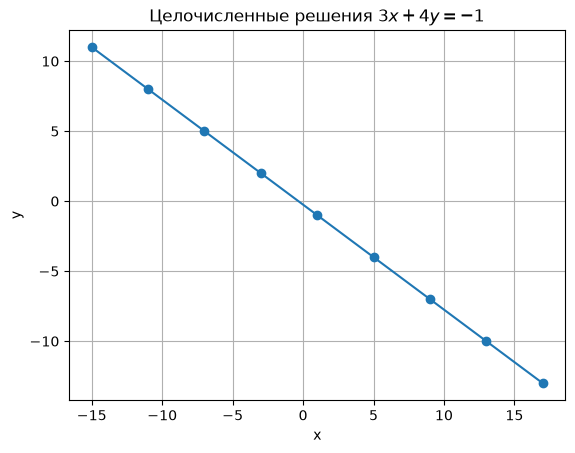

In [30]:
# Выполните задания здесь:
import numpy as np
import matplotlib.pyplot as plt

# Для визуализации не предполагаем, что Задание 1.7 уже решено:
# строим одно частное решение непосредственно из extended_gcd().
a, b, c = 3, 4, -1

# extended_gcd даёт g и коэффициенты, для которых a*x + b*y = g.
# Уравнение a*x + b*y = c получается умножением на c/g, поскольку g делит c.
g, bezout_x, bezout_y = extended_gcd(a, b)
x0 = bezout_x * (c // g)
y0 = bezout_y * (c // g)

# Шаг формулы (1.20): (b/g, -a/g).
dx = b // g
dy = -(a // g)
print(f"частное решение ({x0}, {y0}), шаг ({dx}, {dy})")
assert a * x0 + b * y0 == c
assert (dx, dy) == (b // g, -(a // g))

# Несколько целых t. Соседние точки отличаются ровно на один шаг параметра.
t = np.arange(-4, 5)
x = x0 + dx * t
y = y0 + dy * t

# 1. Все точки лежат на прямой 3x + 4y = -1.
assert np.all(a * x + b * y == c)

# 2 и 3. Разность соседних точек постоянна и равна вектору (b/g, -a/g).
step_x = np.diff(x)
step_y = np.diff(y)
assert np.all(step_x == dx)
assert np.all(step_y == dy)
print("соседний шаг по x:", step_x.tolist())
print("соседний шаг по y:", step_y.tolist())
print("точки:", list(zip(x.tolist(), y.tolist())))

plt.plot(x, y, "o-")
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Целочисленные решения $3x+4y=-1$")
plt.show()



<img src="./figs/1.png" alt="Компьютер" width="500" height="400">

## 1.5. Обратный элемент по модулю: первое криптографически значимое следствие

Для $n\ge2$ обратный к $a$ элемент по модулю $n$ определяется сравнением

$$
ax\equiv1\pmod n.
\tag{1.22}
$$

Критерий существования:

$$
a^{-1}\pmod n\text{ существует}\iff\gcd(a,n)=1.
\tag{1.23}
$$

Действительно, при $\gcd(a,n)=1$ соотношение Безу даёт

$$
ax+ny=1.
\tag{1.24}
$$

Следовательно,

$$
ax\equiv1\pmod n.
$$

Обратное направление следует из представления $ax-1=kn$: тогда $ax-kn=1$, поэтому любой общий делитель $a$ и $n$ делит $1$.

### Контракт и корректность `mod_inverse`

Для `modulus >= 2` функция должна:

- вернуть наименьшего неотрицательного представителя $x$, если $\gcd(a,\texttt{modulus})=1$;
- отклонить вход, если обратного элемента не существует.

Ключевая строка

```python
g, x, _ = extended_gcd(a, modulus)
```

даёт

$$
ax+\texttt{modulus}\cdot y=g.
$$

Если $g=1$, то $x$ представляет обратный класс:

$$
ax\equiv1\pmod{\texttt{modulus}}.
$$

Возврат `x % modulus` не меняет класс вычетов, а только выбирает его канонического представителя

$$
0\le x<\texttt{modulus}.
$$

Таким образом, здесь особенно явно проявляется связь

$$
\boxed{\text{теорема о существовании}\longleftrightarrow\text{контракт функции}.}
$$

Расширенный алгоритм Евклида поэтому является не отдельной учебной техникой, а вычислительным механизмом деления в модульной арифметике.


In [31]:
def mod_inverse(a: int, modulus: int) -> int:
    if modulus < 2:
        raise ValueError("modulus must be >= 2")
    g, x, _ = extended_gcd(a, modulus)
    if g != 1:
        raise ValueError("inverse does not exist")
    return x % modulus

assert mod_inverse(7, 26) == 15
assert (7 * mod_inverse(7, 26)) % 26 == 1
assert mod_inverse(-3, 7) == 2

# Проверяем математический контракт на случайных допустимых входах.
for _ in range(100):
    modulus = secrets.randbelow(10_000 - 2) + 2
    a = secrets.randbelow(20_001) - 10_000
    if gcd(a, modulus) == 1:
        inv = mod_inverse(a, modulus)
        assert 0 <= inv < modulus
        assert (a * inv) % modulus == 1


<div style="background-color: #3a372c; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Практика. Контракт, проверка и криптографический масштаб

1. Объясните, почему проверка `g != 1` выражает математическое условие существования обратного элемента, а `modulus < 2` задаёт программный контракт функции.
2. Проверьте 500 случайных пар $(a,n)$; когда `gcd(a, n) == 1`, сравните `mod_inverse(a, n)` с `pow(a, -1, n)`.
3. Для невзаимно простых пар убедитесь, что функция корректно отклоняет вход.
4. Объясните, почему отрицательный коэффициент Безу не является ошибкой и почему результат `x % modulus` является корректным представителем обратного класса.
5. Сгенерируйте модуль $n$ ровно из 2048 бит и случайное $1\le a<n$. Если $\gcd(a,n)\ne1$, выберите новое $a$. Затем измерьте время `mod_inverse(a, n)`, проверьте `(a * inv) % n == 1` и сравните результат с `pow(a, -1, n)`.
6. Объясните, почему расширенный алгоритм Евклида остаётся практически применимым при 2048-битных входах, тогда как перебор кандидатов на обратный элемент — нет.

</div>

In [32]:
# Выполните задания здесь:

import time

# Пункт 1.
# g != 1 — это критерий (1.23): обратный элемент существует тогда и только тогда,
# когда gcd(a, modulus) = 1. Ветка ValueError срабатывает ровно там,
# где теорема говорит, что решения сравнения ax ≡ 1 (mod n) нет.
# modulus < 2 — не эта теорема. Обратный элемент в курсе определён для n >= 2,
# и представитель ищется в диапазоне 0 <= x < modulus. Модуль 0 или 1
# в этот контракт не входит, поэтому функция отклоняет его до алгоритма Евклида.


# Пункты 2 и 3. Пятьсот случайных пар.
# Если числа взаимно просты, mod_inverse обязан совпасть с pow(a, -1, n):
# оба возвращают наименьший неотрицательный обратный элемент.
# Если нет, mod_inverse обязан выбросить ValueError, а не вернуть «какой-нибудь» остаток.
checked_inverses = 0
rejected_inputs = 0
for _ in range(500):
    modulus = secrets.randbelow(10_000 - 2) + 2
    element = secrets.randbelow(20_001) - 10_000
    if gcd(element, modulus) == 1:
        inverse = mod_inverse(element, modulus)
        assert inverse == pow(element, -1, modulus)
        assert 0 <= inverse < modulus
        assert (element * inverse) % modulus == 1
        checked_inverses += 1
    else:
        try:
            mod_inverse(element, modulus)
        except ValueError:
            rejected_inputs += 1
        else:
            raise AssertionError("не взаимно простая пара должна быть отклонена")

print(f"взаимно простых пар: {checked_inverses}, отклонённых: {rejected_inputs}")
assert checked_inverses > 0 and rejected_inputs > 0


# Пункт 4. Отрицательный коэффициент Безу — тот же класс вычетов.
# Для 7 и 26 алгоритм возвращает x = -11, не 15.
# Это не ошибка: -11 ≡ 15 (mod 26), потому что -11 + 26 = 15.
# Сравнение совместимо с умножением, формула (1.12):
# 7*(-11) ≡ 7*15 ≡ 1 (mod 26).
# Выражение x % modulus только выбирает представитель 0 <= x < modulus.
g, bezout_x, _ = extended_gcd(7, 26)
canonical = bezout_x % 26
print(f"коэффициент Безу для 7 и 26: {bezout_x}, представитель: {canonical}")
assert g == 1
assert bezout_x < 0
assert canonical == mod_inverse(7, 26) == 15
assert (7 * bezout_x) % 26 == 1
assert (7 * canonical) % 26 == 1


# Пункт 5. Модуль ровно из 2048 бит и взаимно простой элемент 1 <= a < n.
modulus = random_exact_bits(2048)
element = secrets.randbelow(modulus - 1) + 1
while gcd(element, modulus) != 1:
    element = secrets.randbelow(modulus - 1) + 1

started = time.perf_counter()
inverse = mod_inverse(element, modulus)
elapsed = time.perf_counter() - started
print(f"битовая длина модуля: {modulus.bit_length()}")
print(f"mod_inverse для 2048 бит: {elapsed:.6f} с")
assert (element * inverse) % modulus == 1
assert inverse == pow(element, -1, modulus)


# Пункт 6. Почему Евклид применим, а перебор нет.
# Перебор ищет x = 0, 1, ..., n-1 и проверяет (a*x) % n == 1.
# Таких кандидатов n ≈ 2^2047. Это экспонента по битовой длине.
# Расширенный алгоритм Евклида делает O(L) делений при L = 2048,
# а по битовым операциям остаётся в пределах O(L^2), как в разборе extended_gcd.
# Поэтому одна пара из 2048 бит считается за доли секунды,
# а перебор кандидатов на этой длине не заканчивается.
print("Перебор обратного элемента смотрел бы около 2^2047 кандидатов; Евклид делает O(L) делений.")



взаимно простых пар: 325, отклонённых: 175
коэффициент Безу для 7 и 26: -11, представитель: 15
битовая длина модуля: 2048
mod_inverse для 2048 бит: 0.008116 с
Перебор обратного элемента смотрел бы около 2^2047 кандидатов; Евклид делает O(L) делений.


### 1.5.1. Линейные сравнения

Рассмотрим линейное сравнение

$$ax\equiv b\pmod n,\qquad n\ge 2. \tag{1.25}$$

<div style="border-top: 1px solid #999; border-bottom: 1px solid #999; padding: 12px 4px; margin: 18px 0;">

**Теорема 1.4 (критерий разрешимости линейного сравнения).** Пусть

$$g=\gcd(a,n).$$

Тогда сравнение (1.25) имеет решение тогда и только тогда, когда

$$\boxed{g\mid b}. \tag{1.26}$$

Если условие (1.26) выполнено, то сравнение имеет ровно $g$ различных решений по модулю $n$.

</div>

Критерий существования уже можно предвидеть из теоремы 1.3: сравнение $ax\equiv b\pmod n$ эквивалентно существованию целого $y$, для которого $ax+ny=b$. Ниже мы ещё раз докажем критерий непосредственно в языке сравнений, одновременно закрепляя схему «необходимость + достаточность», а затем отдельно установим число решений.

**Доказательство.** Обозначим

$$P=\text{«сравнение }ax\equiv b\pmod n\text{ имеет решение»},$$

$$Q=\text{«}g\mid b\text{»},\qquad g=\gcd(a,n).$$

Теорема утверждает

$$P\leftrightarrow Q.$$

В формулировке теоремы $P$ — исследуемое свойство (разрешимость сравнения), а $Q$ — условие, являющееся критерием этого свойства. Поэтому необходимо доказать две импликации:

$$\underbrace{P\to Q}_{\text{необходимость условия }g\mid b}\qquad\text{и}\qquad\underbrace{Q\to P}_{\text{достаточность условия }g\mid b}.$$

Это ровно две части доказательства. Каждая доказанная импликация допускает два эквивалентных прочтения: например, $P\to Q$ одновременно означает, что $P$ достаточно для $Q$ и что $Q$ необходимо для $P$. В данной теореме нас интересует именно условие $Q$ как критерий свойства $P$, что уже задано формулировкой теоремы.

**1. Необходимость условия $g\mid b$.** Предположим, что сравнение (1.25) имеет решение. Тогда существует $x\in\mathbb Z$ такой, что

$$ax\equiv b\pmod n.$$

По определению сравнения по модулю это означает

$$n\mid(ax-b).$$

Следовательно, существует $k\in\mathbb Z$ такое, что

$$ax-b=nk.$$

Перенося $nk$ в левую часть, получаем $ax-nk=b$. Положив $y=-k$, записываем это равенство в форме целой линейной комбинации:

$$ax+ny=b. \tag{1.27}$$

Так как $g=\gcd(a,n)$, то $g\mid a$ и $g\mid n$. Поэтому $g$ делит любую целую линейную комбинацию чисел $a$ и $n$, в частности левую часть (1.27). Следовательно,

$$g\mid b.$$

Тем самым доказана импликация $P\to Q$, то есть **необходимость** условия $g\mid b$ для разрешимости сравнения.

**2. Достаточность условия $g\mid b$.** Теперь предположим, что

$$g\mid b.$$

Нужно показать, что сравнение (1.25) имеет решение. По соотношению Безу существуют $c,d\in\mathbb Z$ такие, что

$$ac+nd=g. \tag{1.28}$$

Так как $g\mid b$, число $b/g$ целое. Умножая (1.28) на $b/g$, получаем

$$a\left(c\frac bg\right)+n\left(d\frac bg\right)=b. \tag{1.29}$$

Следовательно,

$$a\left(c\frac bg\right)\equiv b\pmod n,$$

поэтому

$$x_0=c\frac bg \tag{1.30}$$

является одним из решений сравнения (1.25).

Тем самым доказана импликация $Q\to P$, то есть **достаточность** условия $g\mid b$ для разрешимости сравнения. Итак, критерий разрешимости доказан:

$$P\leftrightarrow Q.$$

Остаётся доказать вторую часть утверждения — определить число различных решений при выполнении $g\mid b$.

**3. Число решений.** Пусть условие $g\mid b$ выполнено. Мы уже знаем, что решение существует. Теперь требуется выяснить, сколько различных классов решений получается **по модулю $n$**.

Поскольку

$$g=\gcd(a,n),$$

можно записать

$$a=ga',\qquad n=gn'.$$

А из условия $g\mid b$ следует, что

$$b=gb'.$$

Иными словами, положим

$$a'=\frac ag,\qquad b'=\frac bg,\qquad n'=\frac ng.$$

При этом

$$\gcd(a',n')=1.$$

Действительно, если бы числа $a'$ и $n'$ имели общий делитель $d>1$, то число $gd$ было бы общим делителем $a$ и $n$, большим $g=\gcd(a,n)$, что невозможно.

Исходное сравнение эквивалентно условию

$$n\mid(ax-b).$$

Подставляя $a=ga'$, $b=gb'$ и $n=gn'$, получаем

$$gn'\mid g(a'x-b').$$

После сокращения общего множителя $g$ это равносильно

$$n'\mid(a'x-b'),$$

то есть приведённому сравнению

$$a'x\equiv b'\pmod{n'}. \tag{1.31}$$

Поскольку $\gcd(a',n')=1$, элемент $a'$ имеет обратный по модулю $n'$. Поэтому (1.31) имеет единственный класс решений по модулю $n'$:

$$x\equiv x_0\pmod{n'}.$$

Здесь важно различать **единственное решение по модулю $n'$** и единственное целое значение $x$. Запись $x\equiv x_0\pmod{n'}$ означает, что все целые решения имеют вид

$$x=x_0+tn',\qquad t\in\mathbb Z.$$

Так как $n'=n/g$, получаем

$$x=x_0+t\frac ng,\qquad t\in\mathbb Z.$$

Теперь эти целые решения нужно рассмотреть **по модулю $n$**. Поскольку

$$n=gn',$$

после $g$ шагов величины $n'$ получаем

$$x_0+gn'=x_0+n\equiv x_0\pmod n.$$

Следовательно, достаточно взять

$$t=0,1,\ldots,g-1.$$

Это даёт $g$ классов:

$$x_0,\quad x_0+n',\quad x_0+2n',\quad\ldots,\quad x_0+(g-1)n'.$$

Покажем, что они действительно попарно различны по модулю $n$. Пусть для некоторых $0\le i<j\le g-1$ выполняется

$$x_0+in'\equiv x_0+jn'\pmod n.$$

Тогда

$$n\mid(j-i)n'.$$

Так как $n=gn'$, это означает

$$g\mid(j-i).$$

Но

$$1\le j-i\le g-1,$$

поэтому $g$ не может делить $j-i$. Получили противоречие. Значит, указанные $g$ классов попарно различны по модулю $n$.

Следующий класс уже совпадает с первым:

$$x_0+gn'=x_0+n\equiv x_0\pmod n.$$

Таким образом, все различные решения исходного сравнения по модулю $n$ имеют вид

$$\boxed{x=x_0+k\frac ng,\qquad k=0,1,\ldots,g-1}. \tag{1.32}$$

Следовательно, при $g\mid b$ исходное сравнение имеет ровно $g$ различных решений по модулю $n$. $\square$

<div style="background-color: #263529; padding: 20px; border-radius: 10px; border-left: 4px solid #3a8f5c;">

### Пример 1.5. Случай нескольких решений

Решим

$$4x\equiv2\pmod{10}.$$

Имеем $g=\gcd(4,10)=2$ и $2\mid2$, поэтому решения существуют и их должно быть ровно два по модулю $10$. После деления на $g$:

$$2x\equiv1\pmod5.$$

Так как $2^{-1}\equiv3\pmod5$, получаем $x\equiv3\pmod5$. Следовательно, по модулю $10$:

$$\boxed{x\equiv3,\ 8\pmod{10}}.$$

Этот пример показывает, почему функция решения общего линейного сравнения должна уметь возвращать **все** решения, а не только один представитель.

</div>

<div style="background-color: #242b30; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.8. Решение линейных сравнений

Реализуйте функцию

```python
def solve_linear(a: int, b: int, n: int) -> list[int]:
    ...
```

которая решает сравнение

$$ax\equiv b\pmod n,\qquad n\ge2,$$

и возвращает **все различные решения** в диапазоне $0\le x<n$, отсортированные по возрастанию. Если решений нет, функция должна вернуть пустой список `[]`.

Используйте `extended_gcd()` и доказанный выше критерий разрешимости; полный перебор $x=0,1,\ldots,n-1$ не допускается.

Проверьте, что

```python
solve_linear(4, 2, 10) == [3, 8]
solve_linear(2, 1, 4) == []
```

Затем с помощью функции решите

$$27x\equiv4\pmod{25}.$$

Для каждого возвращённого значения $x$ программно проверьте условие

```python
(a * x - b) % n == 0
```

Наконец, объясните:

1. почему условие `gcd(a, n) | b` определяет существование решения;
2. почему при $g=\gcd(a,n)>1$ и $g\mid b$ решений по модулю $n$ ровно $g$;
3. почему при $g=1$ решение единственно по модулю $n$ и задача сводится к умножению $b$ на обратный элемент к $a$.

</div>

In [33]:
# Ваше решение:


def solve_linear(a: int, b: int, n: int) -> list[int]:
    """Все решения ax ≡ b (mod n) в диапазоне 0 <= x < n, по возрастанию.

    Если решений нет, возвращает пустой список. Перебора x = 0, ..., n-1 нет:
    одно частное решение берётся из extended_gcd, остальные — шагом n/g.
    """
    if n < 2:
        raise ValueError("n must be >= 2")

    # a*coefficient + n*y = g. Это соотношение Безу для пары (a, n).
    g, coefficient, _ = extended_gcd(a, n)
    if b % g != 0:
        return []

    # Умножение Безу на b/g даёт частное решение, формула (1.30).
    x0 = coefficient * (b // g)
    step = n // g
    # Формула (1.32): ровно g классов, k = 0, 1, ..., g-1.
    # Остаток по модулю n кладёт каждый класс в диапазон 0 <= x < n.
    return sorted((x0 + k * step) % n for k in range(g))


assert solve_linear(4, 2, 10) == [3, 8]
assert solve_linear(2, 1, 4) == []

# 27x ≡ 4 (mod 25).
solutions = solve_linear(27, 4, 25)
print("27x ≡ 4 (mod 25):", solutions)
for x in solutions:
    assert (27 * x - 4) % 25 == 0
assert solutions == [2]


# 1. Почему gcd(a, n) | b решает вопрос о существовании.
# ax ≡ b (mod n) означает, что n делит ax - b, то есть ax + n*y = b
# для некоторого целого y. Число g = gcd(a, n) делит и a, и n,
# поэтому делит левую часть и обязано делить b. Это необходимость.
# Если g делит b, соотношение Безу a*c + n*d = g умножается на b/g
# и даёт частное решение. Это достаточность. Вместе это теорема 1.4.


# 2. Почему при g > 1 и g | b решений ровно g.
# Деление сравнения на g приводит его к a'x ≡ b' (mod n/g)
# с gcd(a', n/g) = 1, то есть к одному классу по модулю n/g.
# Шаг этого класса равен n/g. По модулю n в этот шаг укладывается
# ровно g различных остатков: x0, x0 + n/g, ..., x0 + (g-1)*n/g.
# Следующий уже совпадает с первым, потому что g*(n/g) = n.
# Для 4x ≡ 2 (mod 10) имеем g = 2 и шаг 5, поэтому решения 3 и 8.


# 3. Почему при g = 1 решение одно и это умножение на обратный элемент.
# Шаг n/g равен n, поэтому по модулю n остаётся один класс.
# При g = 1 коэффициент Безу c сам является обратным к a по модулю n:
# a*c ≡ 1 (mod n). Частное решение x0 = c*b, значит x ≡ a^{-1}*b (mod n).
# Для 27 и 25 НОД равен 1, поэтому решение единственно: x ≡ 2 (mod 25).
print("При g = 1 сравнение сводится к умножению b на обратный элемент к a.")



27x ≡ 4 (mod 25): [2]
При g = 1 сравнение сводится к умножению b на обратный элемент к a.


## 1.6. Быстрое модульное возведение в степень — центральная вычислительная операция

Наивный способ сначала вычислить $a^e$, а затем взять остаток по модулю $n$ непригоден для криптографических размеров. Даже повторное умножение с редукцией после каждого шага требует $O(e)$ модульных умножений.

Используем двоичное представление показателя:

$$
e=\sum_{i=0}^{k-1} e_i2^i,\qquad e_i\in\{0,1\}.
\tag{1.33}
$$

Тогда

$$
a^e=\prod_{i:e_i=1}a^{2^i}.
\tag{1.34}
$$

Последовательные квадраты позволяют вычислять

$$
a,a^2,a^4,a^8,\ldots \pmod n.
\tag{1.35}
$$

Число итераций имеет порядок $\log_2 e$, то есть порядок битовой длины показателя.

### От наивного метода к двоичному

Если $L=\ell(e)$ — битовая длина показателя, то $e$ имеет порядок $2^L$. Поэтому повторное умножение требует порядка

$$
O(e)=O(2^L)
$$

модульных умножений относительно размера представления показателя, тогда как двоичный метод использует

$$
O(\log e)=O(L)
$$

итераций.

Именно это различие делает модульное возведение в большую степень практически выполнимым в RSA, Диффи—Хеллмане и Эль-Гамале.

### Инвариант и доказательство корректности `mod_pow`

Пусть исходные значения основания и показателя равны $a$ и $E$. После приведения основания по модулю $n$ поддерживаем инвариант

$$
\boxed{
\texttt{result}\cdot \texttt{base}^{\,\texttt{e}}
\equiv
a^E
\pmod n.
}
$$

В начале

$$
\texttt{result}=1,\qquad
\texttt{base}\equiv a\pmod n,\qquad
\texttt{e}=E,
$$

поэтому инвариант выполнен.

Если текущий показатель нечётный, $\texttt{e}=2q+1$, алгоритм переносит один множитель `base` в `result`, затем заменяет `base` на `base**2` и `e` на $q$. Тогда

$$
(\texttt{result}\cdot\texttt{base})\,
(\texttt{base}^2)^q
= \texttt{result}\cdot\texttt{base}^{2q+1},
$$

поэтому значение левой части инварианта не меняется.

Если текущий показатель чётный, $\texttt{e}=2q$, то `result` не меняется, а

$$
\texttt{result}\,(\texttt{base}^2)^q
= \texttt{result}\cdot\texttt{base}^{2q}.
$$

Следовательно, инвариант сохраняется и в этом случае.

При завершении цикла $\texttt{e}=0$, поэтому из инварианта следует

$$
\texttt{result}\equiv a^E\pmod n.
$$

Возвращаемое значение является требуемым наименьшим неотрицательным представителем класса $a^E\bmod n$.

### Паспорт алгоритма `mod_pow`

**Контракт.** Вход: `modulus > 0`, `exponent >= 0`. Выход: целое число `r`, для которого

$$
0\le r<\texttt{modulus},
\qquad
r\equiv \texttt{base}^{\texttt{exponent}}\pmod{\texttt{modulus}}.
$$

**Арифметическая стоимость.** $O(\log e)$ модульных умножений для показателя $e$.

**Битовая стоимость.** Если $E=\ell(e)$, $L=\ell(n)$ и $M(L)$ — стоимость $L$-битного умножения (с редукцией того же асимптотического порядка), то полная стоимость равна $O(E\,M(L))$. При классическом умножении это $O(EL^2)$. Подробный вывод приведён ниже.

**Инженерное замечание.** Собственная реализация нужна для понимания алгоритма и доказательства корректности. В обычном Python для вычислений следует использовать `pow(base, exponent, modulus)`. Учебная реализация не является реализацией с постоянным временем выполнения и не должна использоваться как готовый промышленный криптографический примитив.


<div style="background-color: #141d16; padding: 20px; border-radius: 10px; border-left: 4px solid #3a8f5c;">

### Пример 1.6. $7^{13}\bmod 23$

Так как $13=(1101)_2=8+4+1$,
$$7^{13}=7^8\cdot7^4\cdot7.$$
Все квадраты и произведения можно немедленно редуцировать по модулю 23. Именно эта схема масштабируется к криптографическим показателям.

</div>

In [34]:
def mod_pow(base: int, exponent: int, modulus: int) -> int:
    if modulus <= 0:
        raise ValueError("modulus must be positive")
    if exponent < 0:
        raise ValueError("this implementation expects exponent >= 0")

    result = 1 % modulus
    base %= modulus
    e = exponent

    while e:
        if e & 1:
            result = (result * base) % modulus
        base = (base * base) % modulus
        e >>= 1

    return result

assert mod_pow(7, 13, 23) == pow(7, 13, 23)
assert mod_pow(2, 0, 17) == 1

### Два направления двоичного алгоритма

Реализация `mod_pow` выше обрабатывает двоичную запись показателя **справа налево** (*right-to-left binary exponentiation*): на каждой итерации рассматривается младший бит текущего значения `e`, а `base` последовательно принимает значения

$$
a,a^2,a^4,a^8,\ldots \pmod n.
$$

Ту же двоичную структуру можно использовать в противоположном направлении. Пусть уже прочитанный слева префикс битов показателя задаёт число $p$, а текущий накопленный результат удовлетворяет

$$
r\equiv a^p\pmod n.
$$

Если следующий бит равен $b\in\{0,1\}$, новый префикс имеет значение

$$
p'=2p+b.
$$

Поэтому

$$
a^{p'}=a^{2p+b}=(a^p)^2a^b.
$$

Отсюда непосредственно получается шаг алгоритма:

$$
r\leftarrow r^2\pmod n,
$$

а при $b=1$ дополнительно

$$
r\leftarrow ra\pmod n.
$$

Так возникает **двоичное возведение в степень слева направо** (*left-to-right binary exponentiation*). В отличие от предыдущей реализации, здесь естественный инвариант формулируется через уже обработанный префикс показателя: после чтения префикса со значением $p$ выполняется $r\equiv a^p\pmod n$.

Оба направления используют $O(\log e)$ шагов и отражают одну математическую идею, но поддерживают разные состояния программы.

### Одинаковый результат — разная вычислительная стоимость

Для небольших входов математически эквивалентны все три записи:

```python
(base ** exponent) % modulus
mod_pow(base, exponent, modulus)
pow(base, exponent, modulus)
```

Однако вычислительно они принципиально различаются. Выражение `(base ** exponent) % modulus` сначала строит целое число $\texttt{base}^{\texttt{exponent}}$ и только затем выполняет редукцию. Учебные двоичные алгоритмы редуцируют промежуточные результаты по модулю на каждом шаге. Трёхаргументный `pow(base, exponent, modulus)` также выполняет модульное возведение в степень без явного построения гигантского значения $\texttt{base}^{\texttt{exponent}}$.

Поэтому при сравнении алгоритмов важно сначала анализировать **число и тип арифметических операций**, а измерение wall-clock time рассматривать как отдельный инженерный эксперимент: оно зависит не только от асимптотики, но и от реализации больших целых и встроенных операций Python.

In [35]:
def mod_pow_left_to_right(base: int, exponent: int, modulus: int) -> int:
    """Учебное left-to-right binary modular exponentiation."""
    if modulus <= 0:
        raise ValueError("modulus must be positive")
    if exponent < 0:
        raise ValueError("this implementation expects exponent >= 0")

    result = 1 % modulus
    base %= modulus

    for bit in bin(exponent)[2:]:
        result = (result * result) % modulus
        if bit == "1":
            result = (result * base) % modulus

    return result


def mod_pow_repeated(base: int, exponent: int, modulus: int) -> int:
    """Учебное повторное умножение с редукцией после каждого шага."""
    if modulus <= 0:
        raise ValueError("modulus must be positive")
    if exponent < 0:
        raise ValueError("this implementation expects exponent >= 0")

    result = 1 % modulus
    base %= modulus
    for _ in range(exponent):
        result = (result * base) % modulus
    return result


for base, exponent, modulus in [
    (7, 13, 23),
    (5, 90, 91),
    (-3, 17, 101),
    (2, 0, 17),
    (123, 456, 1),
]:
    expected = pow(base, exponent, modulus)
    assert mod_pow(base, exponent, modulus) == expected
    assert mod_pow_left_to_right(base, exponent, modulus) == expected
    assert mod_pow_repeated(base, exponent, modulus) == expected

### Битовая сложность `mod_pow`

Оценка $O(\log e)$ в паспорте `mod_pow` считает **модульные умножения**, а не битовые операции. Зафиксируем оба размера входа:

$$
E=\ell(e),\qquad L=\ell(n).
$$

В двоичном алгоритме выполняется $O(E)$ шагов. Все промежуточные основания и результаты после редукции лежат в диапазоне $0,\ldots,n-1$, поэтому их длина не превосходит $L$ бит.

Обозначим через $M(L)$ битовую стоимость умножения двух $L$-битных чисел. Если умножение вместе с последующей редукцией по $L$-битному модулю имеет тот же асимптотический порядок, одно модульное умножение стоит $O(M(L))$. Отсюда

$$
T_{\mathrm{mod\_pow}}(e,n)=O(E\,M(L))
=O(\log e\cdot M(\log n)).
$$

При классическом школьном умножении $M(L)=O(L^2)$, поэтому

$$
T_{\mathrm{mod\_pow}}=O(EL^2)
=O(\log e\cdot(\log n)^2).
$$

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Почему здесь два эксперимента?</strong> Время `mod_pow` зависит и от $E$, и от $L$. Если одновременно удваивать обе величины, невозможно по одному timing понять, какой фактор вызвал рост. Поэтому сначала фиксируем длину показателя и меняем длину модуля, затем фиксируем модуль и меняем длину показателя.

</div>

Эмпирический замер производительности (*benchmark*) ниже сравнивает учебную Python-реализацию `mod_pow` со встроенным `pow`. Он иллюстрирует тенденции, но не доказывает асимптотику: CPython использует собственные оптимизированные алгоритмы длинной арифметики, а постоянные расходы Python особенно заметны на малых размерах.

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

</div>

In [36]:
def _median_call_time(func, args_factory, repeats=5):
    samples = []
    for _ in range(repeats):
        args = args_factory()
        start = perf_counter()
        value = func(*args)
        samples.append(perf_counter() - start)
        # Возвращаем значение только для того, чтобы вычисление нельзя было считать "неиспользованным".
        assert isinstance(value, int)
    return median(samples)


bit_sizes = (256, 512, 1024, 2048, 4096)

# Эксперимент A: E фиксировано, меняется L = bit_length(modulus).
fixed_exponent_bits = 256
modulus_timings = []
for modulus_bits in bit_sizes:
    exponent = random_exact_bits(fixed_exponent_bits)

    def args_factory(mb=modulus_bits, e=exponent):
        modulus = random_exact_bits(mb) | 1
        base = secrets.randbelow(modulus)
        return base, e, modulus

    t_edu = _median_call_time(mod_pow, args_factory)
    t_builtin = _median_call_time(pow, args_factory)
    modulus_timings.append((modulus_bits, t_edu, t_builtin))

print("Эксперимент A: E = 256 бит, меняется L")
print(" L, bits | mod_pow, ms | pow, ms")
print("---------|-------------|--------")
for bits, t_edu, t_builtin in modulus_timings:
    print(f"{bits:8d} | {1000*t_edu:11.4f} | {1000*t_builtin:6.4f}")

# Эксперимент B: L фиксировано, меняется E = bit_length(exponent).
fixed_modulus_bits = 2048
modulus = random_exact_bits(fixed_modulus_bits) | 1
exponent_timings = []
for exponent_bits in bit_sizes:

    def args_factory(eb=exponent_bits, m=modulus):
        exponent = random_exact_bits(eb)
        base = secrets.randbelow(m)
        return base, exponent, m

    t_edu = _median_call_time(mod_pow, args_factory)
    t_builtin = _median_call_time(pow, args_factory)
    exponent_timings.append((exponent_bits, t_edu, t_builtin))

print("\nЭксперимент B: L = 2048 бит, меняется E")
print(" E, bits | mod_pow, ms | pow, ms")
print("---------|-------------|--------")
for bits, t_edu, t_builtin in exponent_timings:
    print(f"{bits:8d} | {1000*t_edu:11.4f} | {1000*t_builtin:6.4f}")

print("\nИнтерпретация: сравнивайте тенденции, а не пытайтесь по пяти точкам")
print("экспериментально 'доказать' конкретную степень асимптотики.")

Эксперимент A: E = 256 бит, меняется L
 L, bits | mod_pow, ms | pow, ms
---------|-------------|--------
     256 |      0.1795 | 0.1259
     512 |      0.4222 | 0.3363
    1024 |      1.1861 | 0.8757
    2048 |      2.8244 | 2.1501
    4096 |      9.7104 | 8.3693

Эксперимент B: L = 2048 бит, меняется E
 E, bits | mod_pow, ms | pow, ms
---------|-------------|--------
     256 |      2.7674 | 2.1640
     512 |      5.9903 | 4.8945
    1024 |     12.5747 | 8.8325
    2048 |     22.5297 | 18.8325
    4096 |     49.1423 | 34.0697

Интерпретация: сравнивайте тенденции, а не пытайтесь по пяти точкам
экспериментально 'доказать' конкретную степень асимптотики.


<div style="background-color: #2d2b22; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Исследование 1.3. Наивное и быстрое модульное возведение в степень

1. До запуска выпишите биты показателя `13` и предскажите, на каких итерациях меняется `result` в `mod_pow`.
2. Для готовой right-to-left реализации явно проверьте инвариант
   $$
   \texttt{result}\cdot\texttt{base}^{\,\texttt{e}}
   \equiv a^E\pmod n
   $$
   на каждом шаге для нескольких небольших примеров.
3. Для `mod_pow_left_to_right` проследите обработанные префиксы двоичной записи показателя и на каждом шаге проверьте инвариант $r\equiv a^p\pmod n$, где $p$ — значение уже прочитанного префикса.
4. Сравните четыре способа вычисления:
   ```python
   (base ** exponent) % modulus
   mod_pow_repeated(base, exponent, modulus)
   mod_pow(base, exponent, modulus)
   pow(base, exponent, modulus)
   ```
   Сначала объясните различия **без измерения времени**: какие промежуточные числа строятся и сколько модульных умножений требуется.
5. Посчитайте число модульных умножений в `mod_pow_repeated`, `mod_pow` и `mod_pow_left_to_right`. Сравните результаты для показателей с битовой длиной $8,16,20,24$. Не запускайте повторное умножение там, где эксперимент становится бессмысленно дорогим.

**Challenge.** Возьмите два показателя одинаковой битовой длины $k$: $e_1=2^{k-1}$ (двоичная запись $10\ldots0$) и $e_2=2^k-1$ (двоичная запись $11\ldots1$). Для `mod_pow` и `mod_pow_left_to_right` посчитайте **отдельно** число возведений в квадрат и число умножений накопленного результата. Объясните различие через число единичных битов показателя — вес Хэмминга (*Hamming weight*, `int.bit_count()`).

Обратите внимание: в `mod_pow` на последней итерации `base` возводится в квадрат, хотя это значение уже не используется. Сколько таких лишних операций выполняется при каждом вызове? Исправьте реализацию и проверьте её на тех же тестах. Почему зависимость числа операций от битов **секретного** показателя опасна для криптографии и к каким алгоритмам (например, лестнице Монтгомери) это ведёт?

</div>

In [42]:
# Выполните задания здесь:


# Пункт 1. Биты показателя 13 до запуска цикла.
# 13 = 8 + 4 + 1 = (1101)_2.
# mod_pow читает биты справа налево, то есть в порядке 1, 0, 1, 1.
# result меняется только когда младший бит текущего e равен 1.
# Предсказание: result обновляется на 1-й, 3-й и 4-й итерациях.
print("биты 13 справа налево: 1, 0, 1, 1")
print("предсказание: result меняется на итерациях 1, 3 и 4")


def trace_mod_pow(base: int, exponent: int, modulus: int) -> int:
    """Right-to-left с проверкой инварианта result * base^e ≡ a^E (mod n)."""
    result = 1 % modulus
    current_base = base % modulus
    e = exponent
    step = 0
    print(f"right-to-left {base}^{exponent} mod {modulus}")
    while e:
        step += 1
        bit = e & 1
        invariant = (result * pow(current_base, e, modulus)) % modulus
        assert invariant == pow(base, exponent, modulus)
        print(
            f"  шаг {step}: бит {bit}, result до шага = {result}, "
            f"инвариант выполнен"
        )
        if bit:
            result = (result * current_base) % modulus
            print(f"         result стал {result}")
        current_base = (current_base * current_base) % modulus
        e >>= 1
        invariant = (result * pow(current_base, e, modulus)) % modulus
        assert invariant == pow(base, exponent, modulus)
    return result


# Пункт 2. Инвариант на каждом шаге для двух небольших примеров.
assert trace_mod_pow(7, 13, 23) == pow(7, 13, 23)
assert trace_mod_pow(5, 11, 13) == pow(5, 11, 13)


def trace_left_to_right(base: int, exponent: int, modulus: int) -> int:
    """Left-to-right: после префикса со значением p выполнено r ≡ a^p (mod n)."""
    result = 1 % modulus
    current_base = base % modulus
    prefix = 0
    print(f"left-to-right {base}^{exponent} mod {modulus}, биты {bin(exponent)[2:]}")
    for bit in bin(exponent)[2:]:
        result = (result * result) % modulus
        if bit == "1":
            result = (result * current_base) % modulus
        prefix = 2 * prefix + int(bit)
        assert result == pow(base, prefix, modulus)
        print(f"  прочитан бит {bit}, префикс p = {prefix}, r = {result}")
    return result


# Пункт 3. Префиксы 1101 для показателя 13: 1, 11, 110, 1101,
# то есть значения p = 1, 3, 6, 13.
assert trace_left_to_right(7, 13, 23) == pow(7, 13, 23)


# Пункт 4. Четыре способа на маленьком входе дают один остаток.
# Различие не в ответе, а в том, какие числа строятся по дороге.
base, exponent, modulus = 7, 13, 23
full_power = base ** exponent
ways = {
    "(base ** exponent) % modulus": full_power % modulus,
    "mod_pow_repeated": mod_pow_repeated(base, exponent, modulus),
    "mod_pow": mod_pow(base, exponent, modulus),
    "pow": pow(base, exponent, modulus),
}
print("четыре способа для 7^13 mod 23:", ways)
assert len(set(ways.values())) == 1
print(f"целое 7**13 занимает {full_power.bit_length()} бит, остаток меньше 23")
# (base ** exponent) % modulus сначала строит всё число base**exponent
# и только потом берёт остаток. Для криптографического показателя
# в этом числе около exponent * log10(base) цифр.
# mod_pow_repeated делает ровно exponent модульных умножений:
# каждый промежуточный результат уже меньше modulus, но шагов столько, сколько e.
# mod_pow делает одно возведение в квадрат на каждый бит и одно умножение result
# на каждый единичный бит. Все числа остаются меньше modulus.
# pow(base, exponent, modulus) тоже не строит base**exponent:
# это модульное возведение в степень внутри интерпретатора.


def count_right(exponent: int) -> tuple[int, int]:
    """(квадраты, умножения result) в исходном mod_pow, без самих умножений."""
    squares = multiplies = 0
    e = exponent
    while e:
        if e & 1:
            multiplies += 1
        squares += 1
        e >>= 1
    return squares, multiplies


def count_left(exponent: int) -> tuple[int, int]:
    """(квадраты, умножения result) в mod_pow_left_to_right."""
    squares = multiplies = 0
    for bit in bin(exponent)[2:]:
        squares += 1
        if bit == "1":
            multiplies += 1
    return squares, multiplies


# Пункт 5. Число умножений для битовых длин 8, 16, 20, 24.
# Повторное умножение не запускаем: его счётчик и так равен показателю,
# а при 24 битах это миллионы шагов.
print("L | показатель | repeated | квадраты | умножения result")
for length in (8, 16, 20, 24):
    sample = random_exact_bits(length)
    squares, multiplies = count_right(sample)
    assert count_left(sample) == (squares, multiplies)
    assert squares == length
    assert multiplies == sample.bit_count()
    print(
        f"{length:2d} | {sample:8d} | {sample:9d} | {squares:8d} | {multiplies:2d}"
    )


# Challenge. Два показателя одной длины k = 8.
# e1 = 2^(k-1) = 10000000_2, вес Хэмминга 1.
# e2 = 2^k - 1 = 11111111_2, вес Хэмминга 8.
k = 8
e1 = 2 ** (k - 1)
e2 = 2 ** k - 1
print(f"e1 = {e1} = {bin(e1)[2:]}, bit_count = {e1.bit_count()}")
print(f"e2 = {e2} = {bin(e2)[2:]}, bit_count = {e2.bit_count()}")
for name, counter in (("mod_pow", count_right), ("left-to-right", count_left)):
    print(name, "e1 квадраты/умножения", counter(e1), "e2", counter(e2))

# Квадратов столько, сколько бит: длина одна и та же, поэтому квадратов поровну.
# Умножений накопленного результата столько, сколько единичных битов.
# Поэтому e2 требует больше умножений result ровно на разность весов Хэмминга.


def mod_pow_without_unused_square(base: int, exponent: int, modulus: int) -> int:
    """mod_pow без последнего неиспользуемого квадрата.

    После сдвига e >>= 1 квадрат нужен только если впереди ещё есть биты.
    При exponent > 0 исходный цикл делал ровно один лишний квадрат за вызов.
    При exponent == 0 цикл и раньше не выполнялся, лишнего квадрата не было.
    """
    if modulus <= 0:
        raise ValueError("modulus must be positive")
    if exponent < 0:
        raise ValueError("this implementation expects exponent >= 0")

    result = 1 % modulus
    current_base = base % modulus
    e = exponent
    while e:
        if e & 1:
            result = (result * current_base) % modulus
        e >>= 1
        if e:
            current_base = (current_base * current_base) % modulus
    return result


for base, exponent, modulus in [
    (7, 13, 23),
    (5, 90, 91),
    (-3, 17, 101),
    (2, 0, 17),
    (123, 456, 1),
]:
    assert mod_pow_without_unused_square(base, exponent, modulus) == pow(
        base, exponent, modulus
    )
print("исправленный mod_pow совпал с pow на тестах ячейки с тремя реализациями")

# Лишний квадрат в исходном mod_pow — один на каждый вызов с положительным показателем.
positive_squares, _ = count_right(13)
fixed_squares = positive_squares - 1
assert fixed_squares == (13).bit_length() - 1
print(f"для 13 исходных квадратов {positive_squares}, после исправления {fixed_squares}")

# Зависимость числа умножений от битов секретного показателя — это побочный канал:
# по времени или энергопотреблению видно, сколько было единичных битов,
# а при наблюдении каждого шага — и где они стоят.
# Лестница Монтгомери на каждом бите выполняет один и тот же набор умножений,
# независимо от того, равен бит нулю или единице. Число операций перестаёт
# выдавать вес Хэмминга секретного показателя.
print(
    "Различие e1 и e2 — это bit_count(). "
    "Для секретного показателя такая зависимость опасна; "
    "лестница Монтгомери делает одинаковую работу на каждом бите."
)



биты 13 справа налево: 1, 0, 1, 1
предсказание: result меняется на итерациях 1, 3 и 4
right-to-left 7^13 mod 23
  шаг 1: бит 1, result до шага = 1, инвариант выполнен
         result стал 7
  шаг 2: бит 0, result до шага = 7, инвариант выполнен
  шаг 3: бит 1, result до шага = 7, инвариант выполнен
         result стал 17
  шаг 4: бит 1, result до шага = 17, инвариант выполнен
         result стал 20
right-to-left 5^11 mod 13
  шаг 1: бит 1, result до шага = 1, инвариант выполнен
         result стал 5
  шаг 2: бит 1, result до шага = 5, инвариант выполнен
         result стал 8
  шаг 3: бит 0, result до шага = 8, инвариант выполнен
  шаг 4: бит 1, result до шага = 8, инвариант выполнен
         result стал 8
left-to-right 7^13 mod 23, биты 1101
  прочитан бит 1, префикс p = 1, r = 7
  прочитан бит 1, префикс p = 3, r = 21
  прочитан бит 0, префикс p = 6, r = 4
  прочитан бит 1, префикс p = 13, r = 20
четыре способа для 7^13 mod 23: {'(base ** exponent) % modulus': 20, 'mod_pow_repeate

## 1.7. Китайская теорема об остатках: от системы сравнений к представлению вычислений

Китайская теорема об остатках, КТО (*Chinese Remainder Theorem, CRT*) связывает несколько сравнений по взаимно простым модулям с одним классом вычетов по произведению этих модулей. Для криптографии важна не только возможность решить систему сравнений, но и более сильная вычислительная идея: арифметику по большому составному модулю можно представить через независимые вычисления по меньшим взаимно простым модулям.


<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Локальные координаты и глобальный класс.</strong>

При попарно взаимно простых $m_1,\ldots,m_k$ отображение

$$
x\longmapsto (x\bmod m_1,\ldots,x\bmod m_k)
$$

переводит один глобальный класс по модулю $N=m_1\cdots m_k$ в набор его локальных координат. КТО утверждает не только существование решения системы сравнений: она даёт обратный переход — по совместимым локальным координатам восстанавливает единственный глобальный класс по модулю $N$.

Поэтому далее полезно читать `crt_encode` как переход **global → local**, а `crt` и `garner_crt` — как конструктивное восстановление **local → global**. Именно этот взгляд позже появится снова в доказательстве корректности RSA по модулям $p$ и $q$ и в ускорении RSA-CRT.

</div>

### Сначала два модуля: КТО как уже знакомое линейное сравнение

Начнём с простейшего случая КТО. Пусть даны два взаимно простых модуля $m$ и $n$:

$$
\gcd(m,n)=1.
$$

Требуется найти все целые числа $x$, которые одновременно удовлетворяют системе сравнений

$$
\begin{cases}
x\equiv a\pmod m,\\
x\equiv b\pmod n.
\end{cases}
\tag{1.36}
$$

Иными словами, мы хотим решить систему (1.36) и понять, по какому модулю найденное решение определяется однозначно.

Из первого сравнения следует, что

$$
x=a+tm
\tag{1.37}
$$

для некоторого $t\in\mathbb Z$.

Теперь потребуем, чтобы такое число $x$ удовлетворяло и второму сравнению. Подставляя (1.37), получаем

$$
a+tm\equiv b\pmod n,
$$

или, что то же самое,

$$
mt\equiv b-a\pmod n.
$$

Мы получили линейное сравнение относительно неизвестного $t$.

Поскольку $\gcd(m,n)=1$, существует обратный элемент $m^{-1}\pmod n$. Поэтому

$$
t\equiv (b-a)m^{-1}\pmod n.
\tag{1.38}
$$

Следовательно, для некоторого $k\in\mathbb Z$

$$
t=(b-a)m^{-1}+kn,
$$

где $m^{-1}$ обозначает любой целый представитель обратного класса по модулю $n$.

Подставляя это выражение в (1.37), получаем все решения исходной системы:

$$
x=a+m(b-a)m^{-1}+kmn.
$$

Следовательно,

$$
\boxed{
x\equiv a+m(b-a)m^{-1}\pmod{mn}.
}
\tag{1.39}
$$

Таким образом, мы не только свели задачу к линейному сравнению, но и действительно нашли решение исходной системы: все её решения образуют один класс вычетов по модулю $mn$.

Остаётся проверить, что построенное число удовлетворяет обоим исходным сравнениям.

По модулю $m$:

$$
x\equiv a\pmod m,
$$

поскольку второе слагаемое в (1.39) содержит множитель $m$.

По модулю $n$, используя $mm^{-1}\equiv1\pmod n$, получаем

$$
x\equiv a+(b-a)mm^{-1}\equiv a+(b-a)\equiv b\pmod n.
$$

Итак, построенный класс действительно является решением системы (1.36).

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Что произошло?</strong>

Задача о двух условиях на $x$ свелась к уже знакомому линейному сравнению относительно вспомогательной переменной $t$:

$$
\boxed{
\begin{array}{c}
x\equiv a\pmod m\\
x\equiv b\pmod n
\end{array}}
\quad\Longrightarrow\quad
mt\equiv b-a\pmod n
\quad\Longrightarrow\quad
\boxed{x\pmod{mn}}.
$$

Именно эту конструкцию китайская теорема об остатках обобщает на произвольное число попарно взаимно простых модулей.

</div>

<div style="background-color: #eef8f0; padding: 20px; border-radius: 10px; border-left: 4px solid #3a8f5c;">

### Пример 1.7. Классическая система

Рассмотрим систему сравнений

$$
\begin{cases}
x\equiv 2\pmod 3,\\
x\equiv 3\pmod 5,\\
x\equiv 2\pmod 7.
\end{cases}
$$

КТО утверждает, что эта система имеет единственный класс решений по модулю

$$
3\cdot5\cdot7=105.
$$

Наименьший неотрицательный представитель этого класса равен

$$
x=23.
$$

Проверим, что найденное число действительно удовлетворяет **каждому сравнению системы**:

$$
\begin{aligned}
23 &\equiv 2\pmod 3,\\
23 &\equiv 3\pmod 5,\\
23 &\equiv 2\pmod 7.
\end{aligned}
$$

Следовательно,

$$
\boxed{x\equiv23\pmod{105}}
$$

— решение исходной системы сравнений.

</div>

<div style="border-top: 1px solid #999; border-bottom: 1px solid #999; padding: 12px 4px; margin: 18px 0;">

<strong>Лемма 1.2. Взаимная простота с произведением</strong>

Если $\gcd(r,s)=1$ и $\gcd(r,t)=1$, то $\gcd(r,st)=1$. Как следствие, если $n_1,\ldots,n_k$ попарно взаимно просты, то каждое $n_i$ взаимно просто с произведением всех остальных модулей, а также $\gcd(n_1\cdots n_{i-1},\,n_i)=1$.

</div>

**Доказательство.** По соотношению Безу существуют целые $u,v,u',v'$ такие, что

$$
ur+vs=1,\qquad u'r+v't=1.
$$

Перемножив эти равенства, получаем

$$
r\,(uu'r+uv't+u'vs)+(vv')\,st=1.
$$

Любой общий делитель $r$ и $st$ делит левую часть, то есть делит $1$. Следовательно, $\gcd(r,st)=1$. Следствие получается индукцией по числу сомножителей. $\square$

Лемма используется ниже дважды: для существования обратных элементов $N_i^{-1}\pmod{n_i}$ и для единственности решения по модулю $N$.

<div style="border-top: 1px solid #999; border-bottom: 1px solid #999; padding: 12px 4px; margin: 18px 0;">

<strong>Теорема 1.5. Китайская теорема об остатках</strong>

Пусть $n_1,\ldots,n_k\ge2$ попарно взаимно просты. Тогда система

$$
x\equiv a_i\pmod{n_i},\qquad i=1,\ldots,k
\tag{1.40}
$$

имеет решение, причём это решение единственно по модулю

$$
N=\prod_{i=1}^{k}n_i.
\tag{1.41}
$$

</div>

**Доказательство существования.**

Для каждого $i$ положим

$$
N_i=\frac{N}{n_i},\qquad
M_i=N_i^{-1}\pmod{n_i}.
\tag{1.42}
$$

Число $N_i$ является произведением всех модулей, кроме $n_i$. Поскольку модули попарно взаимно просты, по лемме 1.2

$$
\gcd(N_i,n_i)=1,
$$

а значит, обратный элемент $M_i$ существует.

Определим **базисный элемент КТО**

$$
e_i=N_iM_i.
\tag{1.43}
$$

Посмотрим, какие остатки имеет $e_i$ по модулям $n_1,\ldots,n_k$.

По модулю $n_i$ из определения $M_i$ получаем

$$
e_i=N_iM_i\equiv1\pmod{n_i}.
$$

Если же $j\ne i$, то число $N_i$ содержит $n_j$ в качестве множителя, поэтому

$$
N_i\equiv0\pmod{n_j},
$$

и, следовательно,

$$
e_i=N_iM_i\equiv0\pmod{n_j}.
$$

Таким образом,

$$
e_i\equiv
\begin{cases}
1\pmod{n_i},\\
0\pmod{n_j},&j\ne i.
\end{cases}
\tag{1.44}
$$

Теперь используем это свойство для построения решения исходной системы.

Умножим $e_i$ на требуемый остаток $a_i$. Тогда

$$
a_i e_i\equiv
\begin{cases}
a_i\pmod{n_i},\\
0\pmod{n_j},&j\ne i.
\end{cases}
$$

Иными словами, слагаемое $a_i e_i$ обеспечивает требуемый остаток $a_i$ по модулю $n_i$ и одновременно даёт нулевой остаток по всем остальным модулям.

Поэтому, если сложить такие слагаемые для всех $i$,

$$
a_1e_1+a_2e_2+\cdots+a_ke_k,
$$

то по каждому модулю $n_i$ в этой сумме останется ровно тот остаток $a_i$, который требуется в $i$-м сравнении исходной системы.

Это подсказывает следующую конструкцию:

$$
\boxed{
x\equiv\sum_{i=1}^{k}a_i e_i
=\sum_{i=1}^{k}a_iN_iM_i
\pmod N.
}
\tag{1.45}
$$

Проверим непосредственно, что построенный класс действительно является решением.

Зафиксируем произвольный индекс $i$ и рассмотрим сумму из (1.45) по модулю $n_i$:

$$
x\equiv
a_1e_1+\cdots+a_ie_i+\cdots+a_ke_k
\pmod{n_i}.
$$

Согласно (1.44), для каждого $j\ne i$

$$
e_j\equiv0\pmod{n_i},
$$

поэтому все соответствующие слагаемые исчезают. Для оставшегося слагаемого имеем

$$
e_i\equiv1\pmod{n_i},
$$

откуда

$$
x\equiv a_i e_i\equiv a_i\pmod{n_i}.
$$

Индекс $i$ был выбран произвольно. Следовательно, построенное по формуле (1.45) число удовлетворяет каждому сравнению системы (1.40).

Таким образом, решение системы существует.

**Доказательство единственности.**

Пусть $x$ и $y$ — два решения системы (1.40). Тогда для каждого $i$

$$
n_i\mid(x-y).
$$

Покажем сначала вспомогательный факт: если

$$
\gcd(r,s)=1,\qquad r\mid d,\qquad s\mid d,
$$

то

$$
rs\mid d.
$$

Поскольку $r\mid d$, существует $q\in\mathbb Z$ такое, что

$$
d=rq.
$$

Кроме того, $\gcd(r,s)=1$, поэтому по соотношению Безу существуют $u,v\in\mathbb Z$ такие, что

$$
ur+vs=1.
$$

Умножим это равенство на $q$:

$$
urq+vsq=q.
$$

Первое слагаемое делится на $s$, поскольку

$$
rq=d
$$

и по условию $s\mid d$. Второе слагаемое $vsq$ также делится на $s$. Следовательно, вся левая часть делится на $s$, а значит,

$$
s\mid q.
$$

По определению делимости существует $q'\in\mathbb Z$ такое, что

$$
q=sq'.
$$

Подставляя это представление в $d=rq$, получаем

$$
d=rq=r(sq')=rsq'.
$$

Следовательно,

$$
rs\mid d.
$$

Применим этот факт индукцией по числу модулей. Если уже доказано $n_1\cdots n_{i-1}\mid(x-y)$ и при этом $n_i\mid(x-y)$, то, поскольку по лемме 1.2 $\gcd(n_1\cdots n_{i-1},\,n_i)=1$, получаем $n_1\cdots n_i\mid(x-y)$. В итоге

$$
N=n_1\cdots n_k\mid(x-y).
$$

Следовательно,

$$
x\equiv y\pmod N.
$$

Таким образом, решение единственно по модулю $N$. $\square$

### Представление числа системой остатков

КТО можно читать и в обратном направлении. Каждому классу $[x]_N$ сопоставим кортеж его остатков:

$$
\Phi([x]_N)
= ([x]_{n_1},\ldots,[x]_{n_k}).
\tag{1.46}
$$

Теорема утверждает, что это соответствие взаимно однозначно: кортеж остатков по попарно взаимно простым модулям однозначно определяет класс по модулю $N$.

Позднее, после введения конечных колец, мы сформулируем этот факт как изоморфизм

$$
\mathbb Z_N
\cong
\mathbb Z_{n_1}\times\cdots\times\mathbb Z_{n_k}.
$$

Сейчас нам достаточно конструктивного смысла: число можно **разложить** в систему остатков, выполнять вычисления покомпонентно, а затем **реконструировать** результат.

### Арифметика выполняется покомпонентно

Если

$$
\Phi(A)=(a_1,\ldots,a_k),\qquad
\Phi(B)=(b_1,\ldots,b_k),
$$

то совместимость сравнений со сложением и умножением даёт

$$
\Phi((A+B)\bmod N)
= ((a_1+b_1)\bmod n_1,\ldots,(a_k+b_k)\bmod n_k),
\tag{1.47}
$$

$$
\Phi((A-B)\bmod N)
= ((a_1-b_1)\bmod n_1,\ldots,(a_k-b_k)\bmod n_k),
\tag{1.48}
$$

$$
\Phi((AB)\bmod N)
= ((a_1b_1)\bmod n_1,\ldots,(a_kb_k)\bmod n_k).
\tag{1.49}
$$

Именно здесь появляется вычислительный смысл КТО:

$$
\boxed{
\text{арифметика по модулю }N
\longleftrightarrow
\text{независимая покомпонентная арифметика по модулям }n_i.
}
$$

<div style="background-color: #eef8f0; padding: 20px; border-radius: 10px; border-left: 4px solid #3a8f5c;">

### Пример 1.8. Вычисление через CRT-представление

Пусть

$$
N=8633=89\cdot97,\qquad
A=2345,\qquad B=6789.
$$

Разложим оба числа в систему остатков:

$$
\Phi(A)=(31,17),\qquad
\Phi(B)=(25,96).
$$

Сложение выполняется покомпонентно:

$$
\Phi(A+B)
= ((31+25)\bmod89,\,(17+96)\bmod97)
= (56,16).
$$

Для реконструкции используем

$$
N_1=97,\qquad N_2=89,
$$

$$
97^{-1}\equiv78\pmod{89},\qquad
89^{-1}\equiv12\pmod{97}.
$$

Тогда

$$
A+B
\equiv
56\cdot97\cdot78 + 16\cdot89\cdot12
\equiv501
\pmod{8633}.
$$

Прямая проверка даёт тот же результат:

$$
(2345+6789)\bmod8633=501.
$$

Таким образом, КТО не только восстанавливает число по остаткам, но и позволяет переносить вычисления в меньшие независимые модули.

</div>

### Паспорт алгоритмов `crt_encode` и `crt`

**`crt_encode(x, moduli)`**

- **Вход:** целое $x$ и список модулей.
- **Выход:** кортеж остатков $(x\bmod n_1,\ldots,x\bmod n_k)$.
- **Смысл:** переход от представителя класса по модулю $N$ к CRT-представлению.

**`crt(residues, moduli)`**

- **Вход:** непустые списки одинаковой длины `residues`, `moduli`, где каждый модуль не меньше $2$, а модули попарно взаимно просты.
- **Выход:** наименьший неотрицательный представитель единственного класса решений по модулю $N$.
- **Постусловие:** для каждого $i$ выполняется $x\bmod n_i=a_i\bmod n_i$.
- **Конструкция:** функция реализует формулы (1.41)–(1.45) и использует уже построенную `mod_inverse()`.
- **Стоимость:** выполняются $k$ вычислений обратного элемента и линейное число дополнительных операций с длинными целыми; полная битовая стоимость зависит от размеров модулей.
- **Дальнейшее применение:** позднее та же идея будет использована для ускорения приватной операции RSA.

Разложение и реконструкция удовлетворяют важному контракту

$$
\boxed{
\operatorname{crt}
(\operatorname{crt\_encode}(x))
= x\bmod N.
}
\tag{1.50}
$$

Это равенство является естественным свойством для автоматического тестирования реализации.


In [43]:
from math import prod

def crt_encode(x: int, moduli: list[int]) -> list[int]:
    if not moduli:
        raise ValueError("moduli must be non-empty")
    if any(n < 2 for n in moduli):
        raise ValueError("all moduli must be >= 2")
    return [x % n for n in moduli]


def crt(residues: list[int], moduli: list[int]) -> int:
    if len(residues) != len(moduli) or not residues:
        raise ValueError("residues and moduli must have equal non-zero length")
    if any(n < 2 for n in moduli):
        raise ValueError("all moduli must be >= 2")

    for i in range(len(moduli)):
        for j in range(i + 1, len(moduli)):
            if gcd(moduli[i], moduli[j]) != 1:
                raise ValueError("moduli must be pairwise coprime")

    N = prod(moduli)
    x = 0

    for a_i, n_i in zip(residues, moduli):
        N_i = N // n_i
        M_i = mod_inverse(N_i, n_i)
        e_i = N_i * M_i
        x += a_i * e_i

    return x % N


# Классическая система:
x = crt([2, 3, 2], [3, 5, 7])
assert x == 23
assert crt_encode(x, [3, 5, 7]) == [2, 3, 2]

# Пример с арифметикой по модулю 8633:
moduli = [89, 97]
A, B = 2345, 6789
A_crt = crt_encode(A, moduli)
B_crt = crt_encode(B, moduli)

sum_crt = [
    (a + b) % n
    for a, b, n in zip(A_crt, B_crt, moduli)
]
sum_reconstructed = crt(sum_crt, moduli)

assert A_crt == [31, 17]
assert B_crt == [25, 96]
assert sum_crt == [56, 16]
assert sum_reconstructed == 501
assert sum_reconstructed == (A + B) % prod(moduli)

# Property test для encode -> reconstruct:
for value in [0, 1, 23, 501, 2345, 6789, 100_000]:
    assert crt(crt_encode(value, moduli), moduli) == value % prod(moduli)


### Последовательная реконструкция: алгоритм Гарнера

Формула (1.45) строит решение КТО сразу через базисные элементы $N_iM_i$. Есть и другой конструктивный взгляд: можно восстанавливать решение **последовательно**, добавляя по одному новому модулю. Эта схема называется **алгоритмом Гарнера** (*Garner's algorithm*).

Пусть после обработки первых $i-1$ модулей уже построено число $x$, удовлетворяющее первым $i-1$ сравнениям, и пусть

$$
M=m_1m_2\cdots m_{i-1}.
$$

Все числа вида

$$
x'=x+tM
$$

сохраняют уже выполненные сравнения, потому что $M$ делится на каждый из модулей $m_1,\ldots,m_{i-1}$. Чтобы добавить условие

$$
x'\equiv a_i\pmod{m_i},
$$

надо решить линейное сравнение

$$
Mt\equiv a_i-x\pmod{m_i}.
$$

Поскольку модули попарно взаимно просты, по лемме 1.2 $\gcd(M,m_i)=1$, поэтому $M^{-1}\pmod{m_i}$ существует и

$$
t\equiv(a_i-x)M^{-1}\pmod{m_i}.
$$

После выбора наименьшего неотрицательного представителя $t$ выполняем обновление

$$
\boxed{
x\leftarrow x+M\bigl((a_i-x)M^{-1}\bmod m_i\bigr),
\qquad
M\leftarrow Mm_i.
}
\tag{1.51}
$$

**Инвариант.** После обработки первых $i$ модулей число $x$ удовлетворяет

$$
x\equiv a_j\pmod{m_j},
\qquad j=1,\ldots,i,
$$

и лежит в диапазоне $0\le x<m_1\cdots m_i$.

Почему инвариант сохраняется? Старые сравнения не меняются, потому что добавляется кратное $M$. Новое сравнение выполняется по выбору коэффициента $t$. Кроме того, $0\le t\le m_i-1$ и $0\le x<M$, поэтому

$$
0\le x+tM<M+(m_i-1)M=m_iM.
$$

Значит, после каждого шага $x$ уже является наименьшим неотрицательным представителем построенного класса по текущему произведению модулей.

Для двух модулей эта конструкция в точности возвращает уже выведенную формулу (1.39): при $M=m$ имеем

$$
x=a+m\bigl((b-a)m^{-1}\bmod n\bigr).
$$

То есть алгоритм Гарнера здесь не является новой теоремой: это **алгоритмическая организация конструктивной КТО**, последовательно использующая тот же переход «старое решение $+$ кратное произведению уже обработанных модулей».

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

</div>

In [44]:
def garner_crt(residues: list[int], moduli: list[int]) -> int:
    """Reconstruct the least non-negative CRT solution sequentially."""
    if len(residues) != len(moduli) or not residues:
        raise ValueError("residues and moduli must have equal non-zero length")
    if any(n < 2 for n in moduli):
        raise ValueError("all moduli must be >= 2")

    for i in range(len(moduli)):
        for j in range(i + 1, len(moduli)):
            if gcd(moduli[i], moduli[j]) != 1:
                raise ValueError("moduli must be pairwise coprime")

    x = residues[0] % moduli[0]
    M = moduli[0]

    for a_i, m_i in zip(residues[1:], moduli[1:]):
        t = ((a_i - x) * mod_inverse(M, m_i)) % m_i
        x += t * M
        M *= m_i

    return x


# Классическая система и перекрёстная проверка с crt().
assert garner_crt([2, 3, 2], [3, 5, 7]) == 23
assert garner_crt([2, 3, 2], [3, 5, 7]) == crt([2, 3, 2], [3, 5, 7])

# Проверяем encode -> reconstruct для нескольких наборов модулей.
for test_moduli in ([5, 7, 11], [7, 11, 13], [89, 97]):
    modulus_product = prod(test_moduli)
    for value in (0, 1, 23, 501, modulus_product - 1, modulus_product + 17):
        residues = crt_encode(value, list(test_moduli))
        x_garner = garner_crt(residues, list(test_moduli))
        x_classic = crt(residues, list(test_moduli))
        assert x_garner == x_classic == value % modulus_product
        assert all(
            x_garner % m == a % m
            for a, m in zip(residues, test_moduli)
        )

# Контракт на некорректных модулях совпадает с crt().
try:
    garner_crt([1, 2], [6, 9])
except ValueError:
    pass
else:
    raise AssertionError("garner_crt must reject non-coprime moduli")

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Куда это ведёт: RSA-CRT.</strong>

Полное построение RSA появится позже, после простых чисел, функций Эйлера/Кармайкла и доказательства корректности RSA. Здесь зафиксируем только вычислительную мотивацию КТО.

Пусть впоследствии RSA-модуль будет иметь вид $n=pq$, где $p$ и $q$ — простые примерно по $t$ бит, так что $n$ имеет примерно $2t$ бит. Прямая приватная операция требует одного большого модульного возведения в степень по модулю $n$. Если использовать секретные множители $p,q$, то после теоремы, разрешающей редукцию показателя, вычисление можно будет разложить на две операции по модулям $p$ и $q$, а затем восстановить результат по КТО. Для двух модулей рекомбинация имеет особенно простой вид алгоритма Гарнера.

Почему часто говорят об ускорении примерно в четыре раза? В классической модели из §1.6 стоимость двоичного модульного возведения имеет порядок

$$
O(E L^2),
$$

где $E$ — длина показателя, $L$ — длина модуля. Для прямой RSA-операции обе величины имеют порядок $2t$, поэтому модель даёт величину, пропорциональную

$$
(2t)(2t)^2=8t^3.
$$

В CRT-варианте выполняются две операции с модулем и показателем порядка $t$ бит:

$$
2\cdot t\cdot t^2=2t^3.
$$

При пренебрежимо малой по сравнению с двумя возведениями в степень стоимости рекомбинации отношение равно примерно

$$
\frac{8t^3}{2t^3}=4.
$$

Это **модельная оценка**, а не обещание точного коэффициента для любой реализации. Реальное ускорение зависит от арифметики больших целых, алгоритма возведения в степень, аппаратуры и защит от атак по побочным каналам и сбоям. В RSA-блоке мы вернёмся к этой конструкции как к полноценной цепочке «построение → ускорение → атака → защита».


</div>

<div style="background-color: #434033; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Исследование 1.4. КТО как представление вычислений

1. Для системы $(2\bmod3,\ 3\bmod5,\ 2\bmod7)$ вычислите $N_i$, $M_i$ и базисные элементы $e_i$ вручную. Проверьте селективное свойство (1.44).

2. Сгенерируйте случайное целое $x$ и несколько попарно взаимно простых модулей. Выполните `crt_encode(x, moduli)`, затем реконструкцию двумя способами — `crt(...)` и `garner_crt(...)`. Проверьте свойство (1.50), совпадение двух реконструкций и все исходные сравнения.

3. Сгенерируйте два целых $A$ и $B$. Сравните:
   - прямое вычисление $(A+B)\bmod N$;
   - покомпонентное сложение CRT-представлений с последующей реконструкцией.

4. Повторите пункт 3 для умножения и экспериментально проверьте формулу (1.49).


5. **Challenge. КТО для не взаимно простых модулей.** Докажите, что система $x\equiv a\pmod m$, $x\equiv b\pmod n$ разрешима тогда и только тогда, когда
   $$
   a\equiv b\pmod{\gcd(m,n)},
   $$
   и что решение единственно по модулю $\operatorname{lcm}(m,n)$. Реализуйте `crt_general(residues, moduli)`, которая возвращает пару `(x, L)` — наименьшего неотрицательного представителя и модуль $L$ — или `None`, если система несовместна. Проверьте на системах $x\equiv 1\pmod 6,\ x\equiv 4\pmod 9$ (разрешима) и $x\equiv 1\pmod 6,\ x\equiv 2\pmod 9$ (несовместна). *Подсказка:* сведите задачу к линейному сравнению $mt\equiv b-a\pmod n$ из §1.5.1.

</div>


In [45]:
# Выполните задания здесь:

import math
import random


# Пункт 1. Система x ≡ 2 (mod 3), x ≡ 3 (mod 5), x ≡ 2 (mod 7).
# N = 3·5·7 = 105.
# N1 = 105/3 = 35.  35 ≡ 2 (mod 3), обратный к 2 по модулю 3 равен 2,
# потому что 2·2 = 4 ≡ 1. Значит M1 = 2 и e1 = 35·2 = 70.
# N2 = 21. 21 ≡ 1 (mod 5), поэтому M2 = 1 и e2 = 21.
# N3 = 15. 15 ≡ 1 (mod 7), поэтому M3 = 1 и e3 = 15.
moduli_manual = [3, 5, 7]
residues_manual = [2, 3, 2]
N_manual = math.prod(moduli_manual)
N_parts = [N_manual // modulus for modulus in moduli_manual]
M_parts = [mod_inverse(part, modulus) for part, modulus in zip(N_parts, moduli_manual)]
basis = [part * inverse for part, inverse in zip(N_parts, M_parts)]
print("N_i =", N_parts)
print("M_i =", M_parts)
print("e_i =", basis)
assert N_parts == [35, 21, 15]
assert M_parts == [2, 1, 1]
assert basis == [70, 21, 15]

# Селективное свойство (1.44): e_i ≡ 1 (mod n_i) и e_i ≡ 0 (mod n_j) при j ≠ i.
for index, element in enumerate(basis):
    for other, modulus in enumerate(moduli_manual):
        expected = 1 if other == index else 0
        assert element % modulus == expected
print("свойство (1.44) выполнено для всех трёх базисных элементов")

# Формула (1.45): x ≡ 2·70 + 3·21 + 2·15 = 233 ≡ 23 (mod 105).
reconstructed_manual = sum(
    residue * element for residue, element in zip(residues_manual, basis)
) % N_manual
assert reconstructed_manual == 23
assert reconstructed_manual == crt(residues_manual, moduli_manual)


# Пункт 2. Случайное x и попарно взаимно простые модули.
moduli = random.sample([3, 5, 7, 11, 13, 17, 19], 4)
N = math.prod(moduli)
value = random.randrange(0, N * 5)
encoded = crt_encode(value, moduli)
by_formula = crt(encoded, moduli)
by_garner = garner_crt(encoded, moduli)
print(f"модули {sorted(moduli)}, N = {N}")
print(f"x mod N = {value % N}, crt = {by_formula}, garner = {by_garner}")
assert by_formula == by_garner == value % N
assert all(
    by_formula % modulus == residue % modulus
    for residue, modulus in zip(encoded, moduli)
)


# Пункты 3 и 4. Сложение и умножение покомпонентно, формулы (1.47) и (1.49).
left = random.randrange(0, N)
right = random.randrange(0, N)
left_residues = crt_encode(left, moduli)
right_residues = crt_encode(right, moduli)
sum_residues = [
    (left_residue + right_residue) % modulus
    for left_residue, right_residue, modulus in zip(left_residues, right_residues, moduli)
]
product_residues = [
    (left_residue * right_residue) % modulus
    for left_residue, right_residue, modulus in zip(left_residues, right_residues, moduli)
]
assert crt(sum_residues, moduli) == (left + right) % N
assert crt(product_residues, moduli) == (left * right) % N
assert crt_encode((left * right) % N, moduli) == product_residues
print(f"A = {left}, B = {right}: сумма и произведение совпали с покомпонентным счётом")


def crt_general(residues: list[int], moduli: list[int]):
    """КТО без требования попарной взаимной простоты.

    Возвращает (x, L): наименьший неотрицательный представитель и L = lcm модулей.
    Если система несовместна, возвращает None.
    """
    if len(residues) != len(moduli) or not residues:
        raise ValueError("residues and moduli must have equal non-zero length")
    if any(modulus < 2 for modulus in moduli):
        raise ValueError("all moduli must be >= 2")

    # Два сравнения: x ≡ a (mod m) и x ≡ b (mod n).
    # Первое означает x = a + m*t. Подстановка во второе даёт
    #     m*t ≡ b - a (mod n).
    # Такое сравнение разрешимо тогда и только тогда, когда
    # g = gcd(m, n) делит b - a, то есть a ≡ b (mod g).
    # Если t0 — частное решение, то t = t0 + (n/g)*k и
    #     x = a + m*t0 + (m*n/g)*k = x0 + lcm(m, n)*k.
    # Все решения отличаются на кратные lcm, поэтому по модулю lcm решение одно.
    # Длинный список присоединяется тем же шагом: уже собранная система
    # заменяется одним сравнением x ≡ representative (mod combined_modulus).
    representative = residues[0] % moduli[0]
    combined_modulus = moduli[0]
    for residue, modulus in zip(residues[1:], moduli[1:]):
        difference = residue - representative
        g = gcd(combined_modulus, modulus)
        if difference % g != 0:
            return None
        steps = solve_linear(combined_modulus, difference, modulus)
        if not steps:
            return None
        previous_modulus = combined_modulus
        combined_modulus = previous_modulus // g * modulus
        representative = (representative + previous_modulus * steps[0]) % combined_modulus
    return representative, combined_modulus


# Разрешимая система: 1 ≡ 4 (mod gcd(6, 9)), потому что оба остатка дают 1 по модулю 3.
# x = 13: 13 ≡ 1 (mod 6), 13 ≡ 4 (mod 9), и lcm(6, 9) = 18.
solved = crt_general([1, 4], [6, 9])
print("x ≡ 1 (mod 6), x ≡ 4 (mod 9) ->", solved)
assert solved == (13, 18)
assert 13 % 6 == 1 and 13 % 9 == 4

# Несовместная система: 1 ≢ 2 (mod 3).
print("x ≡ 1 (mod 6), x ≡ 2 (mod 9) ->", crt_general([1, 2], [6, 9]))
assert crt_general([1, 2], [6, 9]) is None

# Если модули всё-таки попарно взаимно просты, общий алгоритм совпадает с crt,
# а модуль L равен произведению.
assert crt_general(residues_manual, moduli_manual) == (23, N_manual)
print("для взаимно простых модулей crt_general совпал с обычным crt")



N_i = [35, 21, 15]
M_i = [2, 1, 1]
e_i = [70, 21, 15]
свойство (1.44) выполнено для всех трёх базисных элементов
модули [5, 11, 17, 19], N = 17765
x mod N = 2768, crt = 2768, garner = 2768
A = 17121, B = 9640: сумма и произведение совпали с покомпонентным счётом
x ≡ 1 (mod 6), x ≡ 4 (mod 9) -> (13, 18)
x ≡ 1 (mod 6), x ≡ 2 (mod 9) -> None
для взаимно простых модулей crt_general совпал с обычным crt


<div style="background-color: #425b6e; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.9. Подсчёт по остаткам

Известно, что в школе учится **меньше 1000 учеников**. Считать всех учеников по одному неудобно, поэтому их несколько раз строят в ряды.

- При построении по $5$ человек в ряд остаётся $1$ ученик.
- При построении по $8$ человек в ряд остаются $2$ ученика.
- При построении по $19$ человек в ряд остаются $3$ ученика.

1. Запишите соответствующую систему сравнений.
2. Проверьте, применима ли китайская теорема об остатках в форме теоремы 1.5.
3. Найдите класс решений по модулю $5\cdot8\cdot19$.
4. Используя условие $0<x<1000$, определите точное количество учеников.
5. Проверьте ответ прямой подстановкой во все три сравнения.

**Контекст.** Такие задачи часто формулируются как задачи о подсчёте людей или предметов по остаткам. Например, если около тысячи солдат последовательно строятся в ряды по $7$, $8$ и $9$ человек, три остатка определяют численность **по модулю**

$$
7\cdot8\cdot9=504.
$$

КТО сама по себе восстанавливает класс вычетов по модулю $504$; дополнительная информация о диапазоне возможной численности нужна, чтобы выбрать конкретного представителя этого класса.

</div>


In [46]:
# Ваше решение:

# 1. Система сравнений.
# x — число учеников.
#     x ≡ 1 (mod 5)
#     x ≡ 2 (mod 8)
#     x ≡ 3 (mod 19)
residues = [1, 2, 3]
moduli = [5, 8, 19]

# 2. Теорема 1.5 требует попарной взаимной простоты модулей.
# gcd(5, 8) = 1, gcd(5, 19) = 1, gcd(8, 19) = 1:
# 5 и 19 простые и не делят 8. Значит КТО в форме теоремы 1.5 применима.
assert gcd(5, 8) == gcd(5, 19) == gcd(8, 19) == 1

# 3. Класс решений по модулю N = 5·8·19 = 760.
# Считаем базис вручную.
# N1 = 152, 152 ≡ 2 (mod 5), обратный к 2 по модулю 5 равен 3, e1 = 152·3 = 456.
# N2 = 95,  95 ≡ 7 (mod 8),  7·7 = 49 ≡ 1 (mod 8),     e2 = 95·7 = 665.
# N3 = 40,  40 ≡ 2 (mod 19), 2·10 = 20 ≡ 1 (mod 19),   e3 = 40·10 = 400.
# x ≡ 1·456 + 2·665 + 3·400 = 2986 ≡ 706 (mod 760).
N = 5 * 8 * 19
assert N == 760
manual = (1 * 456 + 2 * 665 + 3 * 400) % N
by_crt = crt(residues, moduli)
print(f"класс решений: x ≡ {manual} (mod {N})")
assert manual == by_crt == 706

# 4. Условие 0 < x < 1000 оставляет один представитель класса.
# 706 подходит. 706 + 760 = 1466 уже не меньше 1000.
# 706 - 760 = -54 не положительное.
candidates = [manual + N * k for k in range(-1, 3)]
in_range = [count for count in candidates if 0 < count < 1000]
print("кандидаты:", candidates)
print("в диапазоне 0 < x < 1000:", in_range)
assert in_range == [706]
students = in_range[0]

# 5. Прямая подстановка.
assert students % 5 == 1
assert students % 8 == 2
assert students % 19 == 3
print(f"учеников: {students}")
print(
    f"проверки: {students} mod 5 = {students % 5}, "
    f"mod 8 = {students % 8}, mod 19 = {students % 19}"
)



класс решений: x ≡ 706 (mod 760)
кандидаты: [-54, 706, 1466, 2226]
в диапазоне 0 < x < 1000: [706]
учеников: 706
проверки: 706 mod 5 = 1, mod 8 = 2, mod 19 = 3


### Взгляд вперёд: теорема Вильсона — критерий простоты и вычислительная ловушка

Перед итоговой лабораторной полезно увидеть ещё один пример того, как уже построенный инструментарий приводит к следующей теме курса — **простым числам**. Здесь важен не новый эффективный алгоритм, а различие между математически точным критерием и вычислительно пригодным тестом.

<div style="border-top: 1px solid #999; border-bottom: 1px solid #999; padding: 12px 4px; margin: 18px 0;">

<strong>Теорема 1.6. Теорема Вильсона</strong>

Для целого $n>1$ следующие утверждения эквивалентны:

1. $n$ — простое число;
2. выполняется сравнение

$$
\boxed{(n-1)!\equiv -1\pmod n.}
\tag{1.52}
$$

</div>

**Доказательство.** Покажем обе импликации.

**Шаг 1. Простота $\Rightarrow$ сравнение (1.52).** Пусть $p$ — простое число. При $p=2$ утверждение непосредственно проверяется:

$$
1!\equiv1\equiv-1\pmod2.
$$

Пусть теперь $p>2$. Для каждого $a\in\{1,2,\ldots,p-1\}$ имеем $\gcd(a,p)=1$, поэтому существует единственный обратный класс $a^{-1}\pmod p$. Если $a$ не совпадает со своим обратным, множители $a$ и $a^{-1}$ можно объединить в пару с произведением $1$ по модулю $p$.

Остаётся выяснить, какие элементы совпадают со своими обратными. Условие

$$
a\equiv a^{-1}\pmod p
$$

эквивалентно

$$
a^2\equiv1\pmod p,
$$

то есть

$$
p\mid(a-1)(a+1).
$$

Поскольку $p$ простое, из делимости произведения следует

$$
a\equiv1\pmod p
\qquad\text{или}\qquad
 a\equiv-1\pmod p.
$$

Значит, все ненулевые классы, кроме $1$ и $-1$, разбиваются на пары $a,a^{-1}$, произведение каждой из которых равно $1$ по модулю $p$. Поэтому

$$
(p-1)!\equiv 1\cdot(-1)\equiv-1\pmod p.
$$

**Шаг 2. Сравнение (1.52) $\Rightarrow$ простота.** Предположим, что $n>1$ и

$$
(n-1)!\equiv-1\pmod n.
$$

Допустим противное: $n$ составно. Тогда существует собственный делитель $d$ такой, что

$$
1<d<n.
$$

Поскольку $d$ входит среди множителей $1,2,\ldots,n-1$, имеем

$$
d\mid(n-1)!.
$$

Но из (1.52) следует $n\mid((n-1)!+1)$, а значит, поскольку $d\mid n$,

$$
d\mid((n-1)!+1).
$$

Следовательно, $d$ делит разность $((n-1)!+1)-(n-1)!=1$, что невозможно при $d>1$. Получили противоречие. Значит, $n$ простое. $\square$

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

<strong>Почему это важно вычислительно?</strong> Теорема Вильсона даёт точный критерий простоты, но непосредственная проверка требует порядка $n$ модульных умножений. Если $L=\ell(n)$ — битовая длина входа, то $n$ имеет порядок $2^L$. Даже при классической стоимости одного модульного умножения порядка $O(L^2)$ прямое вычисление факториала по модулю $n$ имеет грубую оценку

$$
O(nL^2)=O(2^L L^2).
$$

Таким образом, точный математический критерий сам по себе ещё не даёт эффективного алгоритма. В блоке о простых числах мы вернёмся к вопросу: как проверять простоту за время, полиномиальное по битовой длине или практически близкое к этому?

</div>

Связь с уже построенными функциями тоже содержательна. В доказательстве мы используем условие $a^2\equiv1\pmod p$, поэтому `mod_pow(a, 2, p)` можно использовать для контрольной проверки ключевого шага доказательства. А модульное произведение можно вычислить независимо по нескольким попарно взаимно простым модулям и восстановить по `crt()` или `garner_crt()`: это проверяет согласованность локальных вычислений с глобальной реконструкцией КТО.

<div style="border-left: 3px solid #666; padding-left: 18px; margin: 18px 0;">

</div>

In [47]:
def wilson_product(n: int) -> int:
    """Return (n - 1)! modulo n for n > 1."""
    if n <= 1:
        raise ValueError("n must be > 1")

    result = 1
    for a in range(1, n):
        result = (result * a) % n
    return result


# 1. Теорема Вильсона на известных малых простых и составных числах.
known_primes = {2, 3, 5, 7, 11, 13, 17, 19, 23, 29}
for n in range(2, 31):
    satisfies_wilson = wilson_product(n) == (n - 1) % n
    assert satisfies_wilson == (n in known_primes)

# 2. Контрольная проверка ключевого шага доказательства через mod_pow.
for p in sorted(known_primes):
    self_inverse = [a for a in range(1, p) if mod_pow(a, 2, p) == 1]
    expected = [1] if p == 2 else [1, p - 1]
    assert self_inverse == expected

# 3. Одно и то же модульное произведение: прямое вычисление и CRT-реконструкция.
def modular_product_upto(k: int, modulus: int) -> int:
    if k < 0:
        raise ValueError("k must be non-negative")
    if modulus < 2:
        raise ValueError("modulus must be >= 2")

    result = 1
    for a in range(1, k + 1):
        result = (result * a) % modulus
    return result


moduli = [11, 13, 17]
M = prod(moduli)
k = 20
residues = [modular_product_upto(k, m) for m in moduli]
direct = modular_product_upto(k, M)

assert crt(residues, moduli) == direct
assert garner_crt(residues, moduli) == direct

print(" n | (n-1)! mod n | Wilson")
print("---|--------------|-------")
for n in range(2, 21):
    value = wilson_product(n)
    print(f"{n:2d} | {value:12d} | {value == (n - 1) % n}")

 n | (n-1)! mod n | Wilson
---|--------------|-------
 2 |            1 | True
 3 |            2 | True
 4 |            2 | False
 5 |            4 | True
 6 |            0 | False
 7 |            6 | True
 8 |            0 | False
 9 |            0 | False
10 |            0 | False
11 |           10 | True
12 |            0 | False
13 |           12 | True
14 |            0 | False
15 |            0 | False
16 |            0 | False
17 |           16 | True
18 |            0 | False
19 |           18 | True
20 |            0 | False


<div style="background-color: #2a271e; padding: 20px; border-radius: 10px; border-left: 4px solid #d39e00;">

### 🔬 Исследование 1.5. Теорема Вильсона: критерий и алгоритм

1. До запуска кода предскажите значения $(n-1)!\bmod n$ для нескольких простых и составных $n$. Затем сравните прогноз с таблицей.
2. Для нескольких нечётных простых $p$ найдите все $a\in\{1,\ldots,p-1\}$, для которых `mod_pow(a, 2, p) == 1`. Объясните результат через доказательство теоремы 1.6.
3. Измените диапазон эксперимента и проверьте критерий (1.52) на всех $2\le n\le100$. Отделите экспериментальную проверку конечного диапазона от доказательства для всех $n$.
4. Для нескольких наборов попарно взаимно простых модулей вычислите $k!$ по модулю произведения модулей двумя путями: напрямую и через локальные остатки с последующей реконструкцией `crt()` и `garner_crt()`. Объясните, почему совпадение следует из единственности в КТО, а не из теоремы Вильсона.

</div>

In [49]:
# Выполните исследование здесь:

# Нужны уже запущенные ячейки: gcd, mod_pow, crt, garner_crt.


def wilson_product(n: int) -> int:
    """(n - 1)! mod n. На каждом шаге остаток, чтобы не копить полный факториал."""
    if n <= 1:
        raise ValueError("n must be > 1")
    result = 1
    for factor in range(1, n):
        result = (result * factor) % n
    return result


def factorial_mod(k: int, modulus: int) -> int:
    """k! mod modulus. При k = 0 пустое произведение равно 1."""
    if k < 0:
        raise ValueError("k must be non-negative")
    if modulus < 2:
        raise ValueError("modulus must be >= 2")
    result = 1
    for factor in range(1, k + 1):
        result = (result * factor) % modulus
    return result


def is_prime_trial(n: int) -> bool:
    """Пробное деление до sqrt(n). Только для сверки эксперимента, не критерий Вильсона."""
    if n < 2:
        return False
    divisor = 2
    while divisor * divisor <= n:
        if n % divisor == 0:
            return False
        divisor += 1
    return True


# 1. Прогноз до таблицы.
# Простое p: теорема 1.6 обещает (p-1)! ≡ -1 ≡ p-1 (mod p).
# Составное: тот же критерий должен не выполняться.
# 4 — единственное маленькое составное с ненулевым остатком:
# 3! = 6 ≡ 2 (mod 4), а -1 mod 4 равно 3.
# У 6, 9, 15, 25 множители n уже лежат среди 1..n-1,
# причём их хватает, чтобы n делило (n-1)!, поэтому остаток 0.
predictions = {
    5: 4,
    7: 6,
    11: 10,
    13: 12,
    4: 2,
    6: 0,
    9: 0,
    15: 0,
    25: 0,
}

print("прогноз | факт | совпало")
for n, predicted in predictions.items():
    actual = wilson_product(n)
    print(f"  n={n:2d}:  {predicted:2d} | {actual:2d} | {actual == predicted}")
    assert actual == predicted

print(" n | (n-1)! mod n | простой по (1.52)")
for n in range(2, 21):
    value = wilson_product(n)
    print(f"{n:2d} | {value:12d} | {value == n - 1}")


# 2. Кто совпадает со своим обратным: a^2 ≡ 1 (mod p).
# В доказательстве теоремы 1.6 это ровно условие a ≡ a^{-1} (mod p).
# p простое, поэтому p делит (a-1)(a+1), значит a ≡ 1 или a ≡ -1.
# Для нечётного p это два разных класса: 1 и p-1.
# Все остальные ненулевые классы сбиваются в пары с произведением 1,
# и от факториала остаётся 1 * (p-1) ≡ -1 (mod p).
print("самообратные классы")
for prime in (5, 7, 11, 13, 19):
    fixed = [a for a in range(1, prime) if mod_pow(a, 2, prime) == 1]
    print(f"  p={prime}: {fixed}")
    assert fixed == [1, prime - 1]


# 3. Критерий (1.52) на всём отрезке 2 <= n <= 100.
# wilson_says_prime сравниваем с пробным делением, а не с заученным списком.
wilson_primes = []
composites_that_pass = []
for n in range(2, 101):
    passes = wilson_product(n) == n - 1
    if passes:
        wilson_primes.append(n)
    if passes != is_prime_trial(n):
        composites_that_pass.append(n)

print("простые по Вильсону на 2..100:", wilson_primes)
print("расхождений с пробным делением:", composites_that_pass)
assert composites_that_pass == []
assert wilson_primes == [n for n in range(2, 101) if is_prime_trial(n)]

# Этот цикл смотрит только 99 чисел. Он не доказывает критерий для всех n.
# Доказательство для всякого n > 1 — это теорема 1.6:
# если n простое, классы кроме 1 и -1 разбиваются на пары с произведением 1;
# если n составное и d — его делитель, 1 < d < n,
# то d делит (n-1)! и (n-1)! + 1 одновременно, значит d делит 1.


# 4. k! по модулю произведения попарно простых модулей.
# Прямой путь: умножаем 1..k сразу по модулю M = m1*m2*...
# Путь КТО: остаток по каждому mi, затем crt и garner_crt.
# Совпадение — единственность класса в теореме 1.5.
# Теорема Вильсона здесь не используется: то же совпадение было бы
# у любого произведения, не только у факториала.
# k меньше каждого модуля в первом и третьем наборах,
# поэтому локальные остатки ненулевые и реконструкция видна.
# Во втором наборе 10! делится на 5 и на 8, но не на 19:
# остатки (0, 0, 9) всё равно однозначно задают класс по модулю 760.
experiments = [
    ([11, 13, 17], 10),
    ([5, 8, 19], 10),
    ([7, 11, 13], 6),
]

print("k! напрямую и через КТО")
for moduli, k in experiments:
    for i, left in enumerate(moduli):
        for right in moduli[i + 1 :]:
            assert gcd(left, right) == 1

    product = 1
    for modulus in moduli:
        product *= modulus

    residues = [factorial_mod(k, modulus) for modulus in moduli]
    direct = factorial_mod(k, product)
    by_crt = crt(residues, moduli)
    by_garner = garner_crt(residues, moduli)
    print(f"  moduli={moduli}, k={k}, M={product}")
    print(f"    остатки={residues}, прямое={direct}, crt={by_crt}, garner={by_garner}")
    assert by_crt == by_garner == direct

print("Совпадение crt и прямого k! следует из единственности КТО, не из теоремы Вильсона.")




прогноз | факт | совпало
  n= 5:   4 |  4 | True
  n= 7:   6 |  6 | True
  n=11:  10 | 10 | True
  n=13:  12 | 12 | True
  n= 4:   2 |  2 | True
  n= 6:   0 |  0 | True
  n= 9:   0 |  0 | True
  n=15:   0 |  0 | True
  n=25:   0 |  0 | True
 n | (n-1)! mod n | простой по (1.52)
 2 |            1 | True
 3 |            2 | True
 4 |            2 | False
 5 |            4 | True
 6 |            0 | False
 7 |            6 | True
 8 |            0 | False
 9 |            0 | False
10 |            0 | False
11 |           10 | True
12 |            0 | False
13 |           12 | True
14 |            0 | False
15 |            0 | False
16 |            0 | False
17 |           16 | True
18 |            0 | False
19 |           18 | True
20 |            0 | False
самообратные классы
  p=5: [1, 4]
  p=7: [1, 6]
  p=11: [1, 10]
  p=13: [1, 12]
  p=19: [1, 18]
простые по Вильсону на 2..100: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]
расхождений

## 1.8. Интегрированная вычислительная лабораторная работа: от формул к инструментарию

Теперь материал предварительной подготовки считается актуализированным. Цель лабораторной — проверить не запоминание определений, а способность связать математический контракт, корректность реализации, проверку свойств и вычислительный масштаб.


<div style="background-color: #16191c; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.10 — Комплексная задача. 2048-битный вычислительный инструментарий

Выполните единый эксперимент.

1. Сгенерируйте два случайных положительных числа примерно по 2048 бит.
2. Вычислите `gcd` и выполните перекрёстную проверку через `math.gcd`.
3. Для взаимно простой пары получите `(g, x, y)` и проверьте равенство Безу.
4. Выберите модуль `n` и обратимый элемент `a`; вычислите обратный элемент и выполните перекрёстную проверку через `pow(a, -1, n)`.
5. Вычислите $a^e\bmod n$ для большого $e$ собственной `mod_pow()` и через встроенную `pow`.
6. Постройте КТО-систему из нескольких попарно взаимно простых модулей, реконструируйте число через `crt()` и `garner_crt()`, проверьте совпадение результатов и все сравнения.
7. Для каждого алгоритма явно запишите **контракт** и математическое постусловие, которое проверяет ваш `assert`.
8. Для `gcd` и `mod_pow` укажите размер входа в битах и объясните, что именно означает приведённая в ноутбуке оценка арифметической сложности.
9. Для одного из алгоритмов отдельно напишите: что установлено математическим доказательством, что проверяется тестом и что исследуется экспериментом.
10. Кратко объясните, какие из этих операций будут непосредственно использованы в Диффи—Хеллмане и Эль-Гамале, а какие — в RSA.

</div>


In [50]:
# Ваше решение:

# Нужны ячейки с random_exact_bits, gcd, extended_gcd, mod_inverse,
# mod_pow, crt и garner_crt.
# math.gcd и pow(a, -1, n) здесь только эталон для сверки, как просит задание.

import math


BITS = 2048


def pairwise_coprime(moduli: list[int]) -> bool:
    for i, left in enumerate(moduli):
        for right in moduli[i + 1 :]:
            if gcd(left, right) != 1:
                return False
    return True


# 1. Два положительных числа ровно по 2048 бит.
# random_exact_bits ставит старший бит, поэтому длина не «примерно», а ровно BITS.
left = random_exact_bits(BITS)
right = random_exact_bits(BITS)
assert left > 0 and right > 0
assert left.bit_length() == right.bit_length() == BITS
print(f"1. битовые длины: {left.bit_length()}, {right.bit_length()}")


# 2. gcd.
# Контракт: a, b целые, не оба нули. Здесь оба положительные и 2048-битные.
# Постусловие: d > 0, d делит оба аргумента, и d совпадает с math.gcd.
# Совпадение с эталоном проверяет это конкретное значение, не алгоритм целиком.
divisor = gcd(left, right)
assert divisor == math.gcd(left, right)
assert divisor > 0
assert left % divisor == 0 and right % divisor == 0
print(f"2. gcd = {divisor}, бит делителя: {divisor.bit_length()}")


# 3. Взаимно простая пара и тождество Безу.
# Случайная пара взаимно проста примерно с вероятностью 6/pi^2 ≈ 0.61,
# поэтому пару пересобираем, пока gcd не станет 1.
bezout_a, bezout_b = left, right
while gcd(bezout_a, bezout_b) != 1:
    bezout_a = random_exact_bits(BITS)
    bezout_b = random_exact_bits(BITS)

# Контракт extended_gcd: целые a, b, не оба нули.
# Постусловие: g = gcd(a, b) > 0 и a*x + b*y = g.
g, x_coeff, y_coeff = extended_gcd(bezout_a, bezout_b)
assert g == 1
assert bezout_a * x_coeff + bezout_b * y_coeff == g
print(f"3. Безу: g = {g}, коэффициенты по {x_coeff.bit_length()} и {y_coeff.bit_length()} бит")


# 4. Обратный элемент по 2048-битному модулю.
# Контракт mod_inverse: n >= 2 и gcd(a, n) = 1. Иначе обратного нет.
# Постусловие: (a * inv) % n == 1 и 0 <= inv < n.
modulus = bezout_a
base = random_exact_bits(BITS)
while gcd(base, modulus) != 1:
    base = random_exact_bits(BITS)

inverse = mod_inverse(base, modulus)
assert 0 <= inverse < modulus
assert (base * inverse) % modulus == 1
assert inverse == pow(base, -1, modulus)
print(f"4. обратный найден, модуль {modulus.bit_length()} бит, сверка с pow прошла")


# 5. Большая степень: основание, показатель и модуль все по 2048 бит.
# Контракт mod_pow: modulus > 0, exponent >= 0.
# Постусловие: результат равен a^e mod n и лежит в 0..n-1.
# assert сверяет один тройной вход с встроенным pow, а не доказывает алгоритм.
exponent = random_exact_bits(BITS)
powered = mod_pow(base, exponent, modulus)
assert powered == pow(base, exponent, modulus)
assert 0 <= powered < modulus
print(
    f"5. mod_pow: E = {exponent.bit_length()} бит, "
    f"L = {modulus.bit_length()} бит, результат {powered.bit_length()} бит"
)


# 6. КТО на трёх попарно взаимно простых модулях по 512 бит.
# Контракт crt и garner_crt: модули >= 2 и попарно взаимно просты,
# списки остатков и модулей одной длины.
# Постусловие теоремы 1.5: решение единственно по модулю произведения
# и удовлетворяет каждому сравнению x ≡ a_i (mod m_i).
crt_moduli = []
while len(crt_moduli) < 3:
    candidate = random_exact_bits(512)
    if all(gcd(candidate, ready) == 1 for ready in crt_moduli):
        crt_moduli.append(candidate)
assert pairwise_coprime(crt_moduli)

crt_product = 1
for crt_modulus in crt_moduli:
    crt_product *= crt_modulus
secret = secrets.randbelow(crt_product)
residues = [secret % crt_modulus for crt_modulus in crt_moduli]
by_crt = crt(residues, crt_moduli)
by_garner = garner_crt(residues, crt_moduli)
assert by_crt == by_garner == secret
assert all(by_crt % crt_modulus == residue for residue, crt_modulus in zip(residues, crt_moduli))
print(f"6. КТО: модули { [m.bit_length() for m in crt_moduli] } бит, произведение {crt_product.bit_length()} бит")
print(f"   crt и garner совпали, все {len(residues)} сравнения выполнены")


# 7. Контракты и постусловия уже стоят рядом с assert выше:
#    gcd делит оба числа; Безу даёт g; обратный даёт 1;
#    mod_pow совпадает с a^e mod n; КТО восстанавливает единственный класс.


# 8. Размер входа и что означает оценка из ноутбука.
# gcd. Оба аргумента по 2048 бит, L = 2048.
# В паспорте алгоритма Евклида O(L) — это число делений, не битовых операций.
# Теорема Ламе ограничивает именно число делений: не больше 1 + 1.441 L.
# Каждое деление само работает с длинными целыми, поэтому битовая стоимость больше.
print("8. gcd: L = 2048. Оценка O(L) и граница 1+1.441L считают евклидовы деления.")
# mod_pow. E = ell(e) = 2048, L = ell(n) = 2048.
# O(E) в паспорте — число модульных умножений двоичного алгоритма.
# Промежуточные числа после редукции короче L бит.
# Если M(L) — стоимость умножения двух L-битных чисел,
# битовая оценка ноутбука: O(E * M(L)).
# При школьном умножении M(L) = O(L^2), отсюда O(E L^2) = O(2048 * 2048^2).
print("   mod_pow: E = 2048, L = 2048. O(E) — модульные умножения; битовая цена O(E*M(L)).")


# 9. На примере mod_pow разделены три разных утверждения.
# Доказано: инвариант двоичного алгоритма, result * base^e ≡ a^E (mod n),
# поэтому для всяких допустимых a, e, n функция возвращает a^e mod n.
# Тест проверяет одно: на этой случайной тройке mod_pow совпал с pow.
# Один пройденный assert не покрывает все входы и не заменяет доказательство.
# Эксперимент в ноутбуке отдельно меняет E при фиксированном L и L при фиксированном E.
# Он показывает, от чего растёт время, но не доказывает асимптотику O(E L^2):
# замер зависит от реализации длинной арифметики.
print("9. Для mod_pow доказан инвариант. Этот assert — одна тройка. Замер времени асимптотику не доказывает.")


# 10. Где эти операции понадобятся дальше.
# Диффи—Хеллман и Эль-Гамаль: общая операция — g^x mod p, то есть mod_pow.
# RSA: шифрование и подпись — тоже степень m^e mod n, снова mod_pow.
# Секретная экспонента RSA — обратный элемент: d ≡ e^{-1} (mod phi(n)),
# его даёт mod_inverse, а существование проверяет gcd(e, phi(n)) = 1.
# Ускорение закрытого RSA считает две степени по модулям p и q
# и собирает результат через crt или garner_crt.
print("10. DH и Эль-Гамаль: mod_pow. RSA: mod_pow, плюс gcd/mod_inverse для ключа и КТО для RSA-CRT.")



1. битовые длины: 2048, 2048
2. gcd = 1, бит делителя: 1
3. Безу: g = 1, коэффициенты по 2045 и 2046 бит
4. обратный найден, модуль 2048 бит, сверка с pow прошла
5. mod_pow: E = 2048 бит, L = 2048 бит, результат 2047 бит
6. КТО: модули [512, 512, 512] бит, произведение 1535 бит
   crt и garner совпали, все 3 сравнения выполнены
8. gcd: L = 2048. Оценка O(L) и граница 1+1.441L считают евклидовы деления.
   mod_pow: E = 2048, L = 2048. O(E) — модульные умножения; битовая цена O(E*M(L)).
9. Для mod_pow доказан инвариант. Этот assert — одна тройка. Замер времени асимптотику не доказывает.
10. DH и Эль-Гамаль: mod_pow. RSA: mod_pow, плюс gcd/mod_inverse для ключа и КТО для RSA-CRT.


### 1.8.1. Перенос в библиотеку `crypto_math` и автотесты

Функции этого ноутбука переносятся в пакет, который будет пополняться в следующих ноутбуках курса:

```text
crypto_math/
├── __init__.py
└── number_theory.py      # divides, gcd, extended_gcd, ..., crt, garner_crt
tests/
└── test_number_theory.py
```

Правила переноса:

- в `number_theory.py` попадают только функции с контрактами и докстрингами; эксперименты, таблицы и графики остаются в ноутбуке;
- внутри библиотеки запрещены готовые реализации изучаемых алгоритмов (`math.gcd`, `pow(a, -1, n)`, `sympy`, Sage) — они допустимы **только в тестах** как эталон;
- учебные `assert` проверки инварианта в `extended_gcd` можно оставить: они документируют доказательство; в функциях для замеров времени их нет.

Тесты формулируются как **свойства** (*property-based testing*), а не как сравнение с заранее выбранным ответом: коэффициенты Безу и частные решения не единственны. Библиотека `hypothesis` сама генерирует входы, включая крайние случаи (нули, отрицательные числа, большие значения), и при ошибке находит минимальный контрпример.

```python
# tests/test_number_theory.py
import math
import pytest
from hypothesis import given, strategies as st

from crypto_math.number_theory import (
    divides, gcd, extended_gcd, mod_inverse, mod_pow, crt, garner_crt,
)

nonzero_pairs = st.tuples(st.integers(), st.integers()).filter(lambda p: p != (0, 0))


@given(st.integers(), st.integers())
def test_divides_matches_definition(a, b):
    assert divides(a, b) == (b == 0 if a == 0 else b % a == 0)


@given(nonzero_pairs)
def test_gcd_matches_reference(pair):
    a, b = pair
    assert gcd(a, b) == math.gcd(a, b)


@given(nonzero_pairs)
def test_extended_gcd_bezout(pair):
    a, b = pair
    g, x, y = extended_gcd(a, b)
    assert g == math.gcd(a, b)
    assert a * x + b * y == g


def test_gcd_rejects_zero_zero():
    with pytest.raises(ValueError):
        gcd(0, 0)


@given(st.integers(), st.integers(min_value=2))
def test_mod_inverse_contract(a, n):
    if math.gcd(a, n) == 1:
        inv = mod_inverse(a, n)
        assert 0 <= inv < n and (a * inv) % n == 1
    else:
        with pytest.raises(ValueError):
            mod_inverse(a, n)


@given(st.integers(), st.integers(min_value=0, max_value=2**64), st.integers(min_value=1))
def test_mod_pow_matches_builtin(a, e, n):
    assert mod_pow(a, e, n) == pow(a, e, n)


MODULI = [3, 5, 7, 11, 13, 17]


@given(st.integers())
def test_crt_roundtrip(x):
    N = math.prod(MODULI)
    residues = [x % m for m in MODULI]
    assert crt(residues, MODULI) == garner_crt(residues, MODULI) == x % N
```

Запуск из корня проекта: `python -m pytest -q`. Необходимые пакеты: `pip install pytest hypothesis`.

<div style="background-color: #e8f4fd; padding: 20px; border-radius: 10px; border-left: 4px solid #007cba;">

### Задание 1.11. Библиотека и тесты

1. Перенесите функции ноутбука в `crypto_math/number_theory.py` и добавьте тесты для `solve_linear_diophantine` и `solve_linear`, сформулированные как свойства.
2. Добейтесь, чтобы `python -m pytest -q` проходил без ошибок.
3. Намеренно внесите ошибку (например, замените `-` на `+` в обновлении коэффициентов `extended_gcd`) и посмотрите, какой минимальный контрпример найдёт `hypothesis`. Верните исправление.

</div>


In [53]:
# Ваше решение:

# Функции ноутбука перенесены в crypto_math/number_theory.py.
# В библиотеке нет math.gcd, pow(a, -1, n), SymPy и Sage.
# Тесты свойств для solve_linear_diophantine и solve_linear добавлены
# в tests/test_number_theory.py. Частную пару Безу тест не фиксирует:
# проверяются уравнение, шаг (b/g, -a/g) и отказ, когда g не делит c.
# Для сравнения ax ≡ b (mod n) тест сверяет ответ с определением,
# перебором x = 0, ..., n-1. Модуль в тесте ограничен, список конечен.

import subprocess
import sys
from pathlib import Path

from crypto_math.number_theory import (
    extended_gcd,
    solve_linear,
    solve_linear_diophantine,
)

g, x_coeff, y_coeff = extended_gcd(2, 3)
assert g == 1 and 2 * x_coeff + 3 * y_coeff == g
print(f"библиотечный extended_gcd(2, 3) = ({g}, {x_coeff}, {y_coeff})")

x0, y0, dx, dy = solve_linear_diophantine(20, 50, 510)
assert 20 * x0 + 50 * y0 == 510
assert (dx, dy) == (5, -2)
assert solve_linear_diophantine(72, 100, 17) is None
assert solve_linear(4, 2, 10) == [3, 8]
assert solve_linear(2, 1, 4) == []
print("диофантово уравнение и линейное сравнение совпали с контрактом")


def broken_extended_gcd(a: int, b: int):
    """Локальная копия ошибки: в обновлении s минус заменён на плюс.

    В number_theory.py знак уже возвращён. Эта функция нужна только затем,
    чтобы ячейка сама показала контрпример hypothesis.
    """
    original_a, original_b = a, b
    a, b = abs(a), abs(b)
    old_r, r = a, b
    old_s, s = 1, 0
    old_t, t = 0, 1
    while r != 0:
        if old_r != old_s * a + old_t * b or r != s * a + t * b:
            return {
                "invariant_holds": False,
                "remainder": r,
                "combination": s * a + t * b,
            }
        quotient = old_r // r
        old_r, r = r, old_r - quotient * r
        old_s, s = s, old_s + quotient * s
        old_t, t = t, old_t - quotient * t
    return {"invariant_holds": True, "g": old_r}


# hypothesis на test_extended_gcd_bezout сжал вход до pair = (2, 3).
# Это минимальный пример, на котором плюс вместо минуса ломает инвариант (1.15).
# Пара (1, 1) ошибку не показывает: умножаемый коэффициент s там равен 0,
# поэтому old_s + q*s и old_s - q*s совпадают.
failure = broken_extended_gcd(2, 3)
print(
    "сломанное обновление на (2, 3): "
    f"остаток {failure['remainder']}, а s*a + t*b = {failure['combination']}"
)
assert failure["invariant_holds"] is False
assert failure["remainder"] == 1
assert failure["combination"] == 5
assert broken_extended_gcd(1, 1)["invariant_holds"] is True

root = Path.cwd().resolve()
for candidate in (root, *root.parents):
    if (candidate / "pyproject.toml").exists() and (candidate / "crypto_math").is_dir():
        root = candidate
        break
else:
    raise RuntimeError("корень проекта MOZI не найден")

completed = subprocess.run(
    [sys.executable, "-m", "pytest", "-q"],
    cwd=root,
    check=True,
    capture_output=True,
    text=True,
)
print(completed.stdout.strip())
print("pytest прошёл на исправленной библиотеке")



библиотечный extended_gcd(2, 3) = (1, -1, 1)
диофантово уравнение и линейное сравнение совпали с контрактом
сломанное обновление на (2, 3): остаток 1, а s*a + t*b = 5
..........                                                               [100%]
pytest прошёл на исправленной библиотеке


### 1.8.2. Сверка с эталоном SageMath

По модели курса независимым эталоном служит SageMath. Ячейку ниже выполните в ноутбуке с ядром **SageMath 10.x** после переноса функций в `crypto_math` (см. §1.8.1). Если пакет ещё не создан, будут использованы функции, определённые выше в этом ноутбуке. В обычном ядре Python ячейка лишь сообщит, что Sage недоступен.

Код ячейки намеренно не использует `^` и переводит значения Sage в `int`: в ядре SageMath целочисленные литералы имеют тип `Integer`, а `^` означает возведение в степень, тогда как импортированный модуль `crypto_math` работает с обычными `int` Python.


In [52]:
import random

try:
    from sage.all import (
        xgcd as sage_xgcd,
        inverse_mod as sage_inverse_mod,
        power_mod as sage_power_mod,
        CRT_list as sage_crt,
    )
except ImportError:
    sage_available = False
else:
    sage_available = True

if not sage_available:
    print("SageMath недоступен в этом ядре. Переключите ядро на SageMath 10.x и выполните ячейку снова.")
else:
    try:
        from crypto_math.number_theory import (
            gcd, extended_gcd, mod_inverse, mod_pow, crt, garner_crt,
        )
        print("Проверяется пакет crypto_math.")
    except ImportError:
        print("Пакет crypto_math не найден: проверяются функции, определённые выше в ноутбуке.")

    rng = random.Random(2026)
    B = int(2) ** int(256)
    trials = int(1000)

    for _ in range(trials):
        a = rng.randrange(-B, B)
        b = rng.randrange(1, B)
        g, x, y = extended_gcd(a, b)
        assert g == int(sage_xgcd(a, b)[0])
        assert a * x + b * y == g

        n = rng.randrange(2, B)
        if gcd(a, n) == 1:
            assert mod_inverse(a, n) == int(sage_inverse_mod(a, n)) % n

        e = rng.randrange(0, B)
        assert mod_pow(a, e, n) == int(sage_power_mod(a, e, n)) % n

    moduli = [int(m) for m in (101, 103, 107, 109, 113, 127)]
    N = 1
    for m in moduli:
        N *= m
    for _ in range(trials):
        residues = [rng.randrange(0, m) for m in moduli]
        expected = int(sage_crt(residues, moduli)) % N
        assert crt(residues, moduli) == garner_crt(residues, moduli) == expected

    print(f"Все {trials} случайных сверок с SageMath пройдены.")


SageMath недоступен в этом ядре. Переключите ядро на SageMath 10.x и выполните ячейку снова.


<div style="background-color: #f3eefb; padding: 20px; border-radius: 10px; border-left: 4px solid #7653a6;">

### 🧩 Итоговая библиотека после ноутбука 1

После актуализации предварительных знаний студент должен иметь проверенный интерфейс:

```text
crypto_math/
└── number_theory.py
    ├── divides()                    ✓
    ├── gcd()                        ✓
    ├── extended_gcd()               ✓
    ├── solve_linear_diophantine()   ✓
    ├── mod_inverse()                ✓
    ├── solve_linear()               ✓
    ├── mod_pow()                    ✓
    ├── crt()                        ✓
    └── garner_crt()                 ✓
```

Математическая и программная зависимость основных компонентов выглядит так:

$$
\texttt{gcd}
\longrightarrow
\texttt{extended\_gcd}
\longrightarrow
\begin{cases}
\texttt{solve\_linear\_diophantine},\\
\texttt{mod\_inverse},\\
\texttt{solve\_linear},\\
\texttt{crt},\;\texttt{garner\_crt}.
\end{cases}
$$

Отдельной ветвью двоичное представление показателя приводит к `mod_pow()`:

$$
\text{двоичное представление}
\longrightarrow
\text{повторное возведение в квадрат}
\longrightarrow
\texttt{mod\_pow}.
$$


</div>


## 1.9. Литература

### Основная литература

- Boneh D., Shoup V. *A Graduate Course in Applied Cryptography*.
- Menezes A., van Oorschot P., Vanstone S. *Handbook of Applied Cryptography*, Chapter 14: §14.2 (многократная точность), §14.5.2 (Garner's algorithm), Note 14.75 (RSA-CRT), §14.6 (возведение в степень). [Официальная страница HAC](https://cacr.uwaterloo.ca/hac/), [Chapter 14 PDF](https://cacr.uwaterloo.ca/hac/about/chap14.pdf).
- Cormen T. H., Leiserson C. E., Rivest R. L., Stein C. *Introduction to Algorithms*, §31.2. Используется для теоремы Ламе, оценки числа шагов алгоритма Евклида и анализа худшего случая на соседних числах Фибоначчи. [Официальная страница MIT Press](https://mitpress.mit.edu/9780262046305/introduction-to-algorithms/).
- Shoup V. *A Computational Introduction to Number Theory and Algebra*, §3.4 и §4.2 (version 2.1). Используется для вычислений в $\mathbb Z_n$, двоичного возведения в степень и битового анализа расширенного алгоритма Евклида; Theorem 4.4 даёт классическую квадратичную оценку для extended GCD. [Страница книги](https://www.shoup.net/ntb/), [PDF version 2.1](https://shoup.net/ntb/ntb-v2_1.pdf).
- Hoffstein J., Pipher J., Silverman J. H. *An Introduction to Mathematical Cryptography*, 2nd ed., §1.4. Дополнительный ориентир по простым числам и арифметике по модулю $p$. [Страница книги и материалов авторов](https://www.math.brown.edu/johsilve/MathCryptoHome.html).

- Kak A. *Lecture 5: Finite Fields (Part 2): Modular Arithmetic*, Lecture Notes on Computer and Network Security, Purdue University, 2026.
- Kak A. *Lecture 11: Prime Numbers and Discrete Logarithms*, §11.7–11.7.1 «The Chinese Remainder Theorem», Lecture Notes on Computer and Network Security, Purdue University, 2026. Используется как дополнительный источник для конструктивной формы КТО и её вычислительной интерпретации.



### Методический ориентир курса

Магистерский уровень означает, что предварительная математика восстанавливается компактно, а основное время далее отводится криптографическим конструкциям, предположениям о вычислительной трудности, определениям безопасности, атакам, выбору параметров и реализации алгоритмов.

Поэтому в этом ноутбуке сознательно мало элементарных тренировочных задач и больше работы с инвариантами, контрактами программного интерфейса, доказательствами корректности, оценками сложности и вычислениями на длинных целых числах.
